# Experiments 23-24
### Hyperparameters: _Model sizes (L/XL)_

### Dataset:
- **Dataset:** 3.5m | 90º
- **Sizes:** small & mid
- **Split:** 640 px
- **Tags:** 5472 `plant-weed`
- **Train/Valid dist:** 66,6% / 33,3%

### Model 1:
- **Model:** `yolov8l` *(Large)*
- **Epochs:** ~1000
- **Batch:** 64
- **Freeze:** 10

### Model 2:
- **Model:** `yolov8x` *(Extra Large)*
- **Epochs:** ~1000
- **Batch:** 64
- **Freeze:** 10

### Experiments:
1. *Large | 1000 epochs + Early stopping*
1. *Extra Large | 1000 epochs + Early stopping*

In [1]:
# CONFIG FOLDER PATH

# Get the project root directory (replace with your actual path)
experiment_number = 2
project_root = "../" * 2

# The folder you want to navigate to (relative to the root)
target_folder = f"docs/Experimentos/3 Hyperparams/{experiment_number} set/runs/detect/"

### Init

In [2]:
scale: int = 500 # size for graphs (in pixels)

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [4]:
def change_directory(target_folder):
    """
    Change the current working directory to the target folder.
    Args:
        target_folder (str): The target folder path relative to the project root.
    """ 
    global project_root
    # Construct the full path
    target_path = os.path.join(project_root, target_folder)

    # Change the current working directory
    try:
        os.chdir(target_path)
        print(f"Current working directory: {os.getcwd()}")  # Verify

        folder_depth = len([i for i in target_folder.split("/") if i != ''])
        project_root = "../" * folder_depth

    except FileNotFoundError:
        print(f"Error: Folder '{target_path}' not found. Check the path.")
    except NotADirectoryError:
        print(f"Error: '{target_path}' is not a directory.")
    except Exception as e:
        print(f"An error occurred: {e}")

In [5]:
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/3 Hyperparams/2 set/runs/detect


In [6]:
# Reset to the root path
# os.chdir(project_root)
# print(f"Current working directory: {os.getcwd()}") #Verify

In [7]:
best_models = pd.DataFrame(
    columns=['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'train_time'],
       data = None
       )

#### Functions

In [8]:
def graph_training_metrics(df: pd.DataFrame, epoch: np.int64, graph: str="tight"):
    """
    Plots training and validation metrics from a training log DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing training metrics, including columns
                           'epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                           'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
                           'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                           'metrics/mAP50-95(B)', and optionally 'lr/pg0' for the 'lr' graph.
        graph (str, optional): Type of graph to display. Options are:
            - "tight": Displays loss and metrics in a single row.
            - "full": Displays loss and metrics in two rows.
            - "lr": Displays loss, metrics, and learning rate in three rows.
            Defaults to "tight".

    Raises:
        ValueError: If the 'graph' parameter is not one of "tight", "full", or "lr".
    """
    graph = graph.lower()

    # Tight view (one row)
    if graph == "tight":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 6))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(1, 2, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(1, 2, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X
        plt.legend()


    # Full view (two rows)
    elif graph == "full":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 12))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(2, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(2, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

    # Shows also Lr graph (three rows)
    elif graph == "lr":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 15))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(3, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(3, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X
        plt.legend()

        # Gráfico de evolución del learning rate
        plt.subplot(3, 1, 3)
        plt.plot(df["epoch"], df["lr/pg0"], label="Learning Rate (pg0)", color="cadetblue", marker='.', linestyle='-')
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Evolution")
        plt.grid(True)

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

    else:
        raise ValueError(f"Invalid graph parameter: '{graph}'. Must be one of 'tight', 'full', or 'lr'.")

    plt.tight_layout()
    plt.show()

In [9]:
def graph_LrLoss(df):
    """Generates a 3D plot of Learning Rate vs. Loss vs. Epoch."""

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Data
    epochs = df['epoch']
    losses = df['val/cls_loss']  # or df['train/cls_loss'], or combined as needed.
    lrs = df['lr/pg0']

    # Scatter plot
    ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis', marker='o')

    # Labels
    ax.set_xlabel('Learning Rate (lr/pg0)')
    ax.set_ylabel('Classification Loss (val/cls_loss)')
    ax.set_zlabel('Epoch')
    ax.set_title('3D Plot: Learning Rate vs. Loss vs. Epoch')

    # Color bar
    fig.colorbar(ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis'), label='Loss Value')

    plt.show()

In [10]:
def graph_LrLoss_3D(df, set: str='val'):
    """Generates an interactive 3D plot of Learning Rate vs. Loss vs. Epoch."""

    if set.lower() == 'val':
        print("Validation set")
        loss_set = 'val/cls_loss'
        title_set = 'Validation'
    elif set.lower() == 'train':
        print("Training set")
        loss_set = 'train/cls_loss'
        title_set = 'Train'
    else:
        print("Debe indicarse el set de entrenamiento: set debe ser igual 'val' o 'train'")
        return  

    fig = go.Figure(data=[go.Scatter3d(
        x=df['lr/pg0'],
        y=df[loss_set],
        z=df['epoch'],
        mode='markers',
        marker=dict(
            size=5,
            color=df[loss_set], # color based on loss value
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title='Loss Value')  # Add colorbar
        )
    )])

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(title='Learning Rate (lr/pg0)'),
            yaxis=dict(title=f'Classification Loss ({loss_set})'),
            zaxis=dict(title='Epoch'),
        ),
        title=f'Learning Rate vs. {title_set} Loss vs. Epoch'
    )

    fig.show()

----

# Experimentos

## Experiment 23
### *Large | ~1000 epochs*

In [11]:
folder = "train1 L/"

In [12]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df1 = pd.read_csv(file_path)
df = df1.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
998,996,5350.68,0.75408,0.42343,0.94124,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000030,0.000030,0.000030
999,997,5361.09,0.71166,0.39333,0.92113,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000028,0.000028,0.000028
1000,998,5369.57,0.72368,0.40325,0.91190,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000026,0.000026,0.000026
1001,999,5383.16,0.72442,0.39788,0.91377,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000024,0.000024,0.000024
1002,1000,5400.11,0.69050,0.38383,0.90664,0.50082,0.4836,0.44666,0.14497,2.70099,1.43873,2.05573,0.000022,0.000022,0.000022


El entrenamiento se realizó en 2 etapas, interrumipéndose la primera en la epoch 638 con una duración de 8388.09 min.

***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [ ]:
last_row = df.iloc[-1]
time = (last_row['time'] + 8388.09)/60 # Se agrega el tiempo de entrenamiento de la 1º etapa
print(f"Training time: {time:.3f} min")

Training time: 190.083 min


#### Best epoch

In [14]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
1002,1000,5400.11,0.6905,0.38383,0.90664,0.50082,0.4836,0.44666,0.14497,2.70099,1.43873,2.05573,0.000022,0.000022,0.000022,90.001833


In [15]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 1000 con mAP50 de 0.447


In [16]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [84]:
TP = 1259
FP = 962
FN = 1150
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3371


In [85]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.3734796796202907, 0.2853752595668941, 0.3411450608128152)

### Graphs

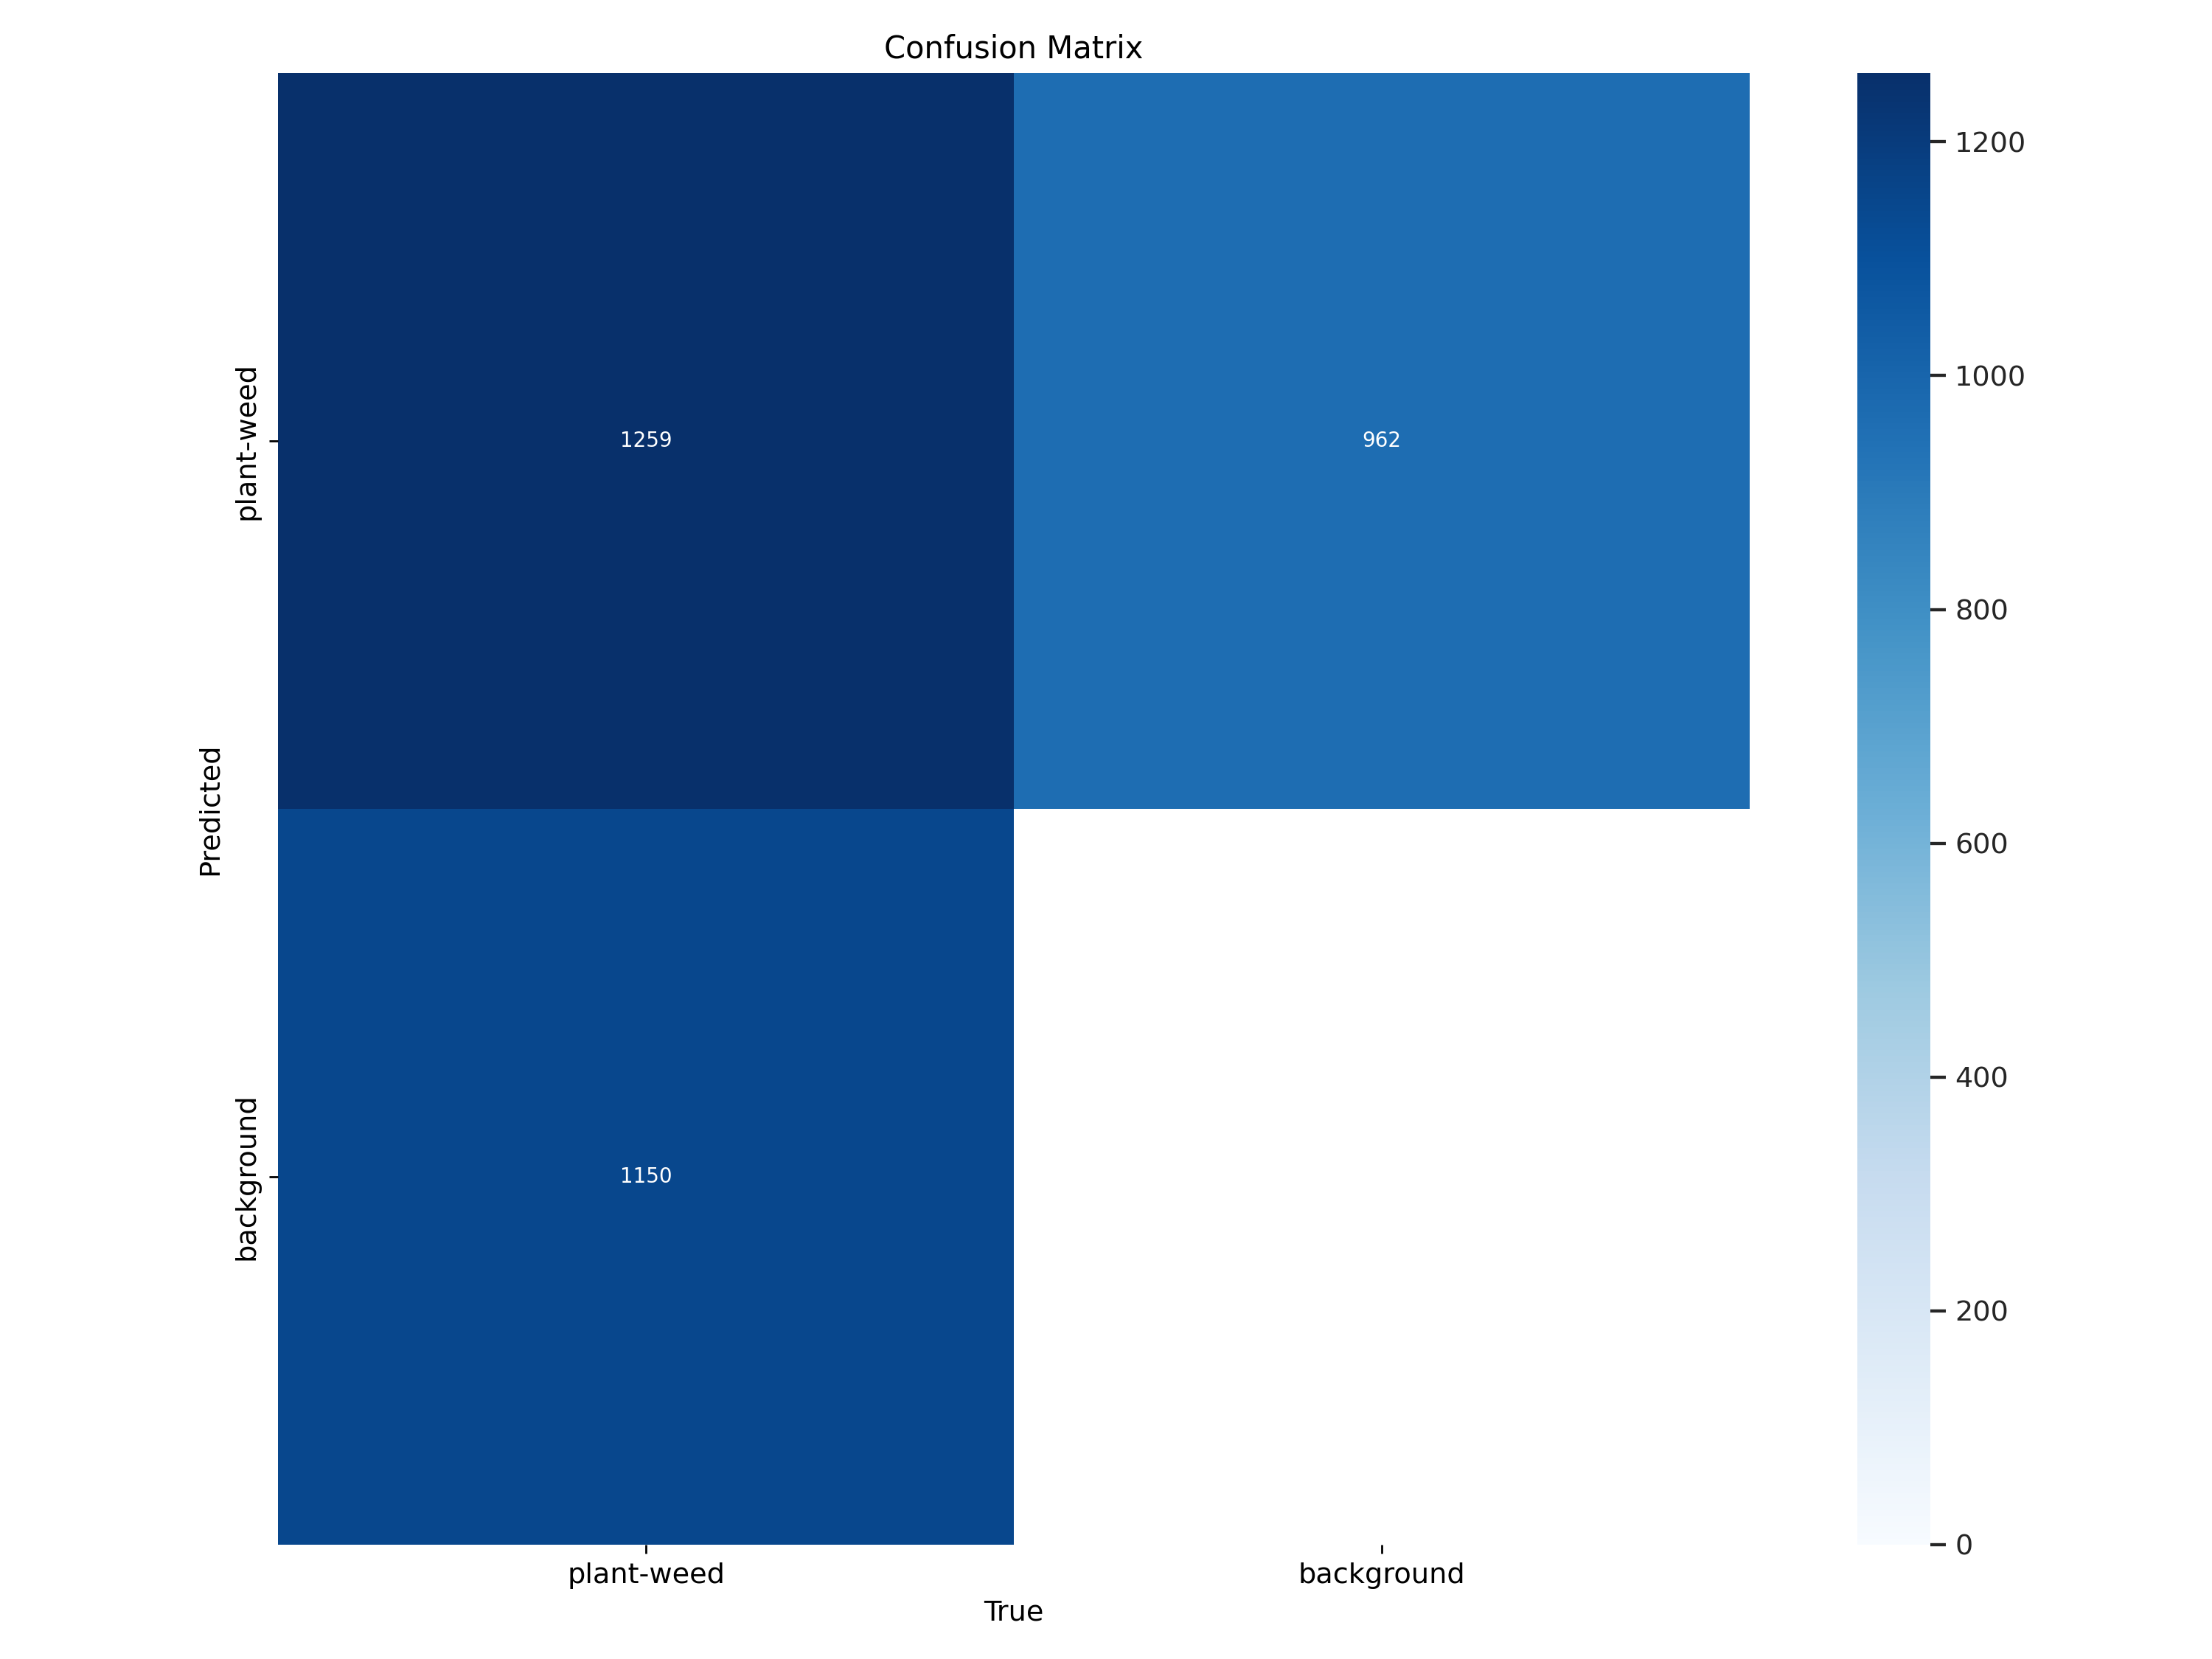

In [19]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

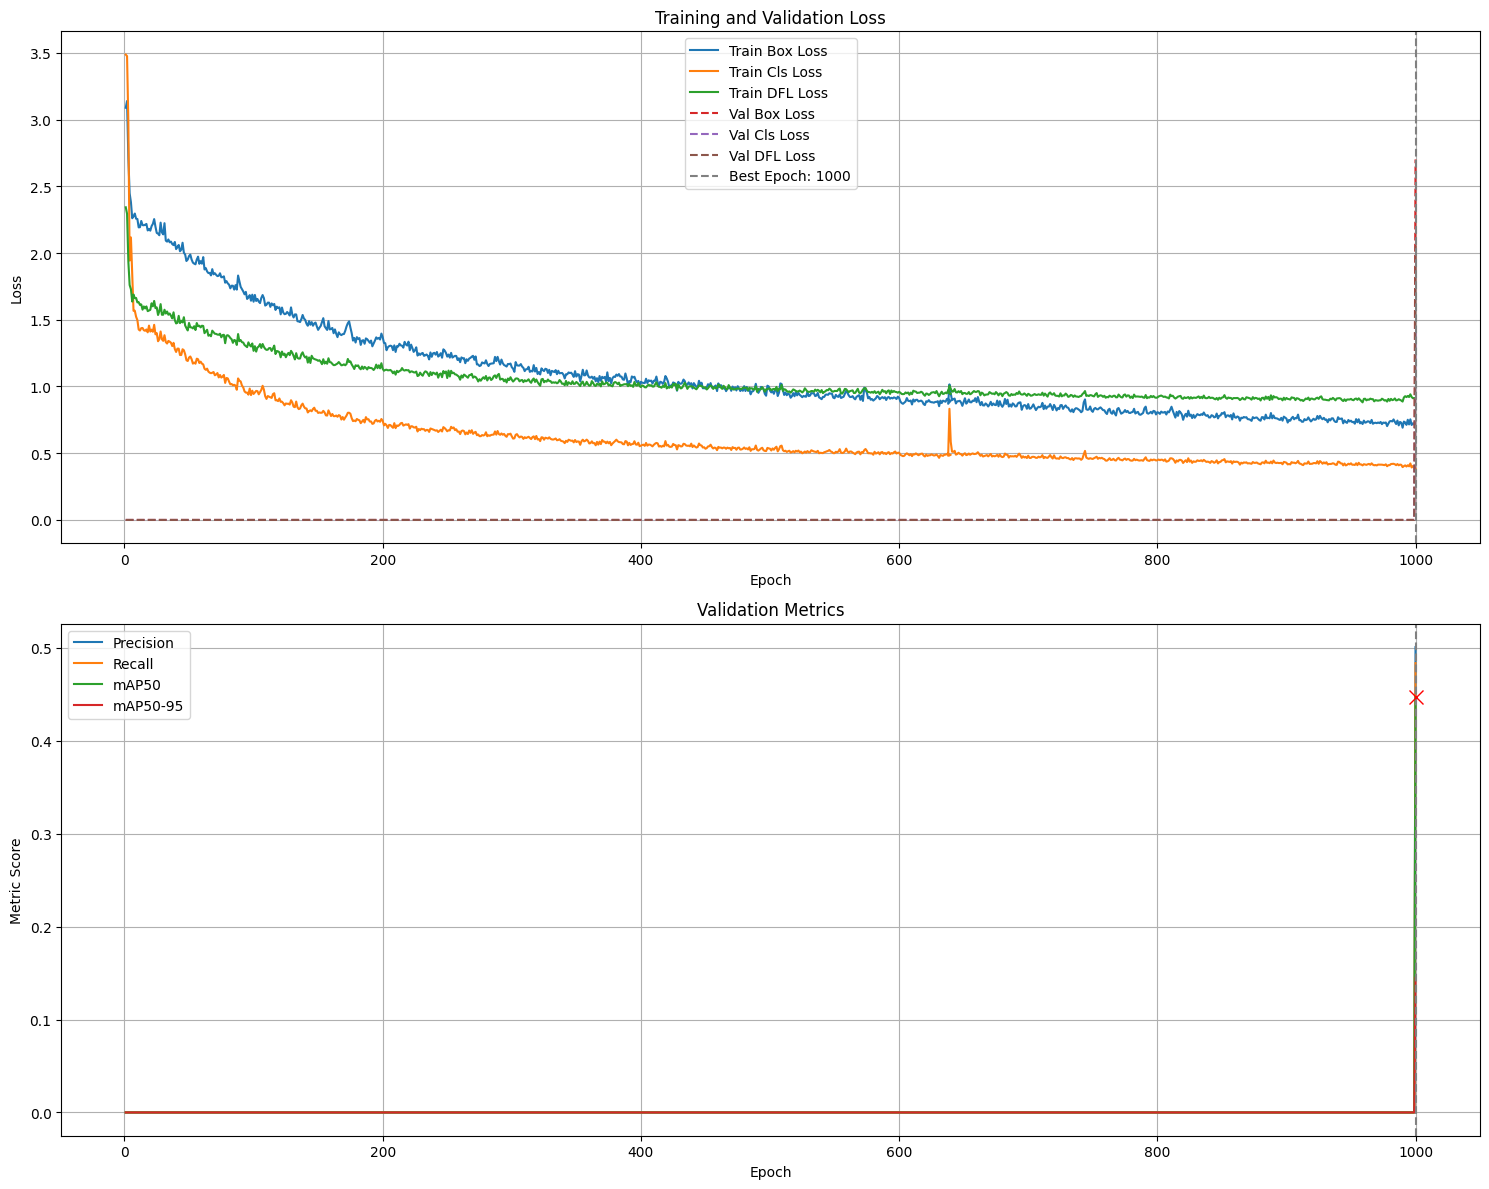

In [20]:
graph_training_metrics(df1, epoch, graph="full")

In [21]:
graph_LrLoss_3D(df1)

Validation set


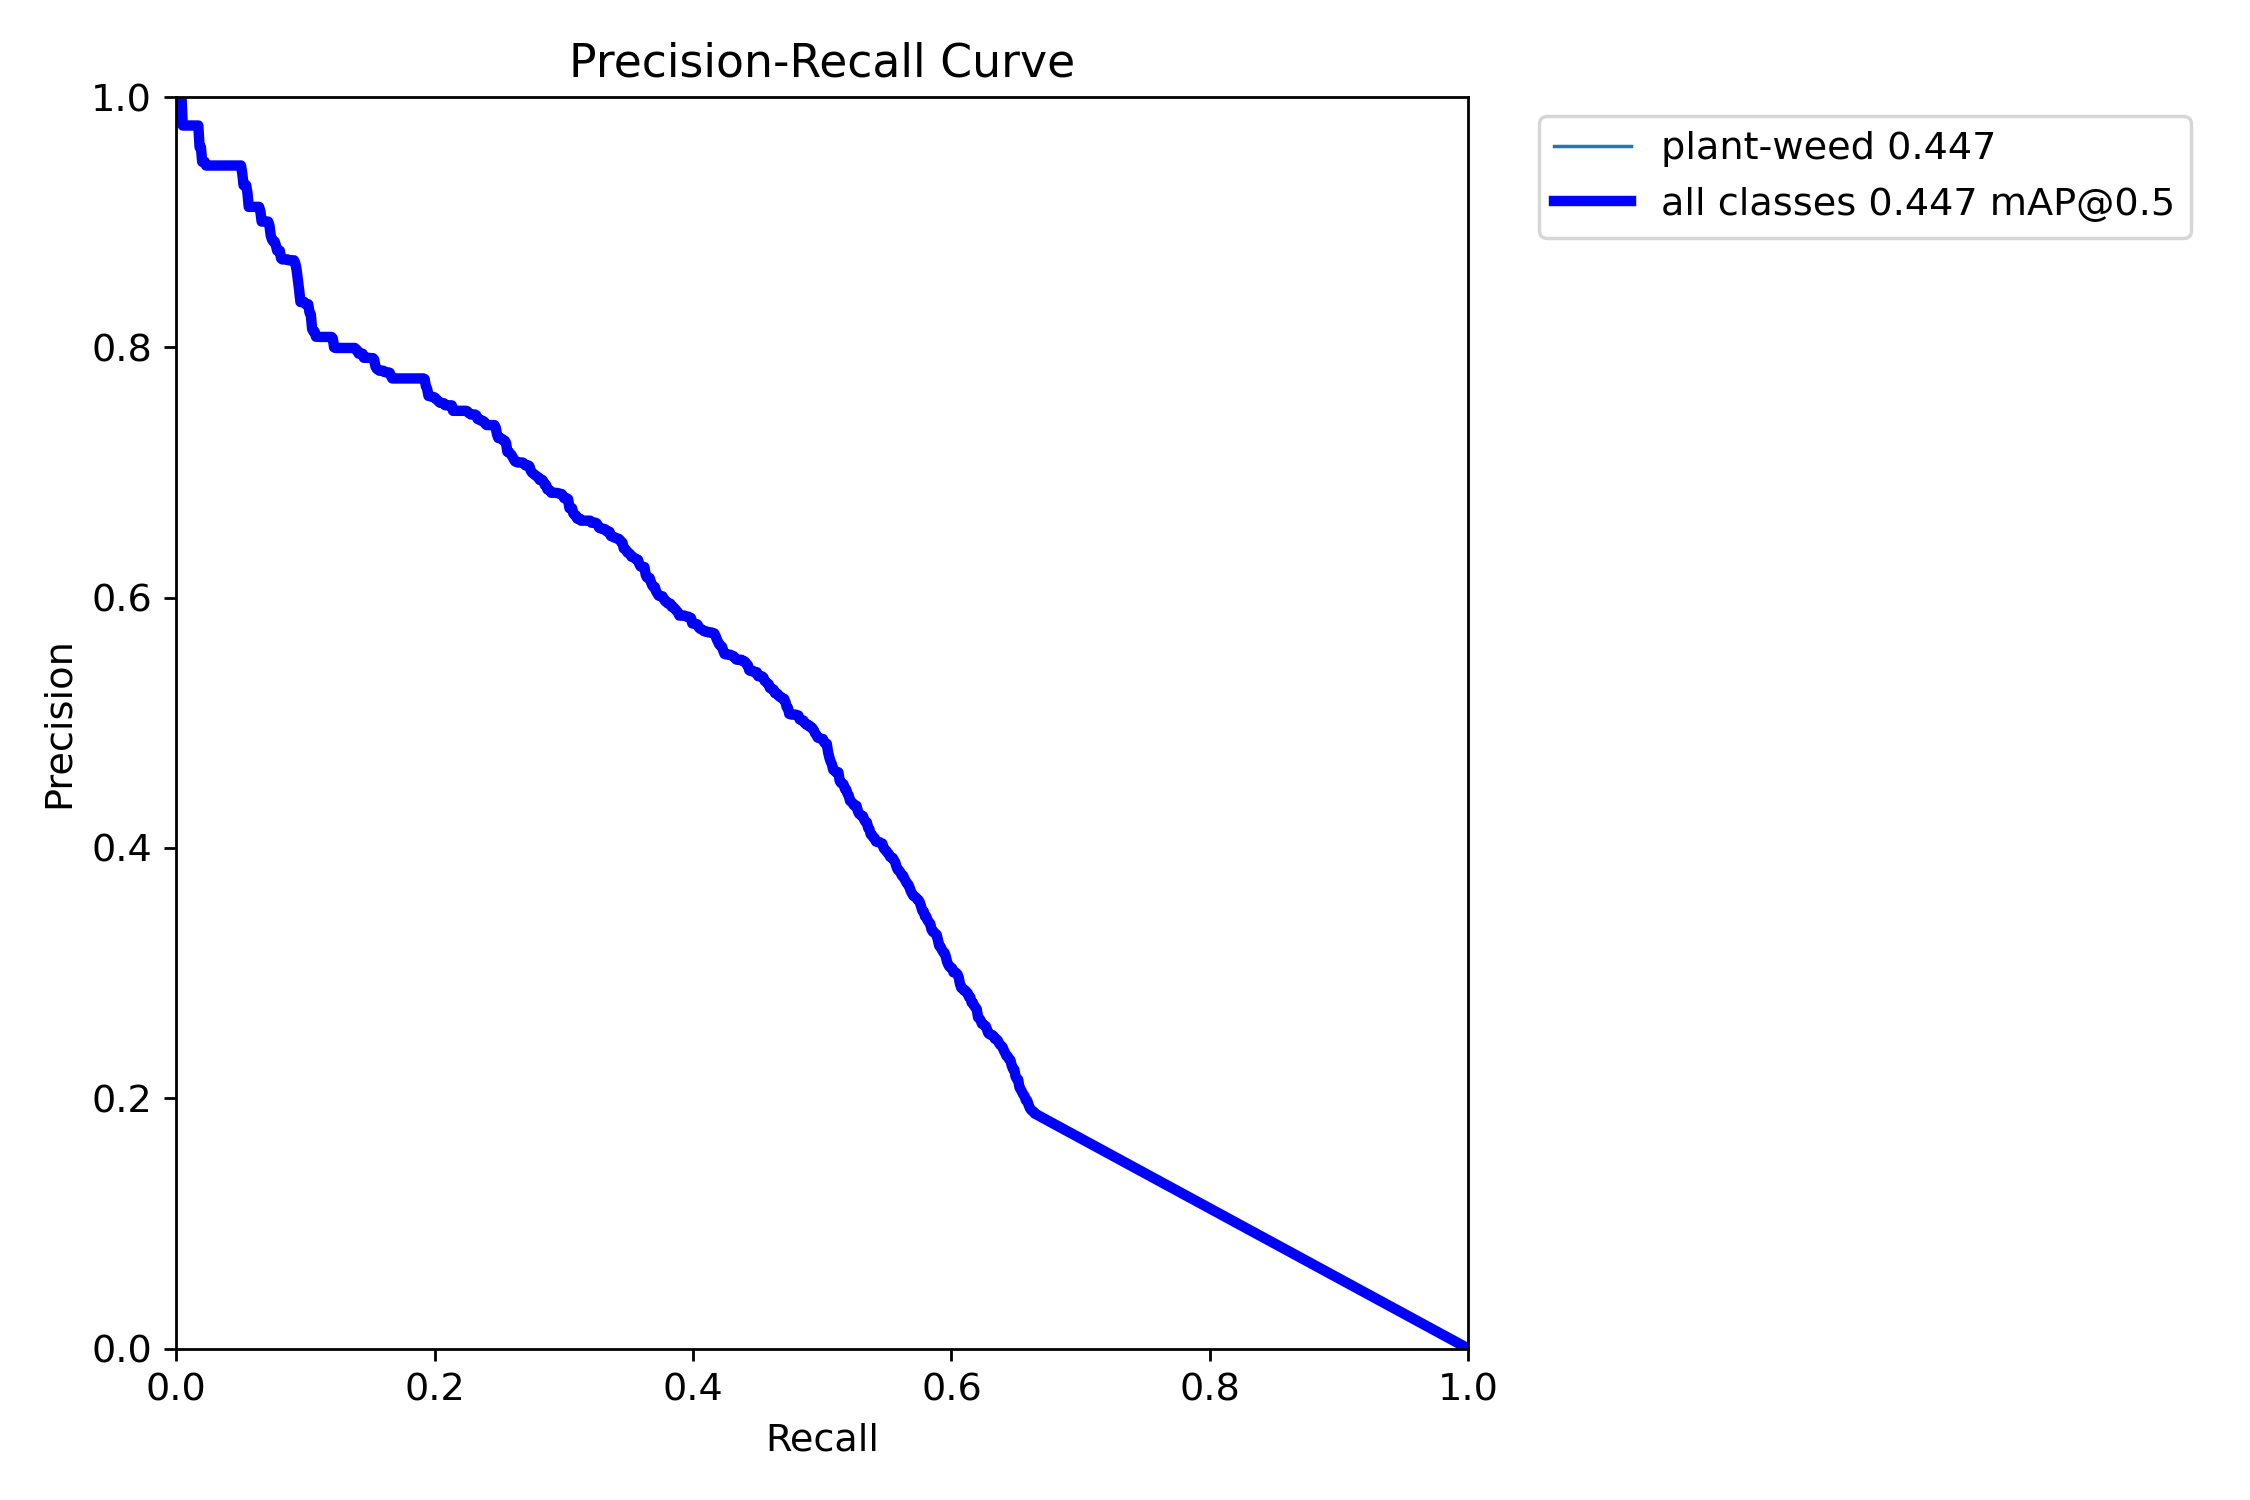

In [22]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

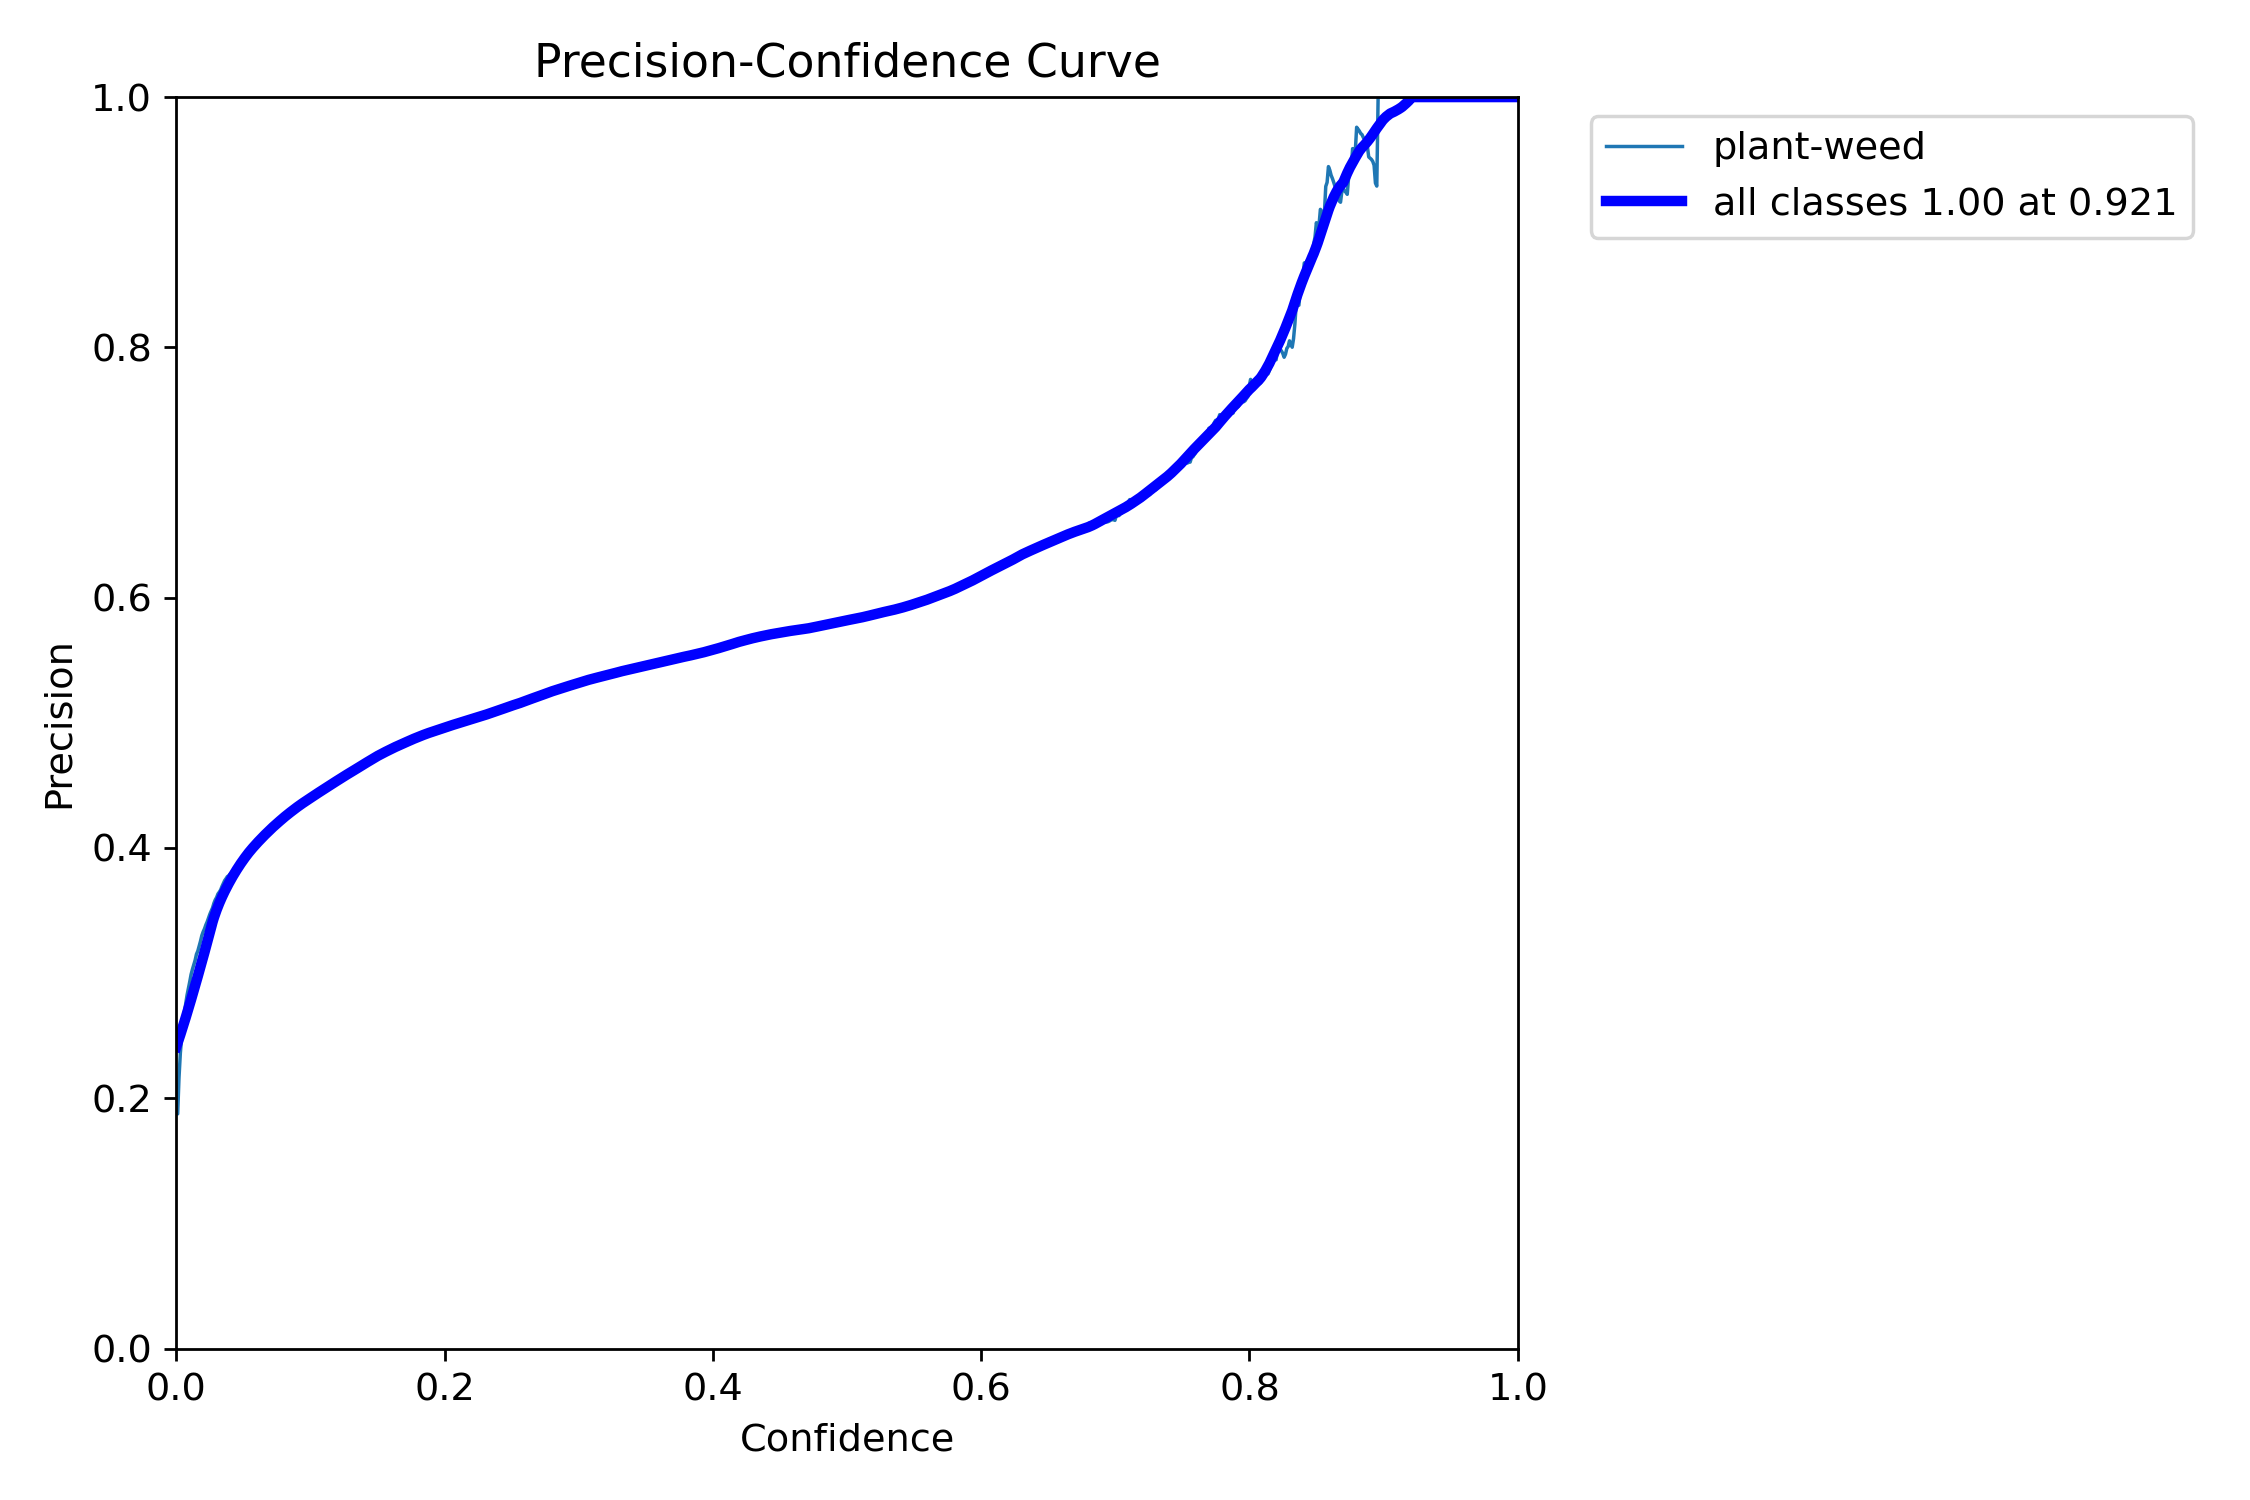

In [23]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

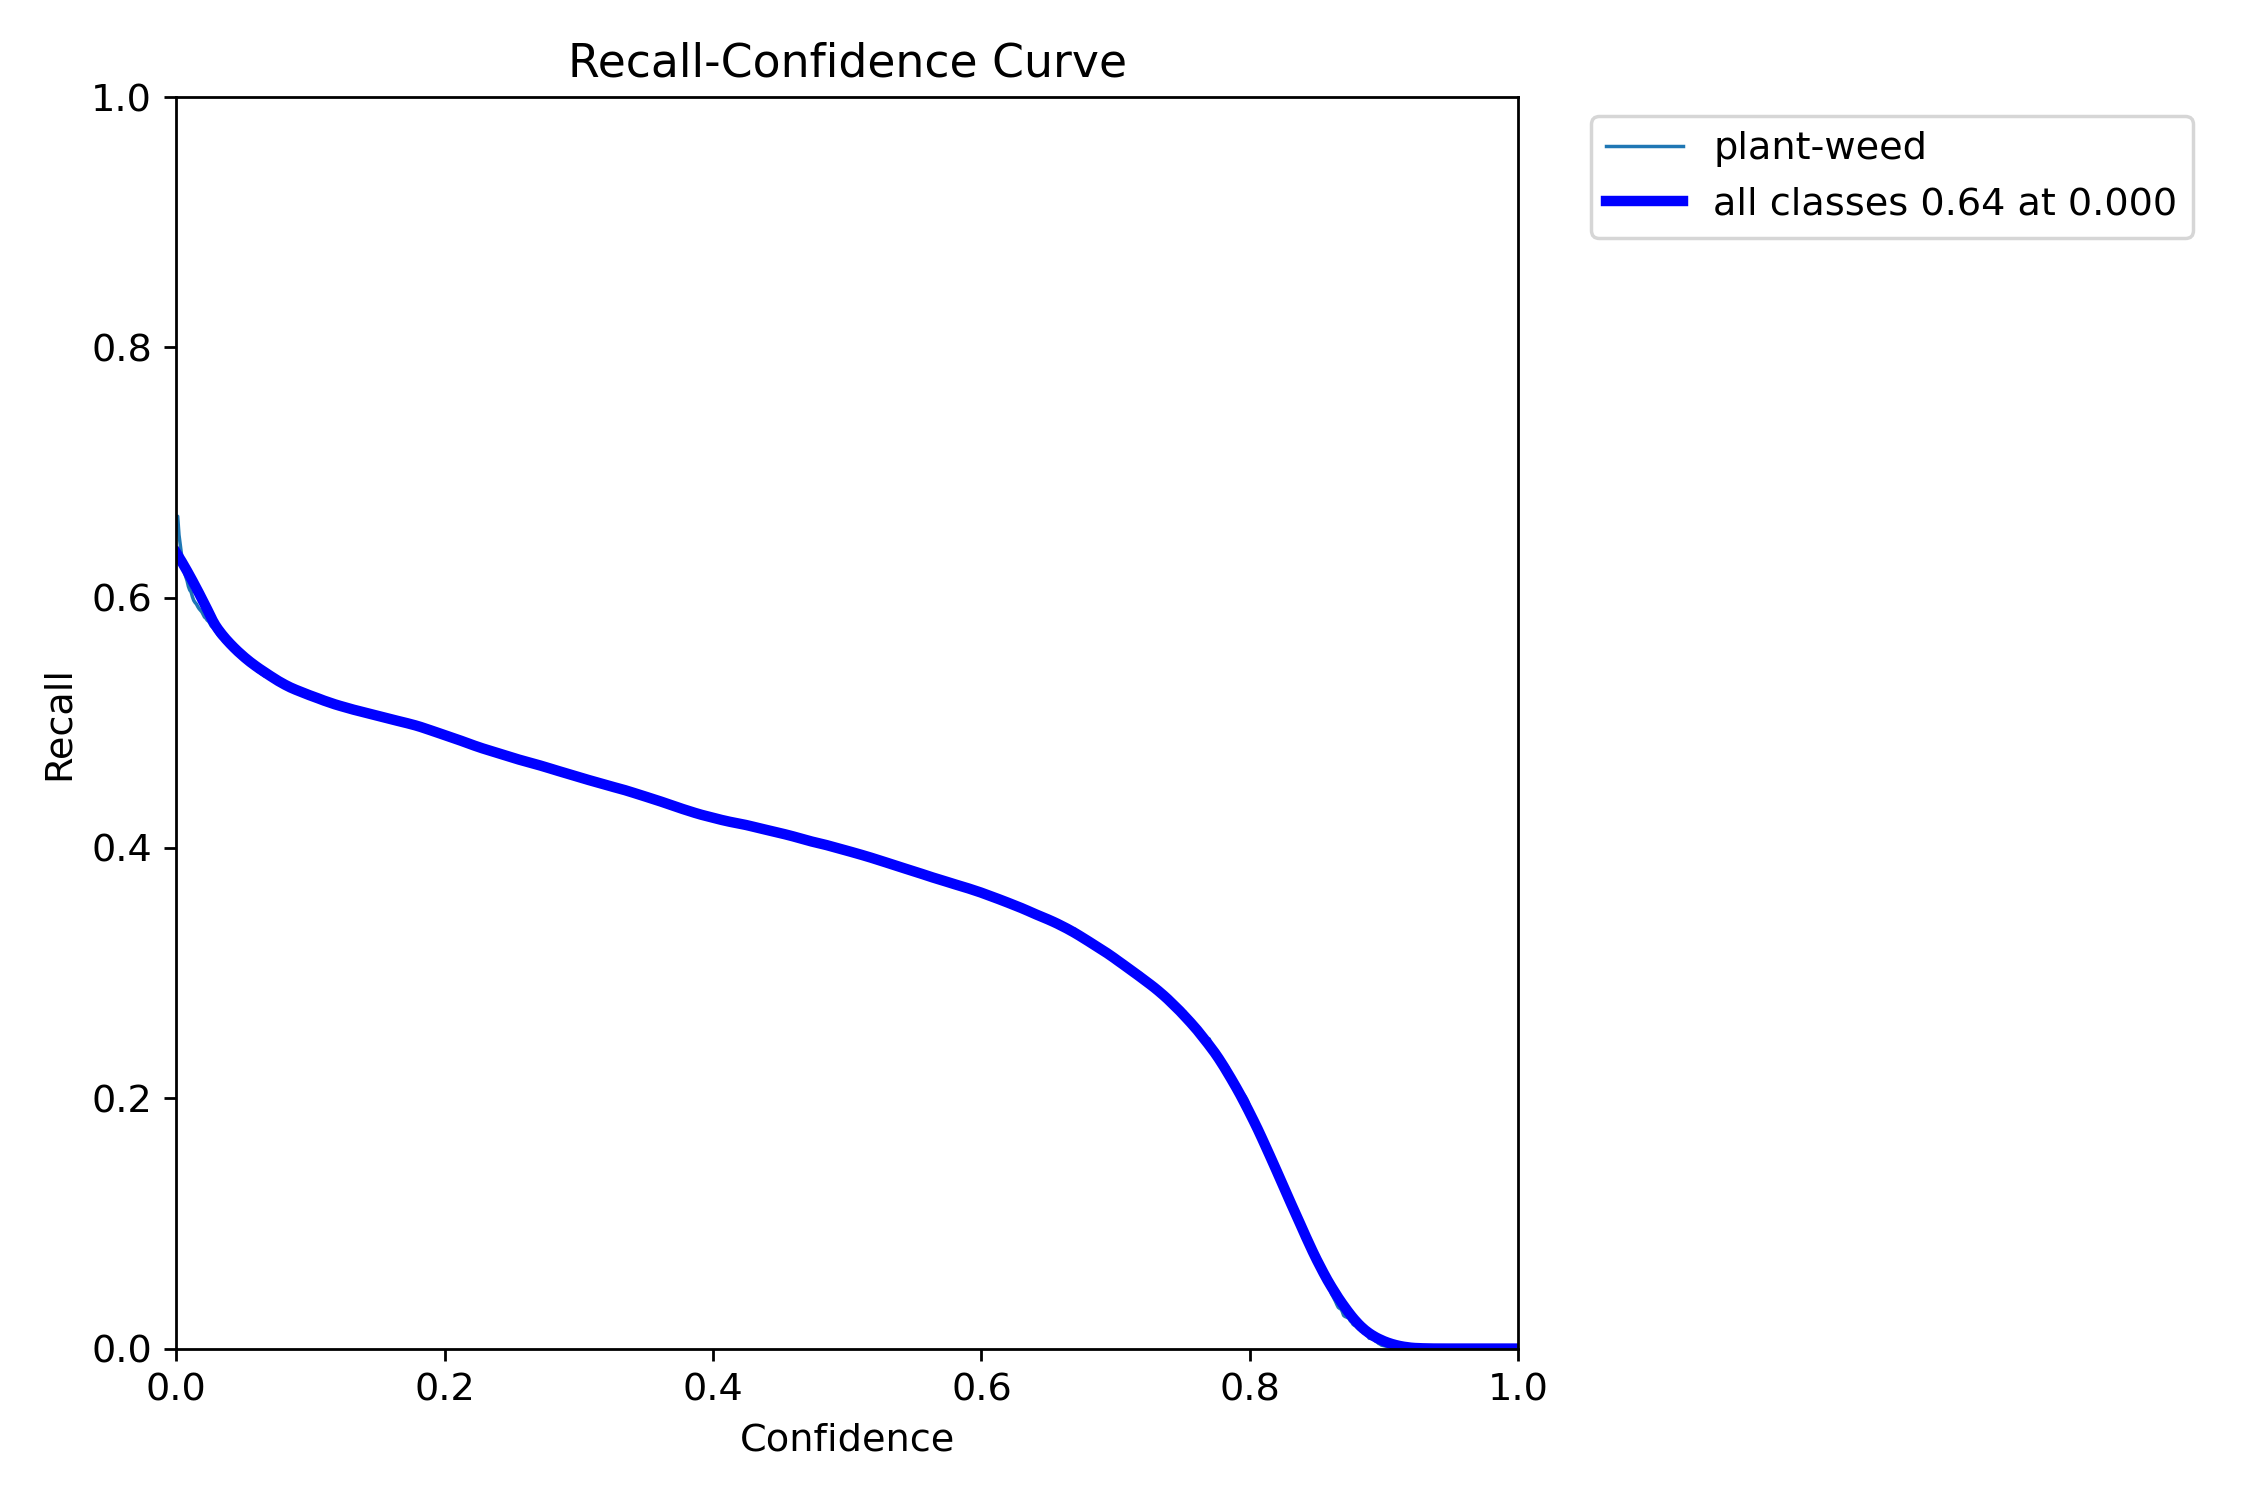

In [24]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

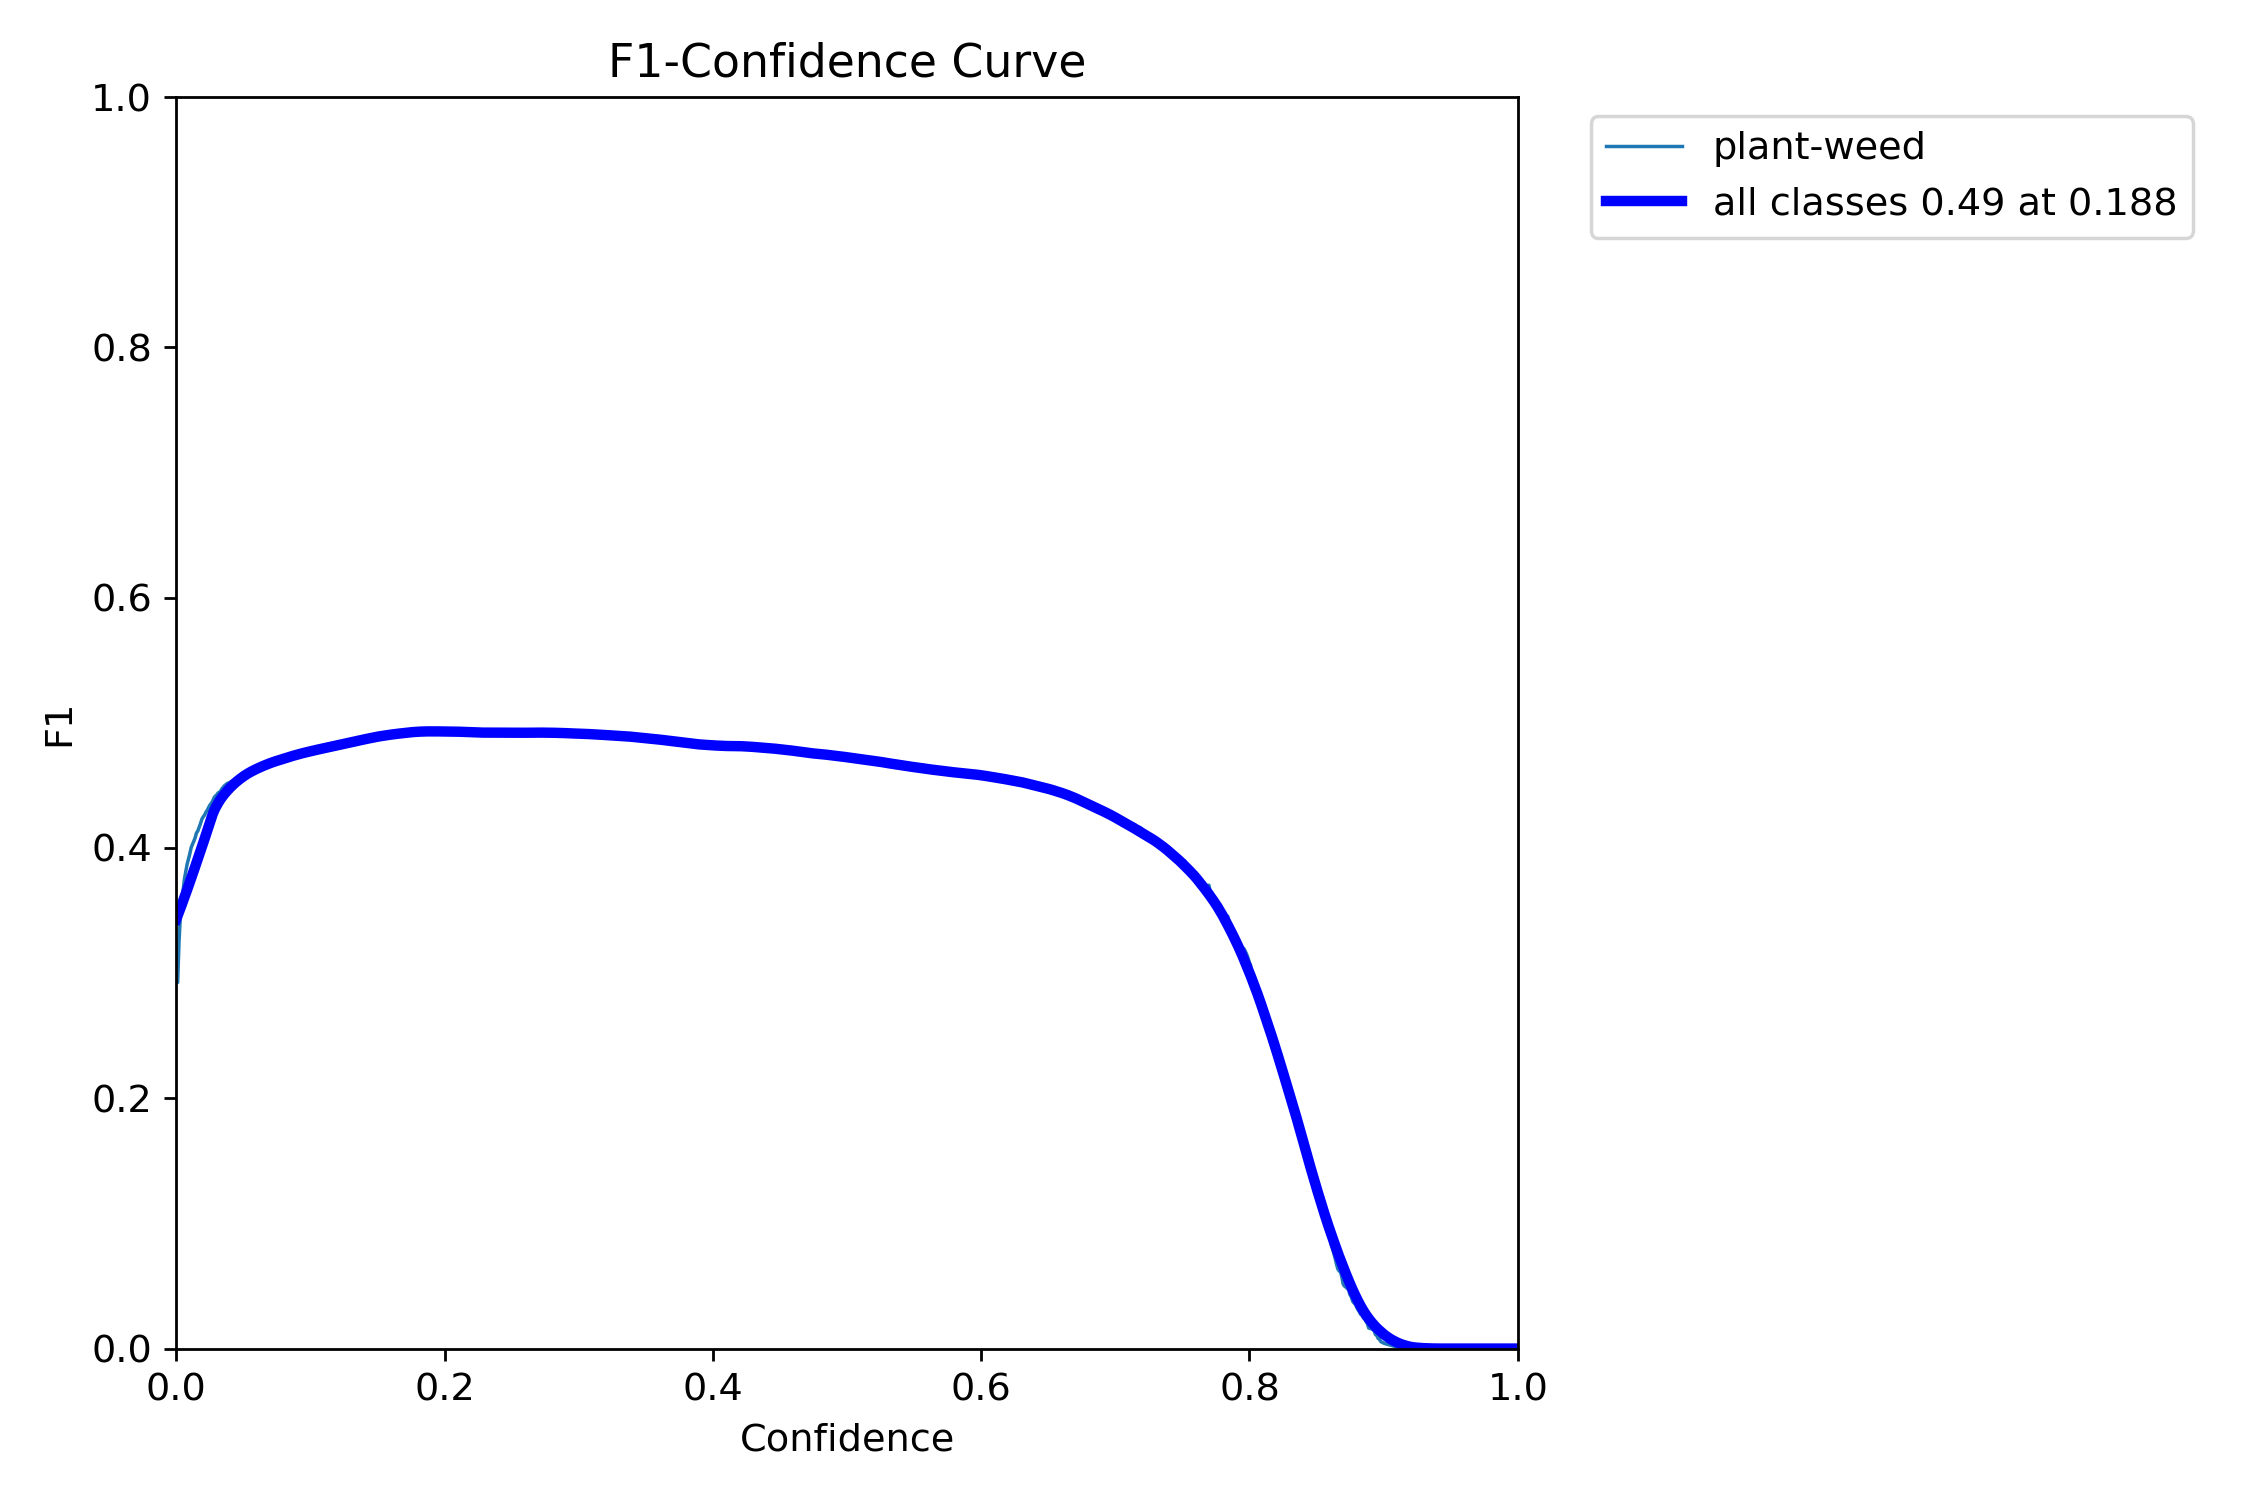

In [25]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

## Experiment 24
### *Extra Large | ~1000 epochs*

In [26]:
folder = "train2 XL/"

In [27]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df2 = pd.read_csv(file_path)
df = df2.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
594,595,13551.4,0.62477,0.35688,0.88884,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000043,0.000043,0.000043
595,596,13573.7,0.63917,0.35985,0.88959,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000040,0.000040,0.000040
596,597,13598.3,0.66741,0.37453,0.89861,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000036,0.000036,0.000036
597,598,13613.2,0.67830,0.38065,0.91006,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000033,0.000033,0.000033
598,599,13681.6,0.62002,0.35108,0.88294,0.57655,0.45621,0.46619,0.15884,2.65442,1.45569,2.08224,0.000023,0.000023,0.000023


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [28]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 228.027 min


#### Best epoch

In [29]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
598,599,13681.6,0.62002,0.35108,0.88294,0.57655,0.45621,0.46619,0.15884,2.65442,1.45569,2.08224,0.000023,0.000023,0.000023,228.026667


In [30]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 599 con mAP50 de 0.466


In [31]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [86]:
TP = 1270
FP = 779
FN = 1139
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 3188


In [ ]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.3983688833124216, 0.2443538268506901, 0.35727728983688833)

### Graphs

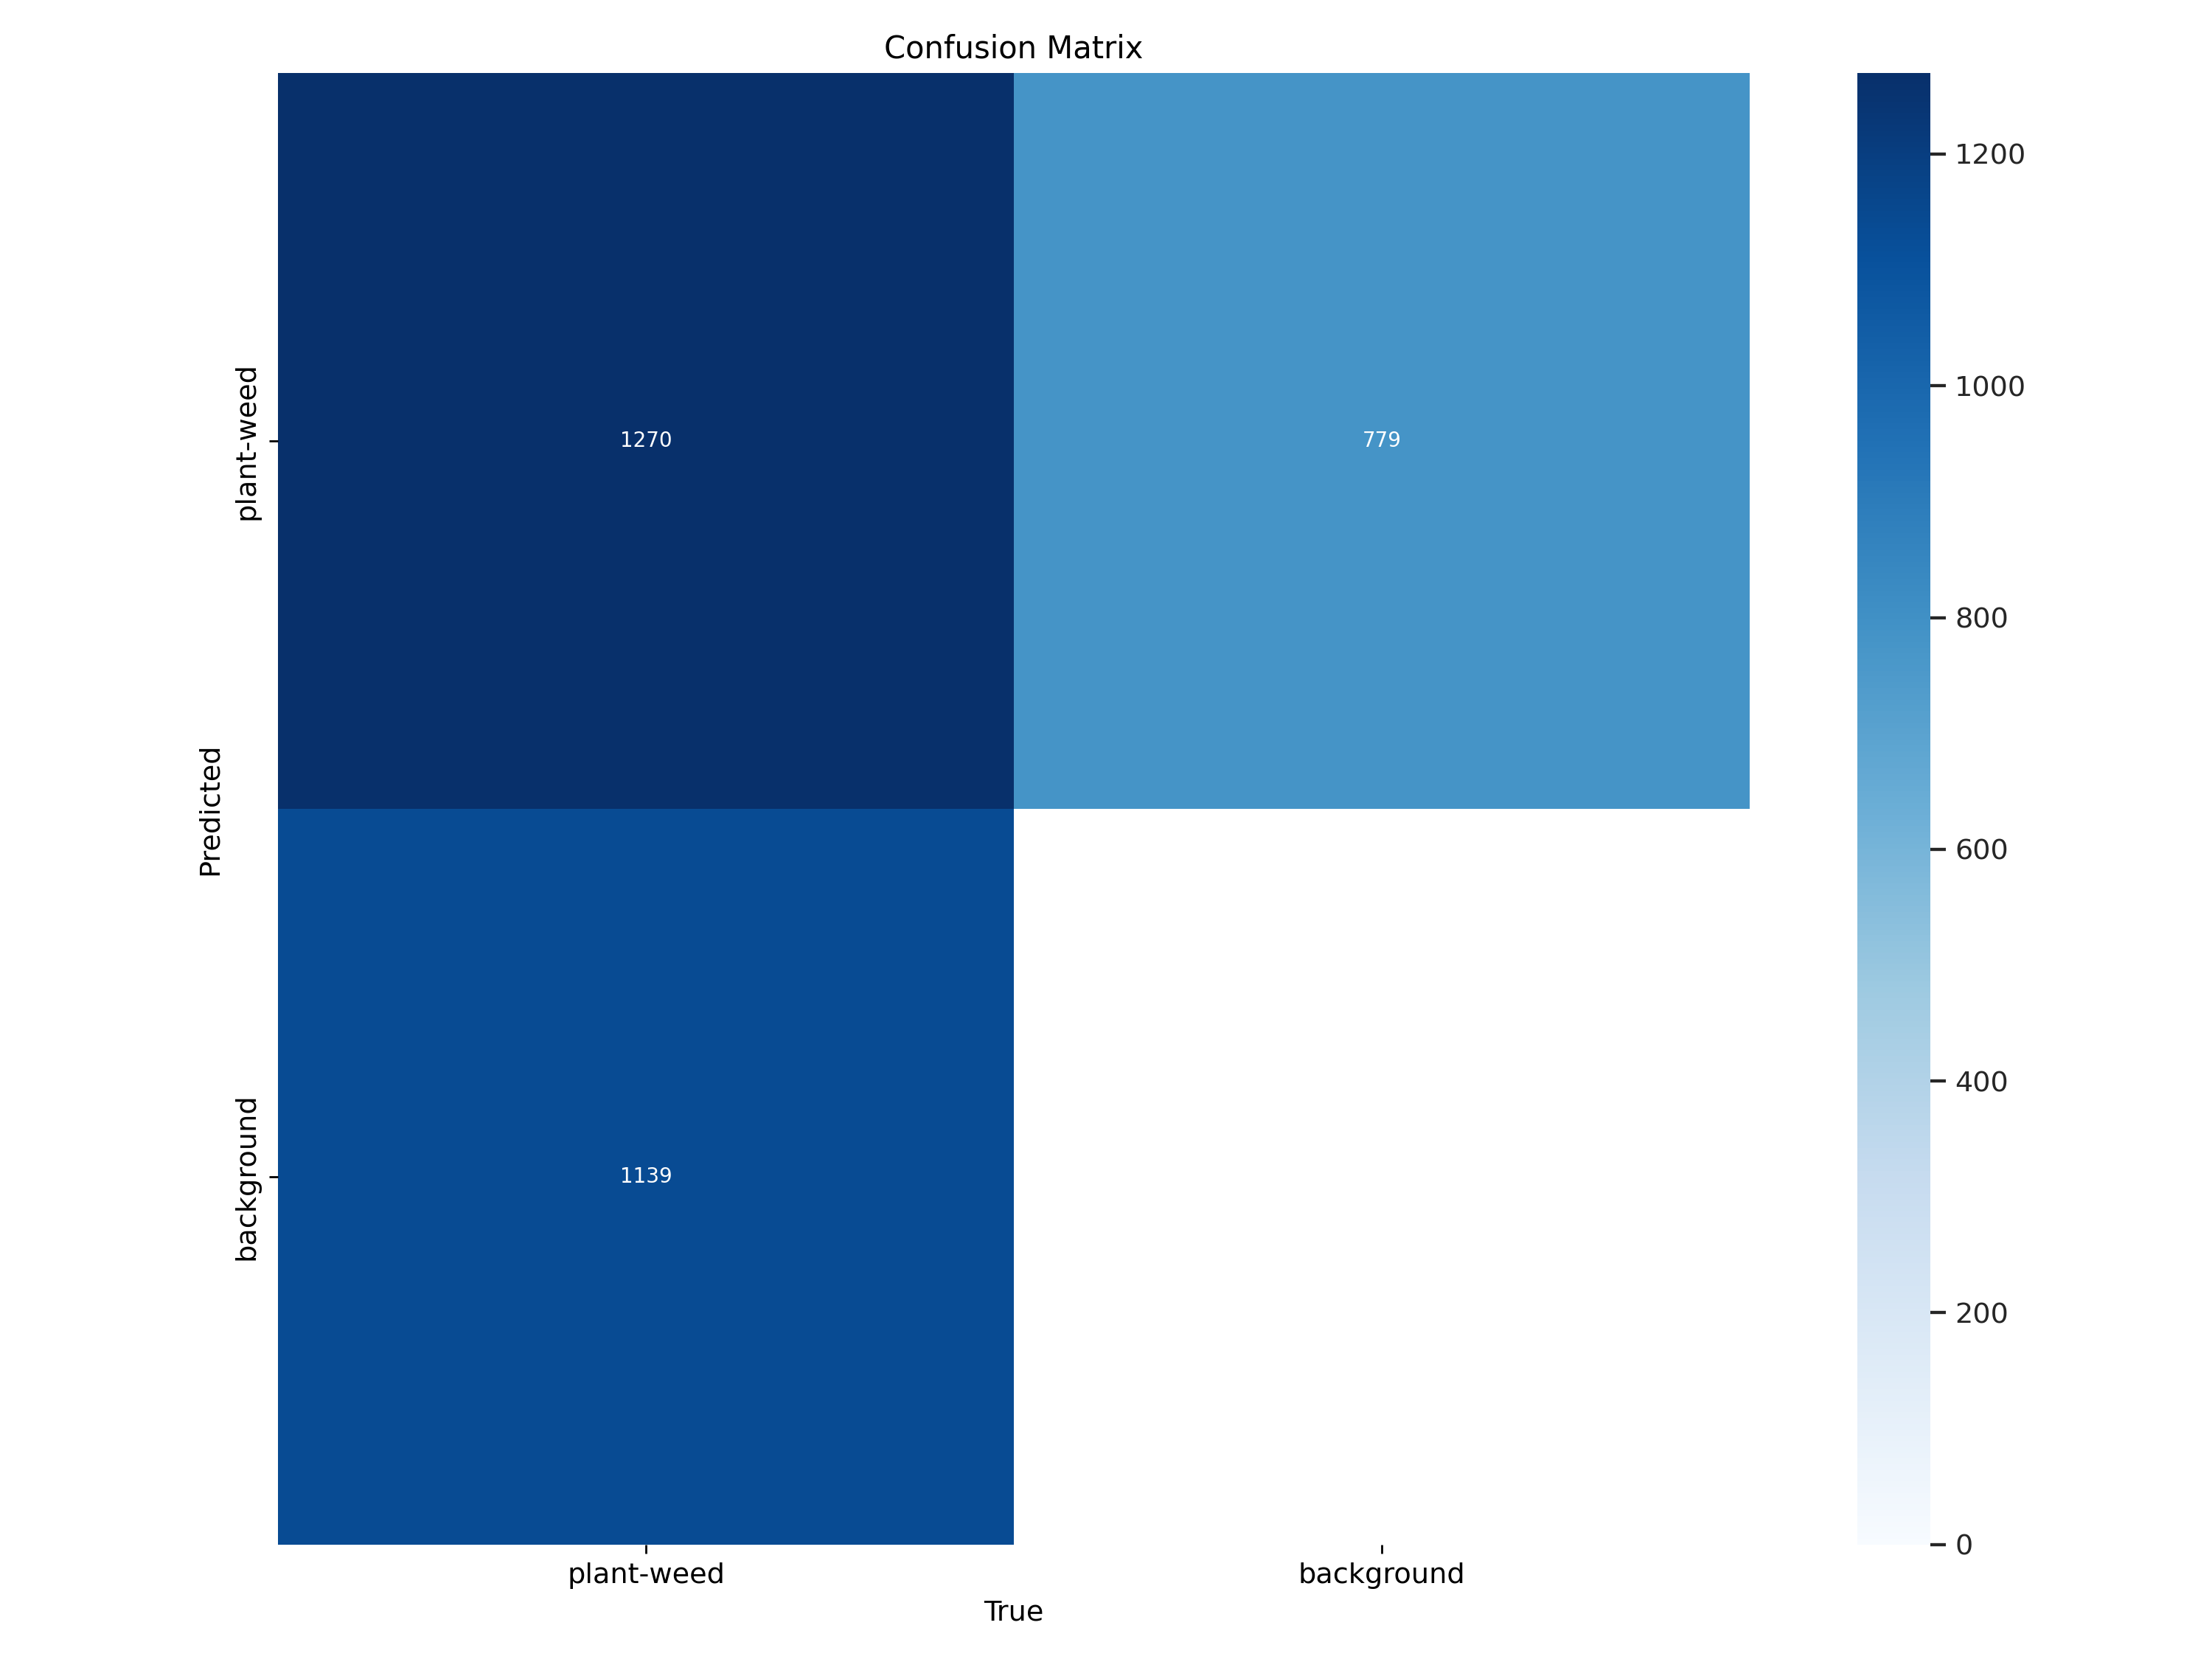

In [34]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

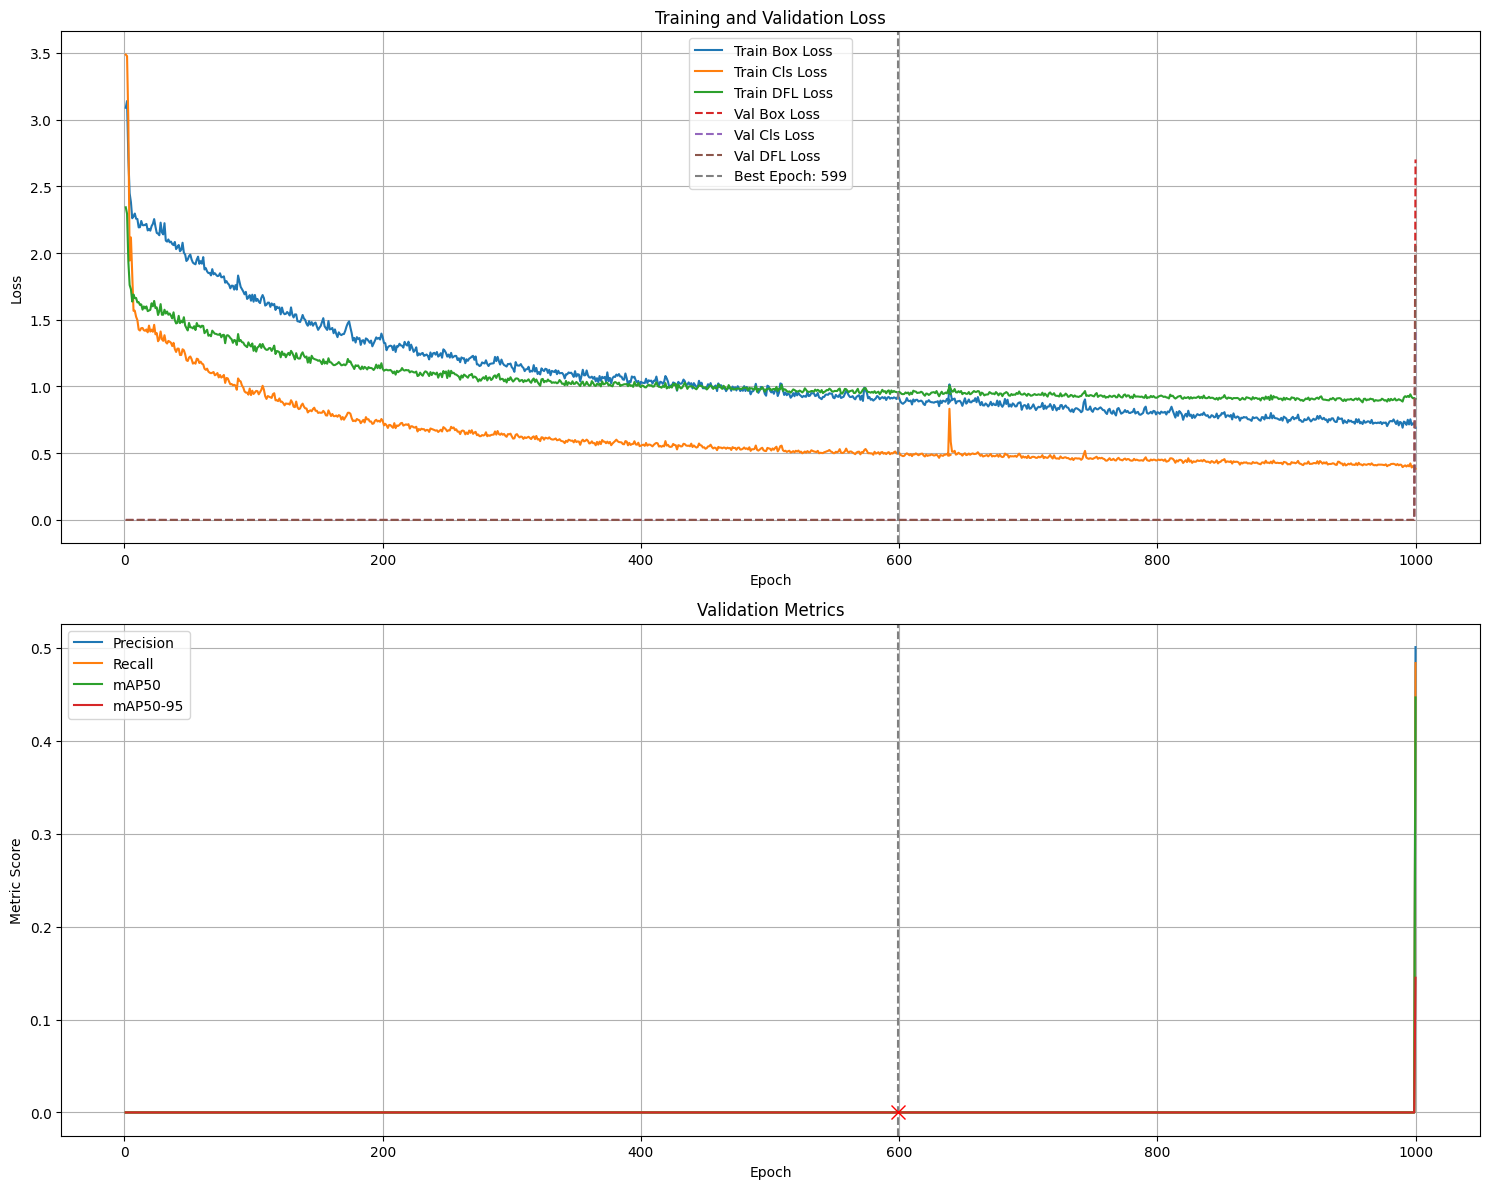

In [35]:
graph_training_metrics(df1, epoch, graph="full")

In [36]:
graph_LrLoss_3D(df1)

Validation set


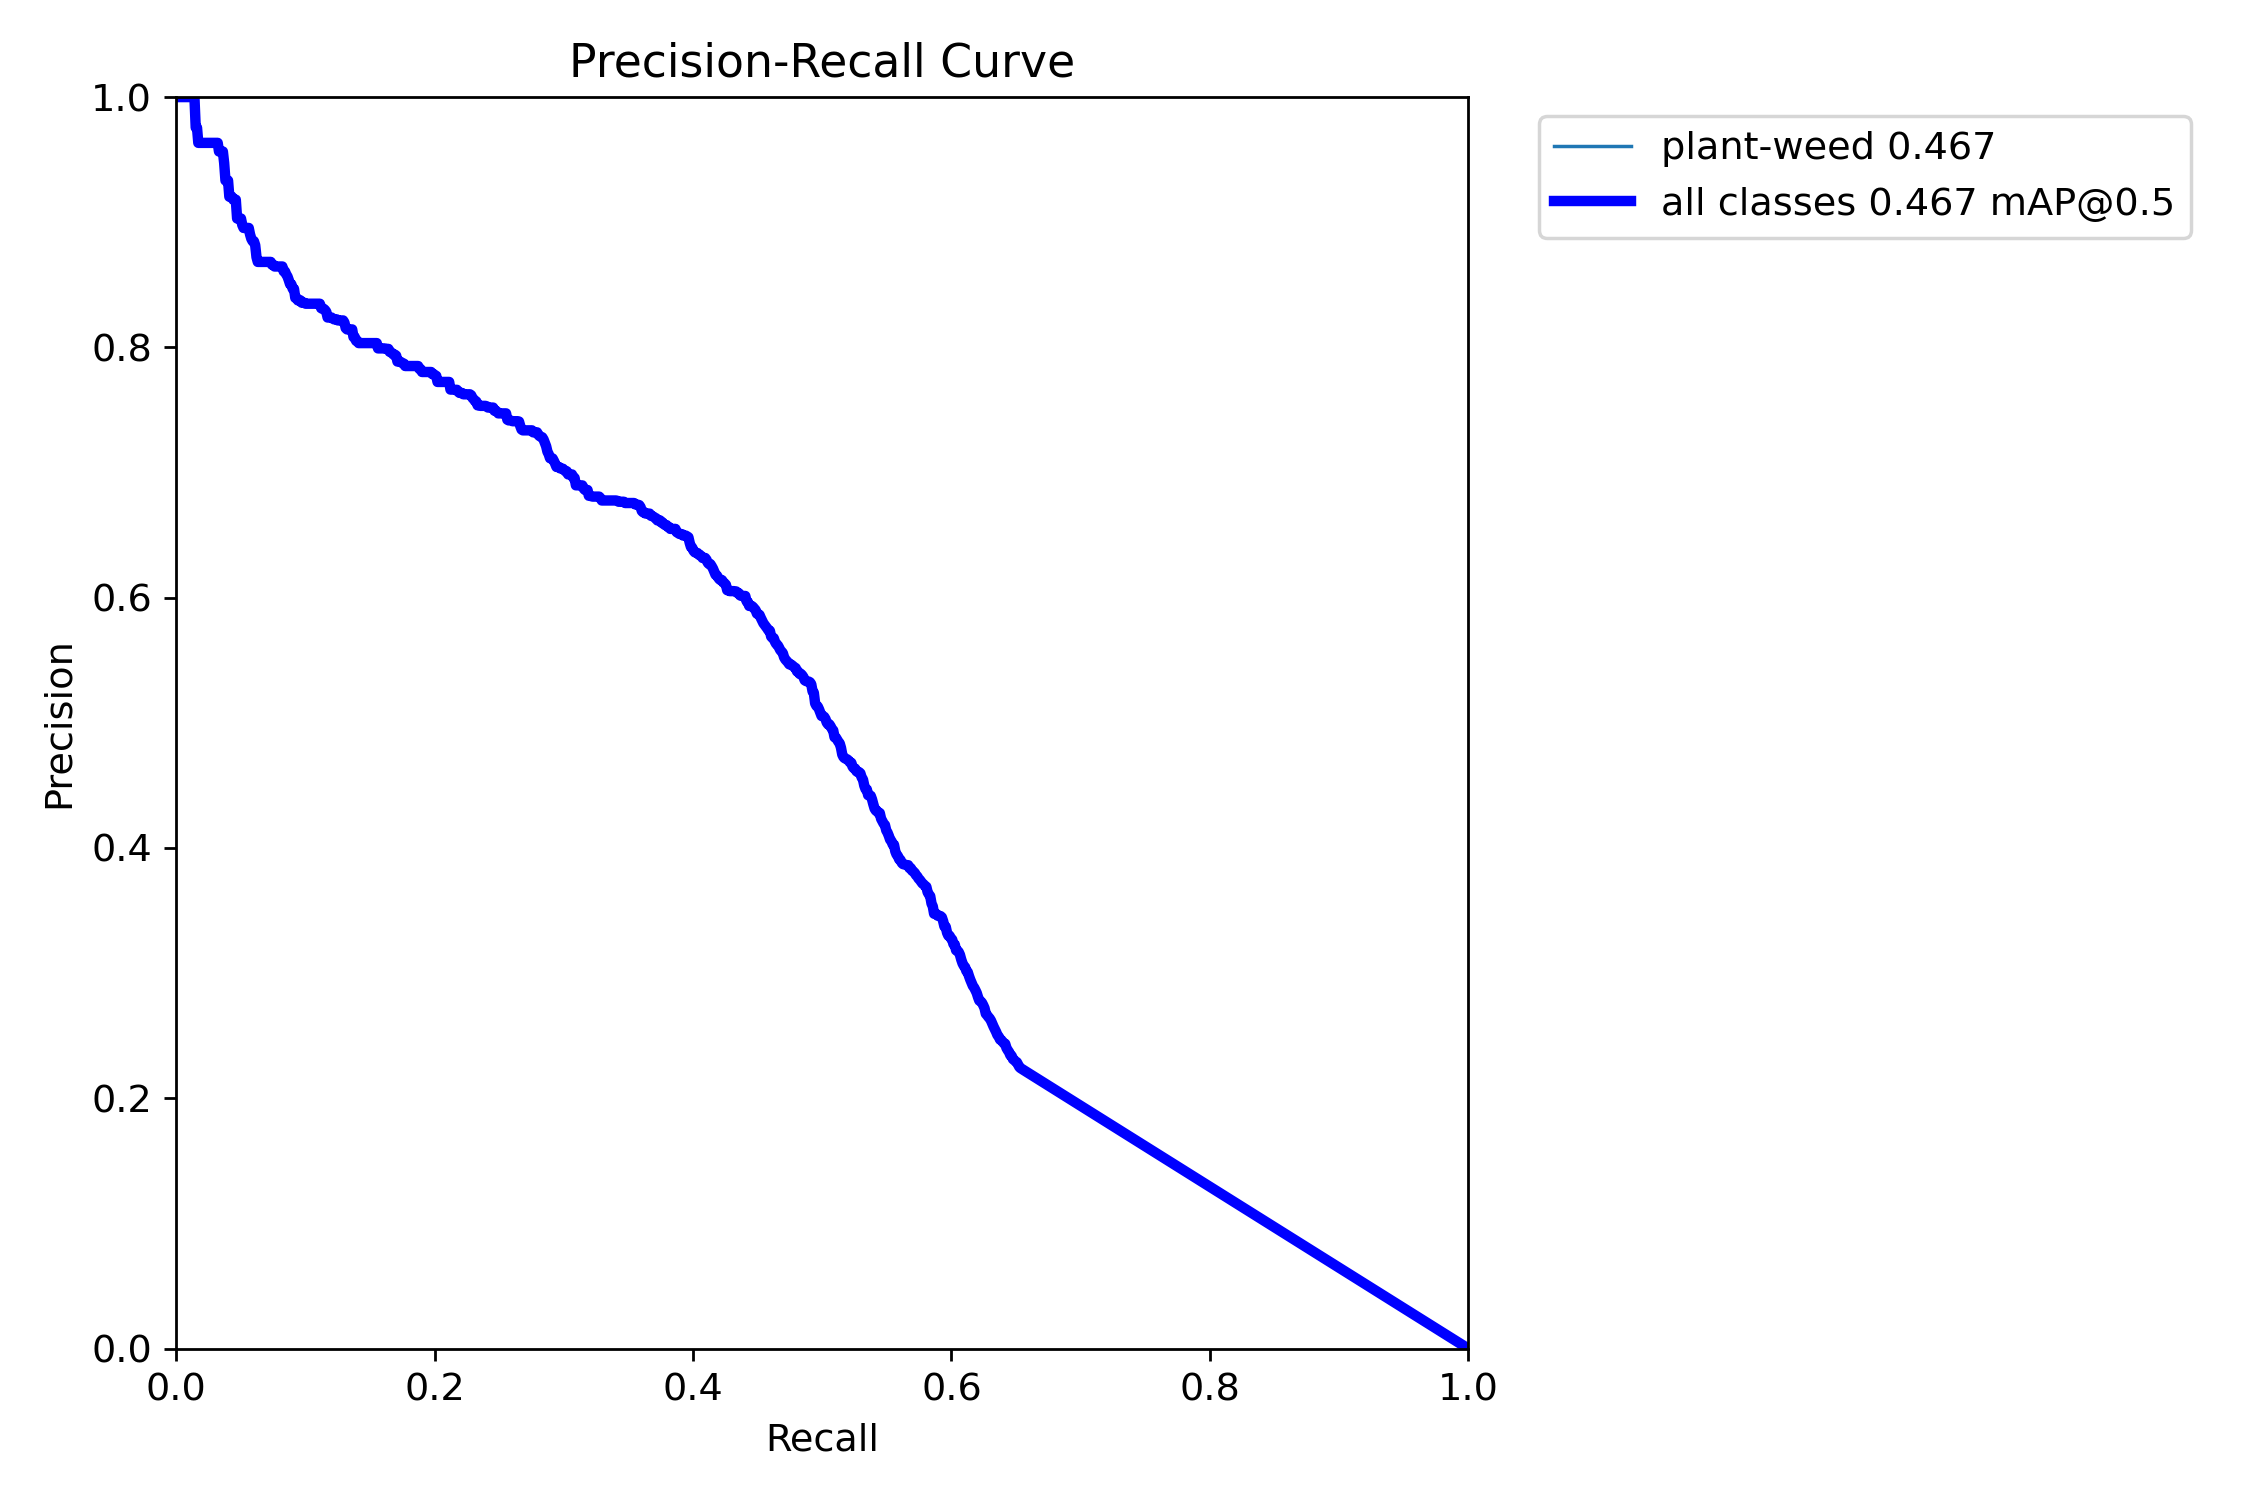

In [37]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

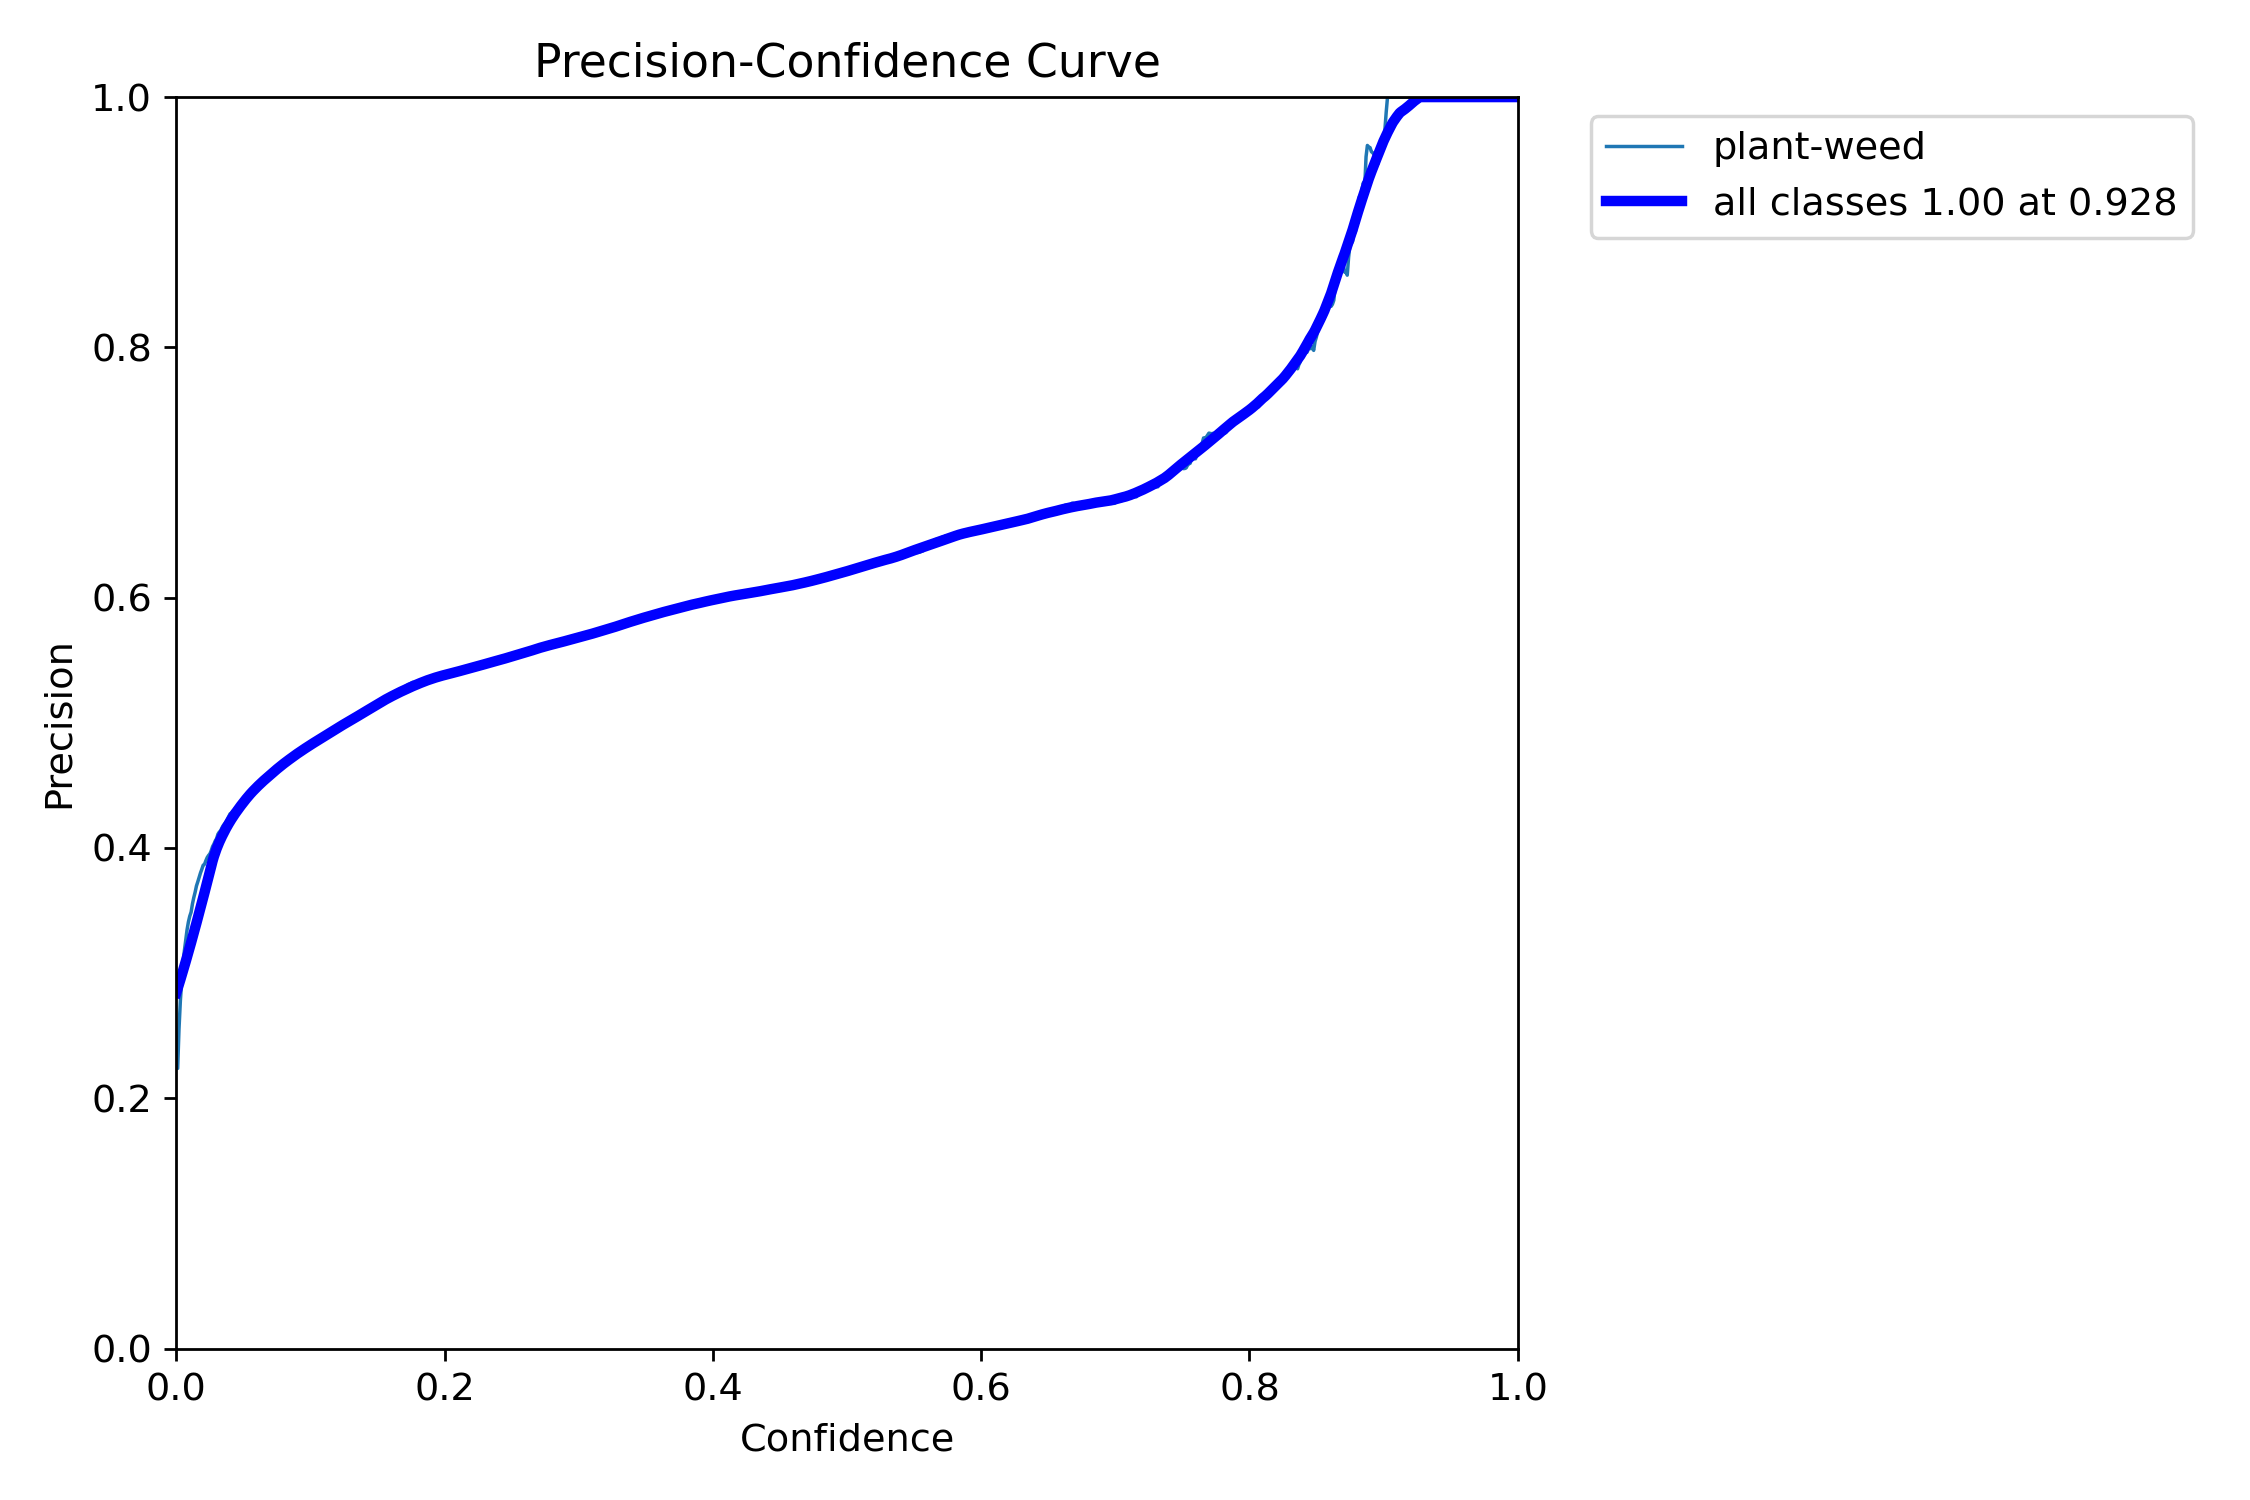

In [38]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

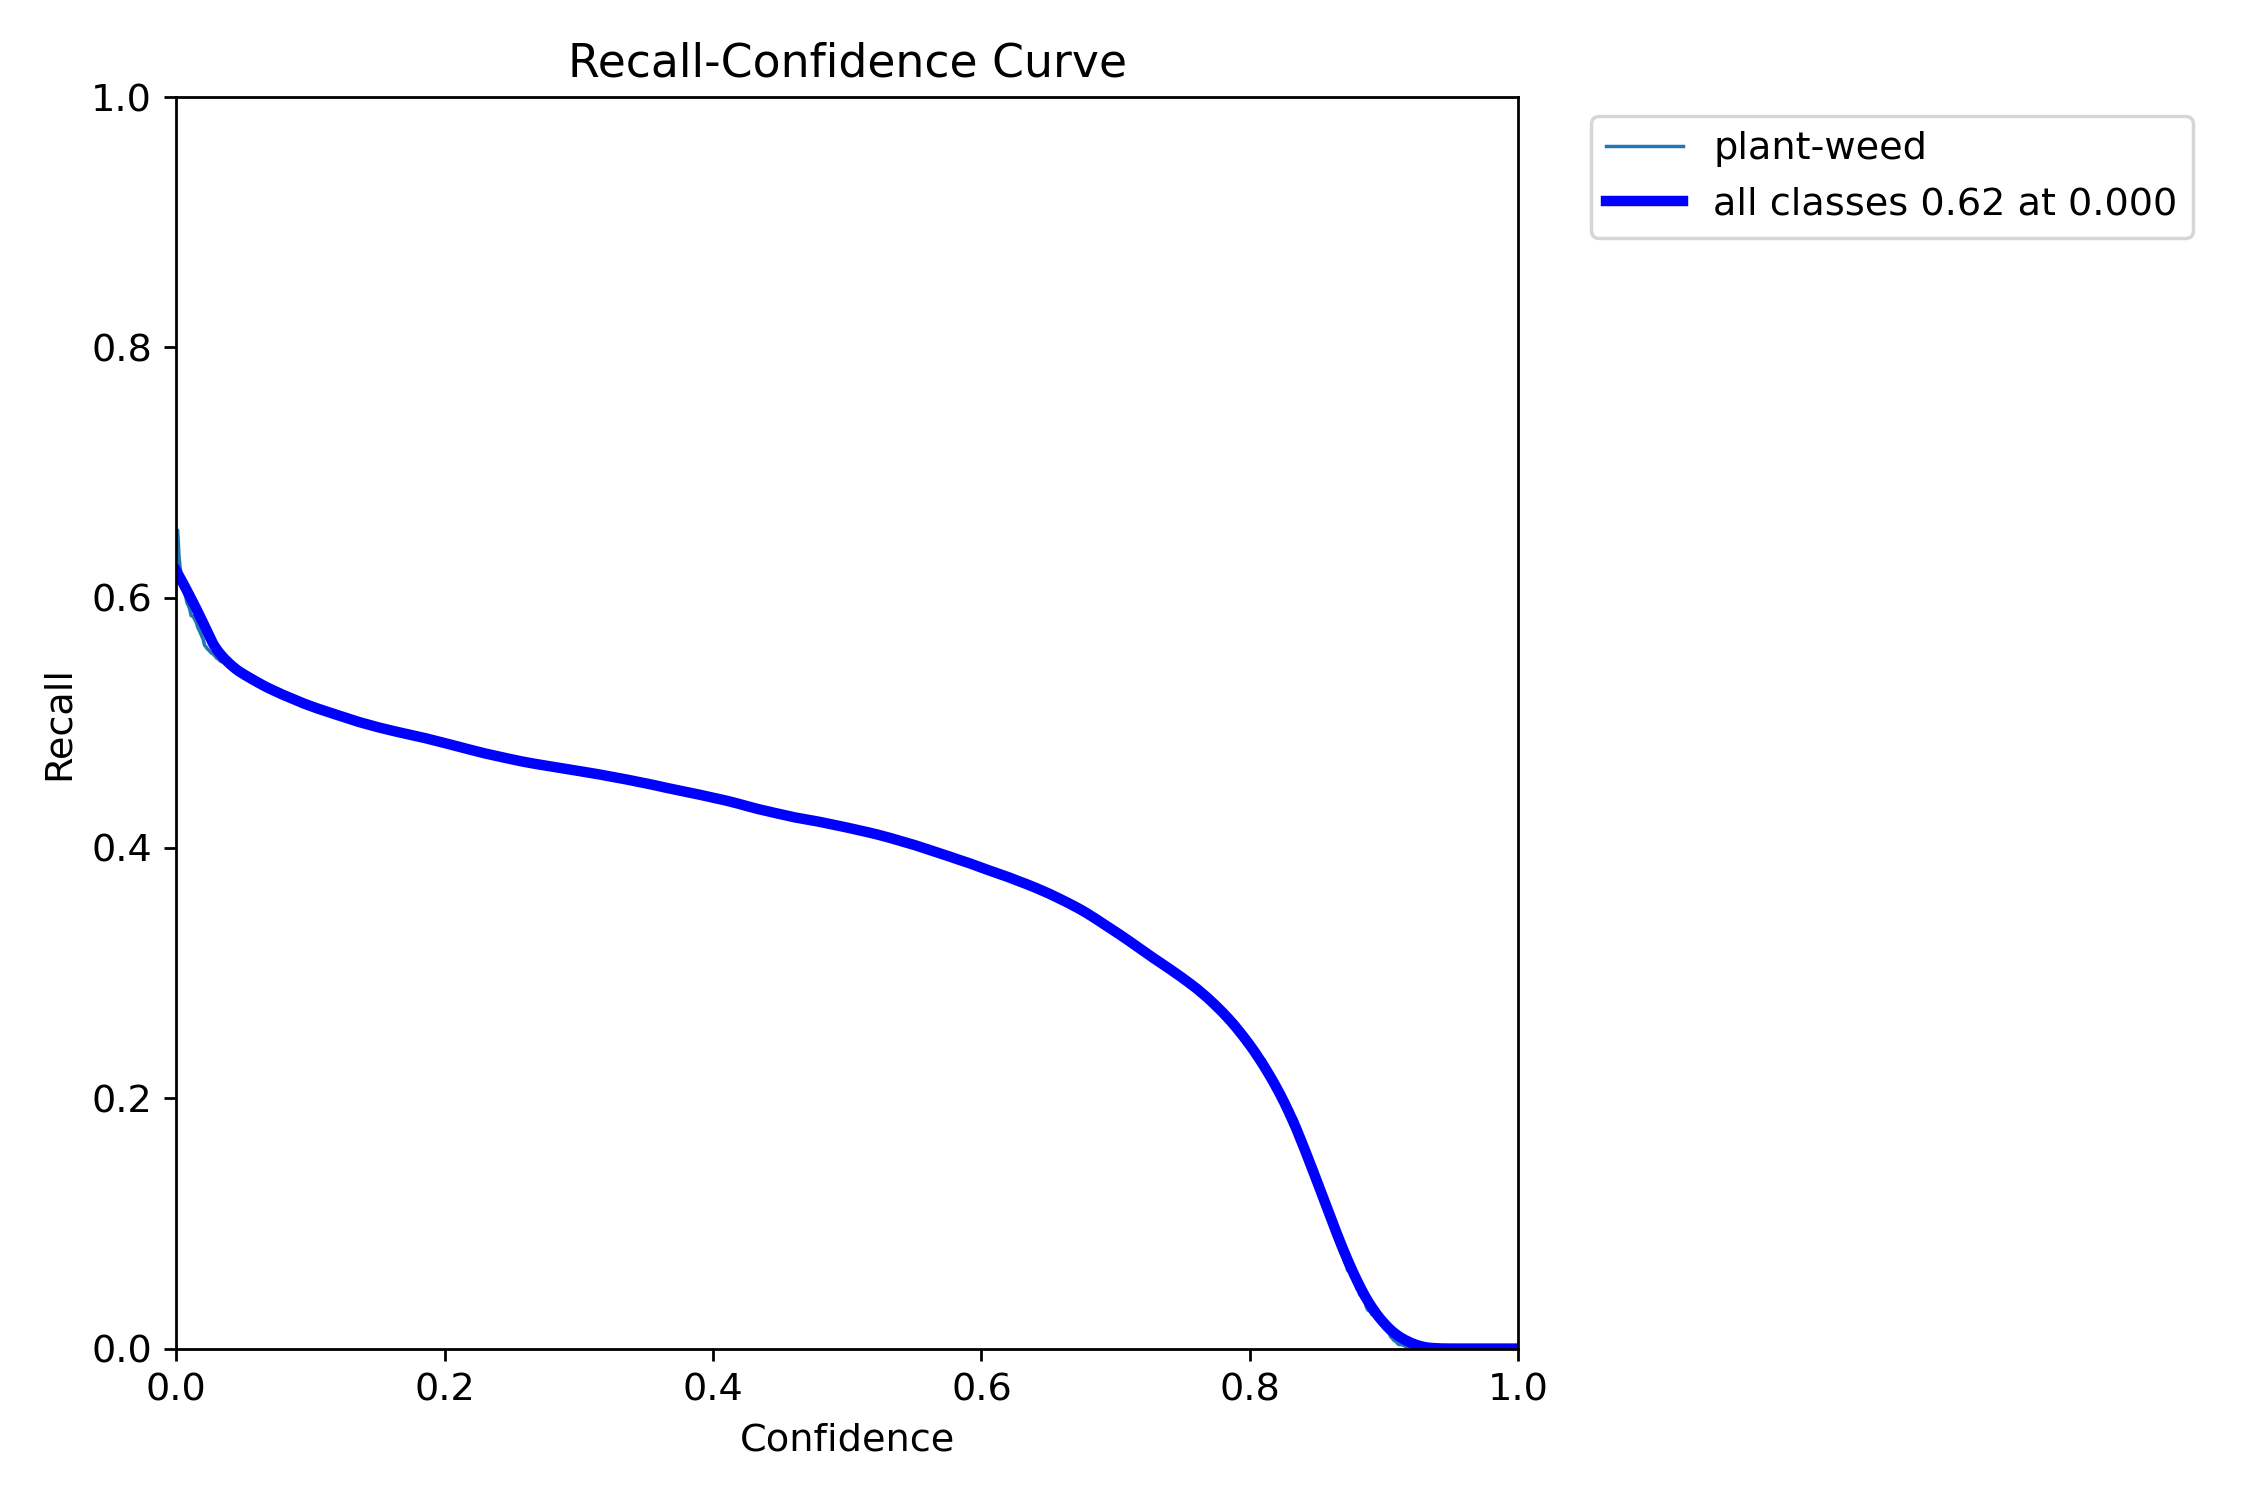

In [39]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

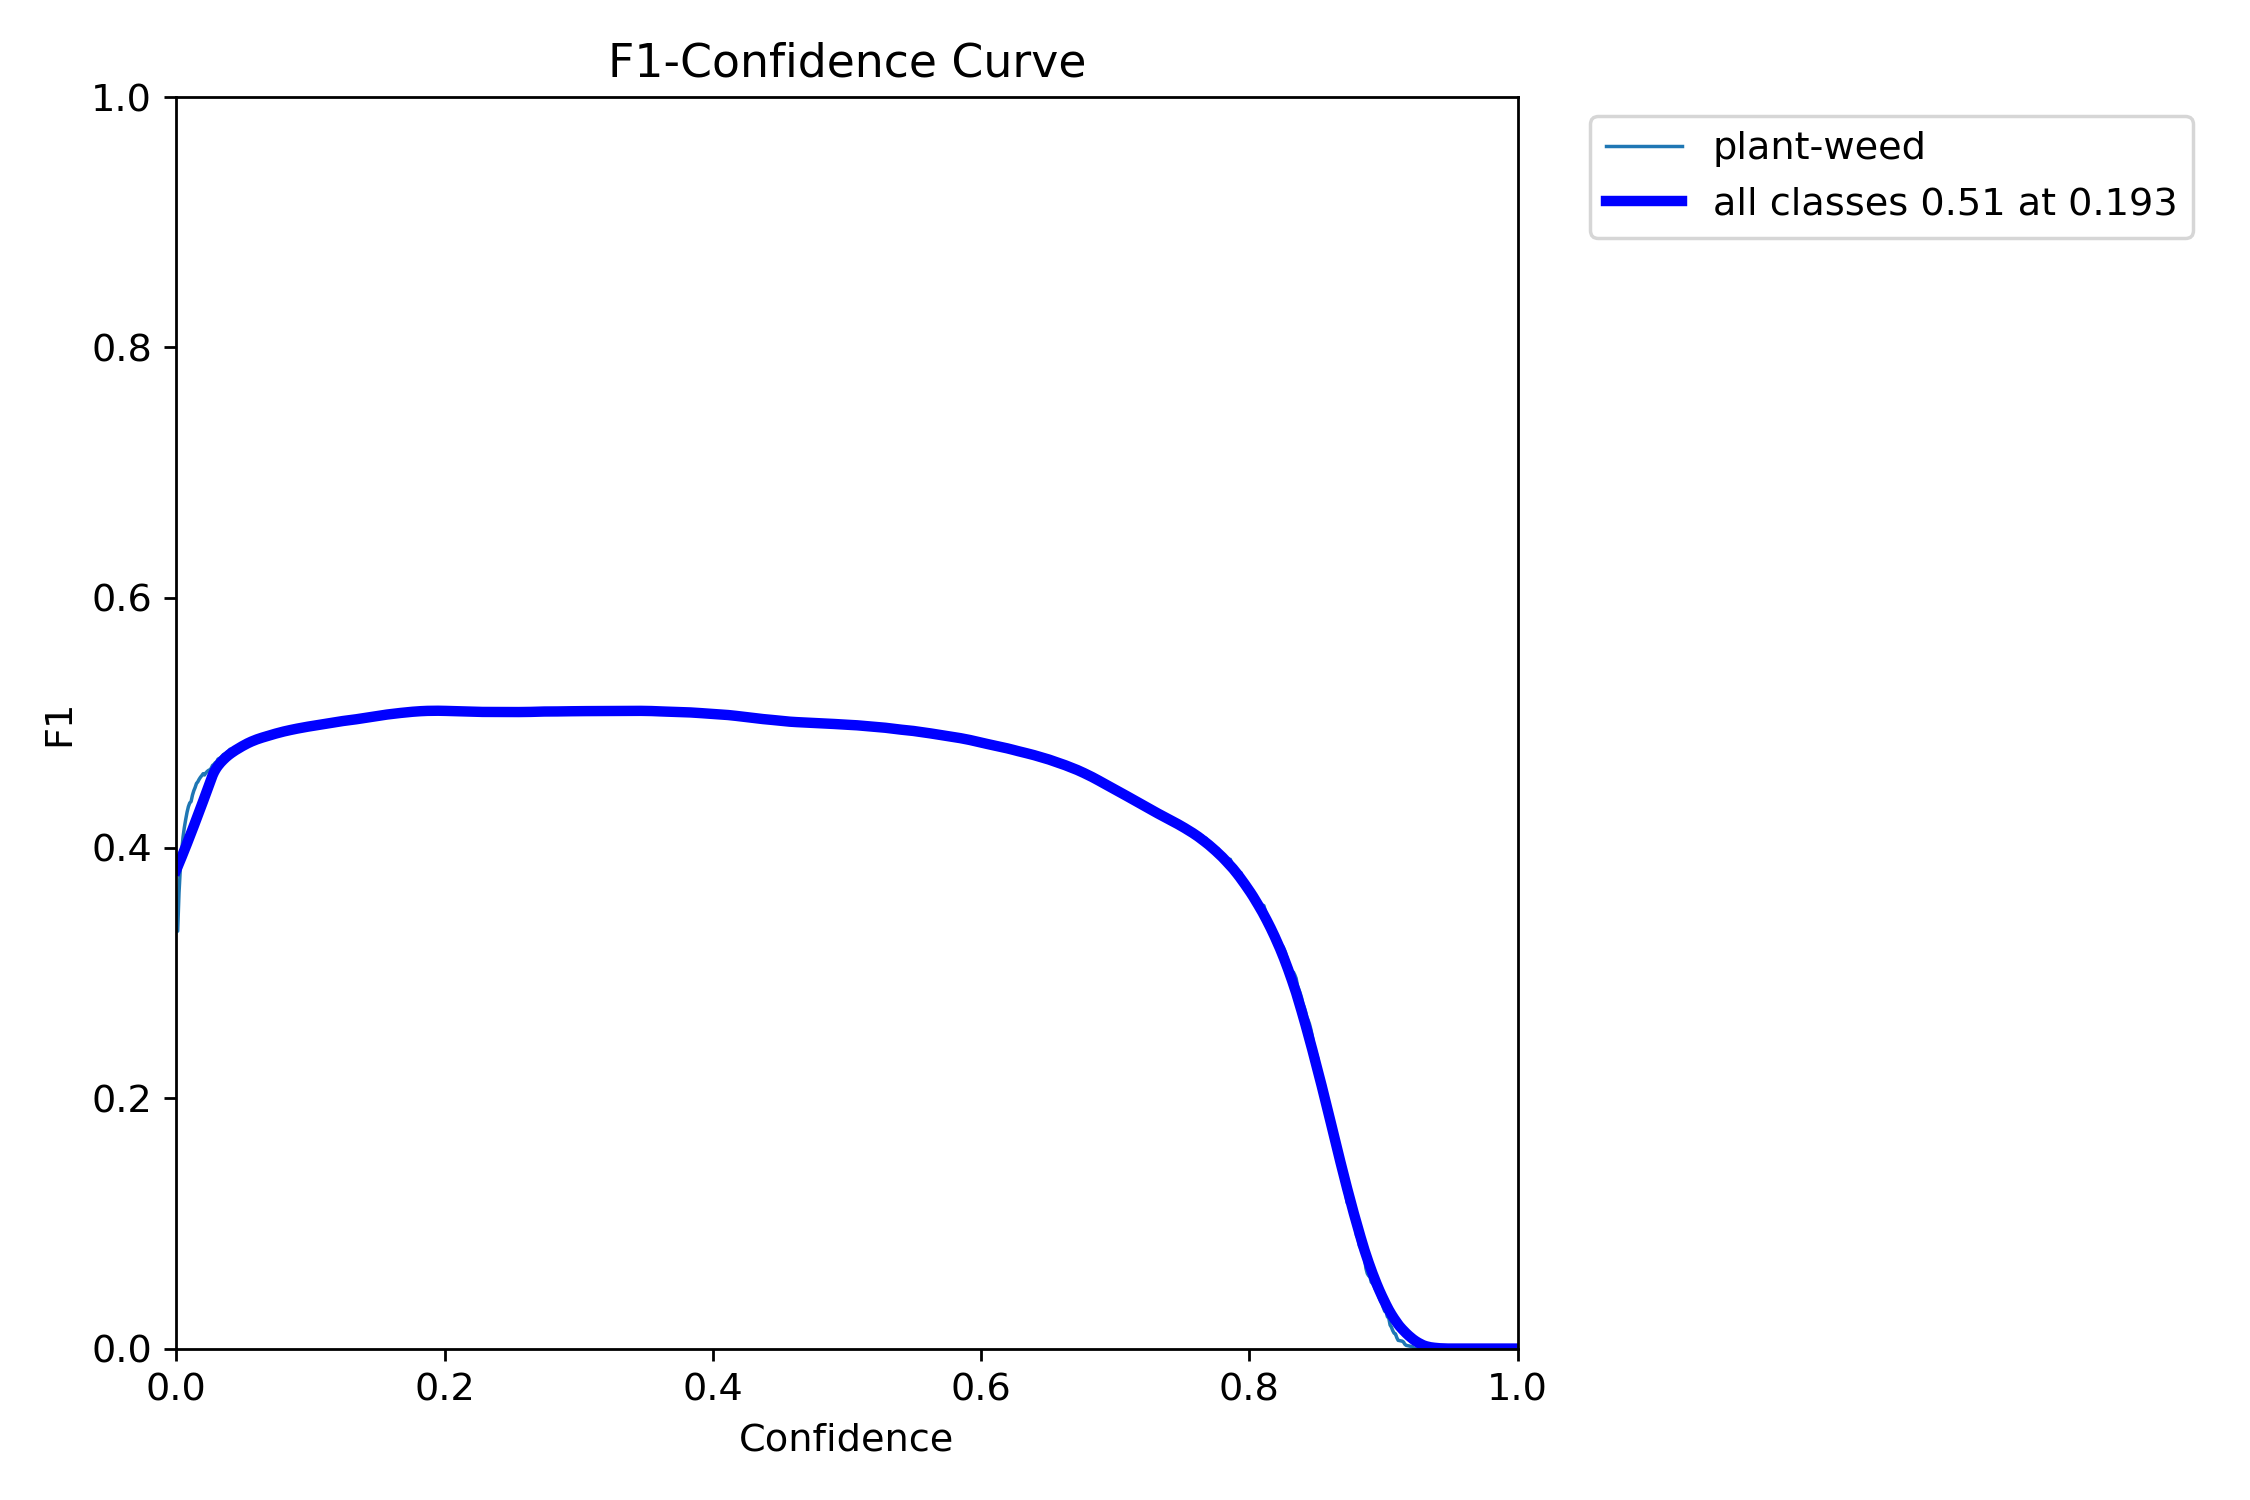

In [40]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

# References

## Experiment 18
### *Nano | ~1000 epochs*

In [41]:
target_folder = f"docs/Experimentos/3 Hyperparams/1 set/runs/detect/"
#fproject_root = "../" * 6
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/3 Hyperparams/1 set/runs/detect


In [42]:
folder = "train3/"

In [43]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df3 = pd.read_csv(file_path)
df = df3.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
221,222,1125.40,2.23649,1.61928,1.43502,0.44652,0.45039,0.39101,0.13160,2.36011,1.60253,1.40044,0.001562,0.001562,0.001562
222,223,1130.21,2.20629,1.62344,1.43156,0.44899,0.43794,0.39164,0.13329,2.37179,1.56748,1.40307,0.001560,0.001560,0.001560
223,224,1134.57,2.19571,1.58471,1.42590,0.44364,0.44454,0.40572,0.13581,2.39011,1.53731,1.40564,0.001558,0.001558,0.001558
224,225,1139.91,2.20646,1.58879,1.43160,0.45728,0.43545,0.39782,0.13389,2.38029,1.57173,1.41324,0.001556,0.001556,0.001556
225,226,1144.57,2.19576,1.57899,1.41865,0.43754,0.45621,0.39654,0.13281,2.36951,1.58863,1.41229,0.001554,0.001554,0.001554


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [44]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 19.076 min


#### Best epoch

In [45]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
175,176,899.089,2.2371,1.60874,1.45009,0.46467,0.46866,0.41842,0.14136,2.34734,1.61653,1.40512,0.001654,0.001654,0.001654,19.076167


In [46]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 176 con mAP50 de 0.418


In [47]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [48]:
TP = 1446
FP = 1925
FN = 963
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 4334


In [49]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.33364097831102907, 0.44416243654822335, 0.22219658514074758)

### Graphs

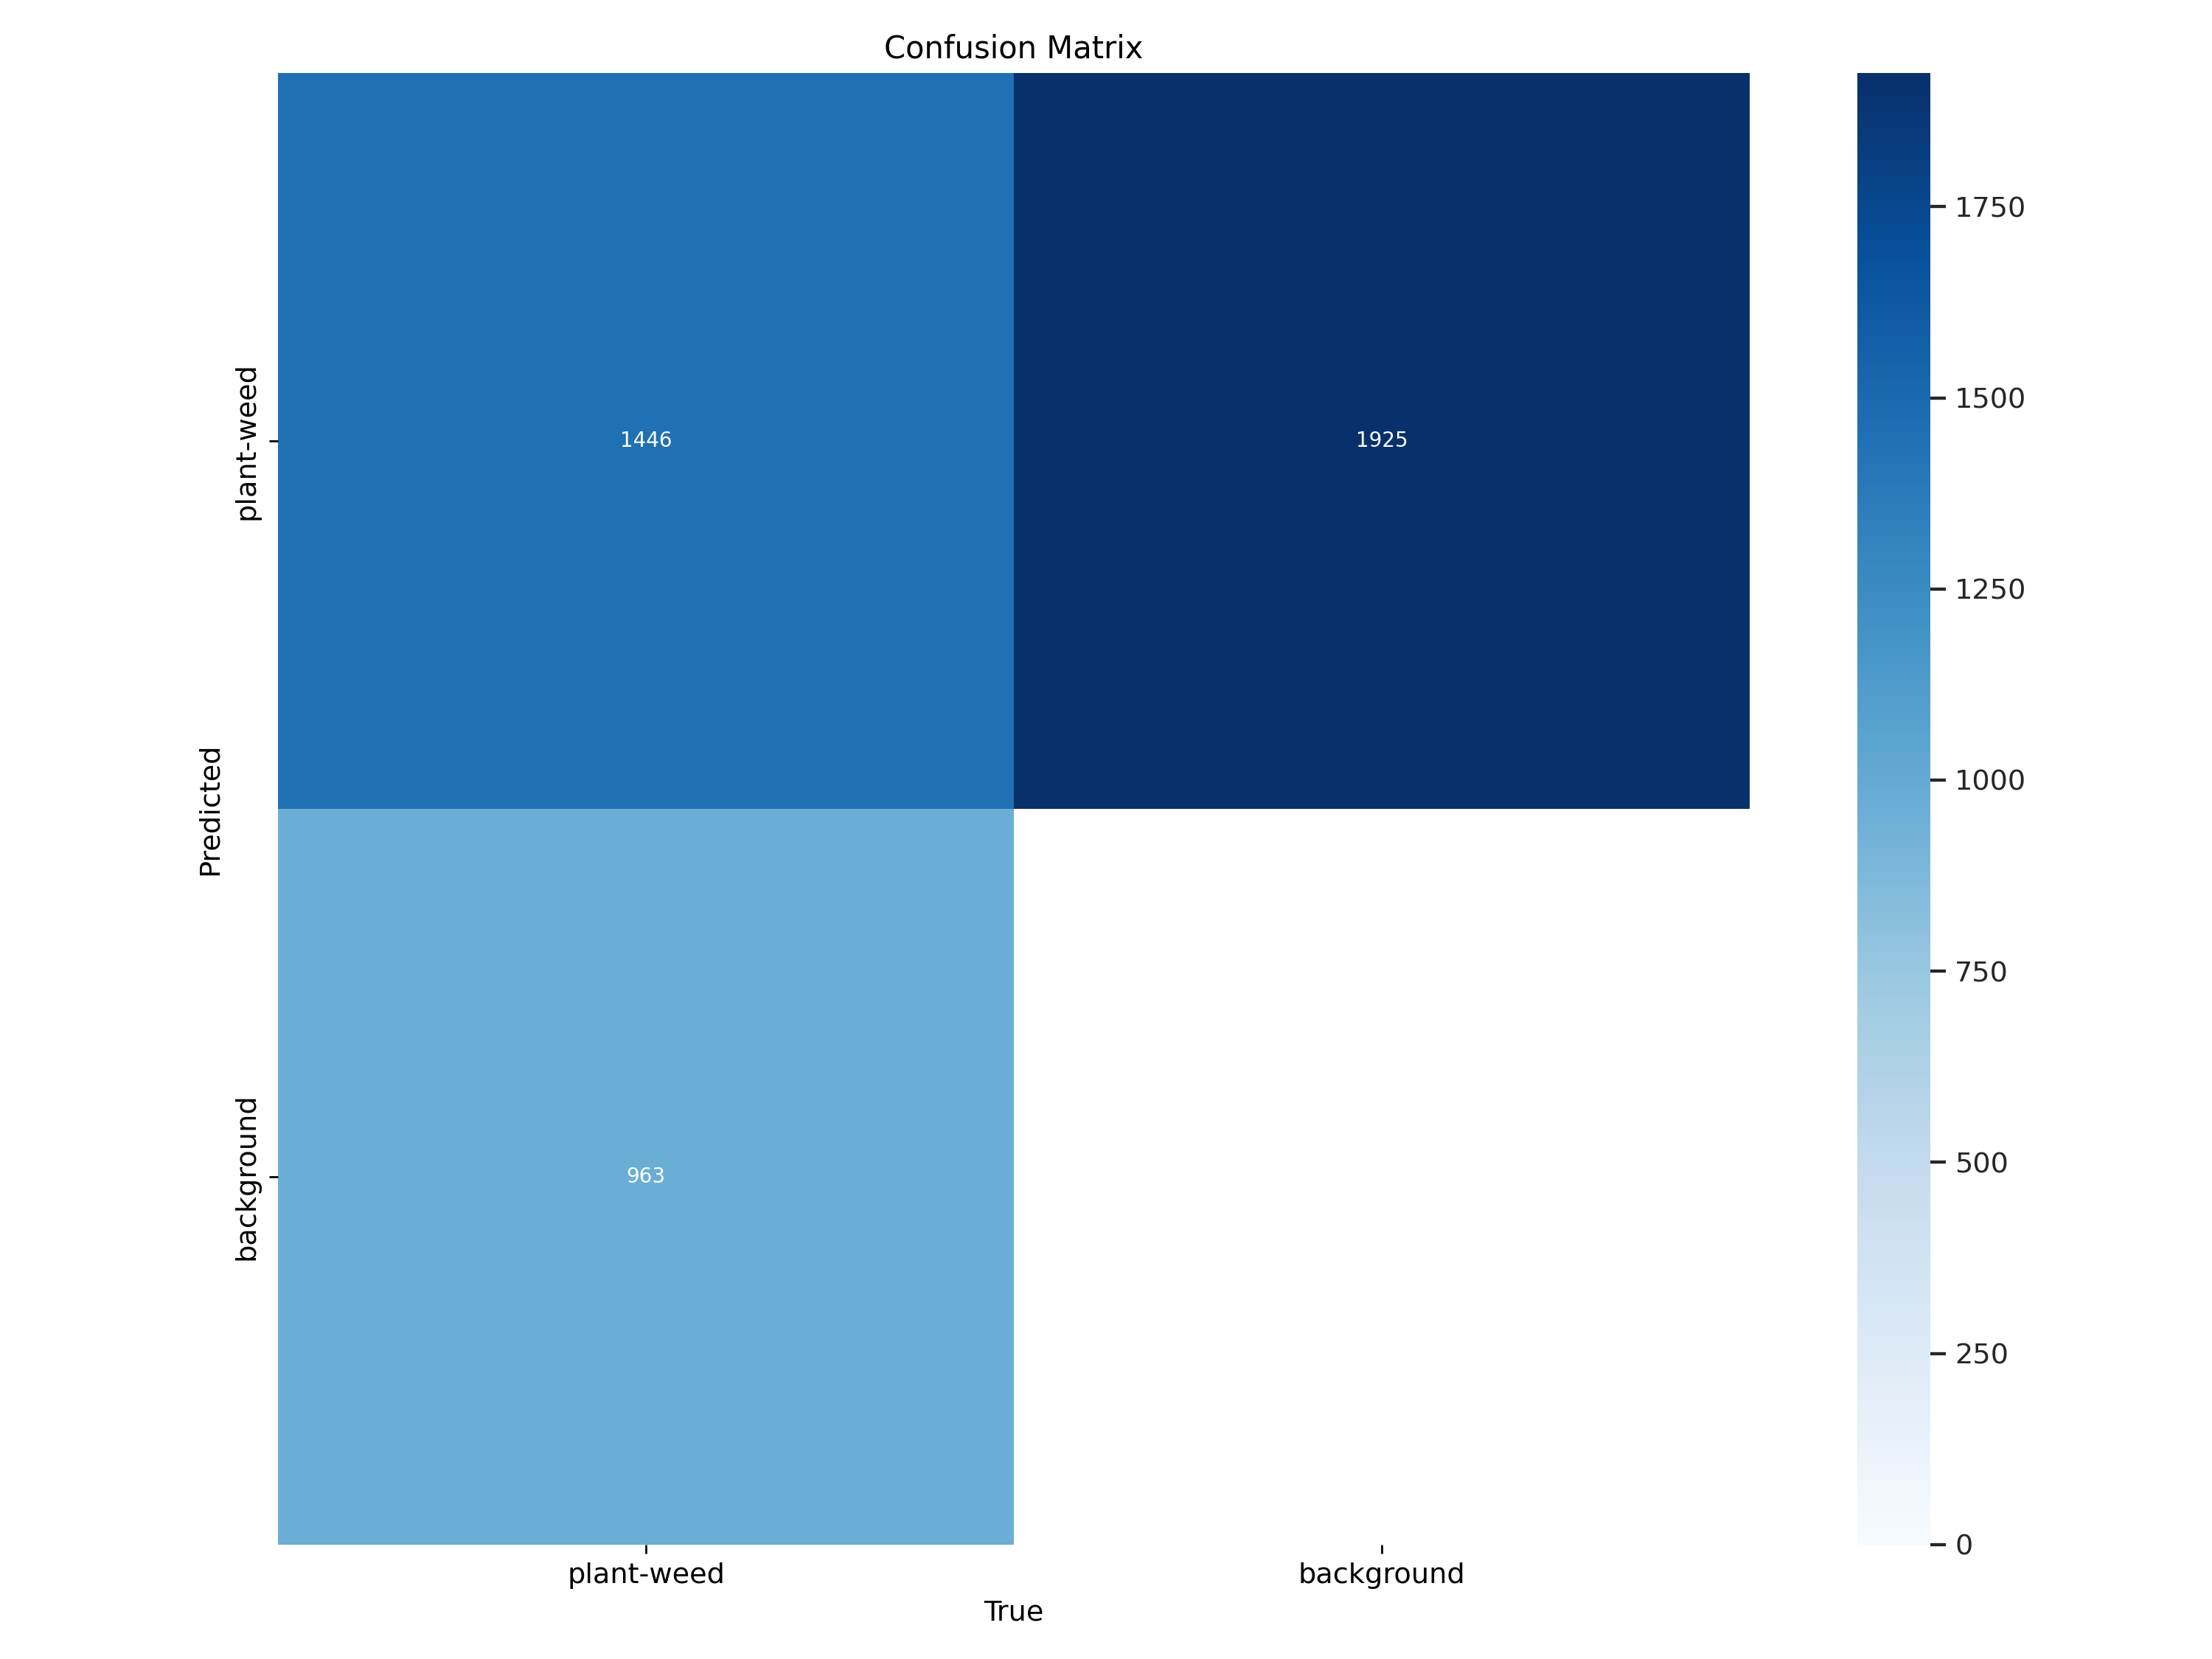

In [50]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

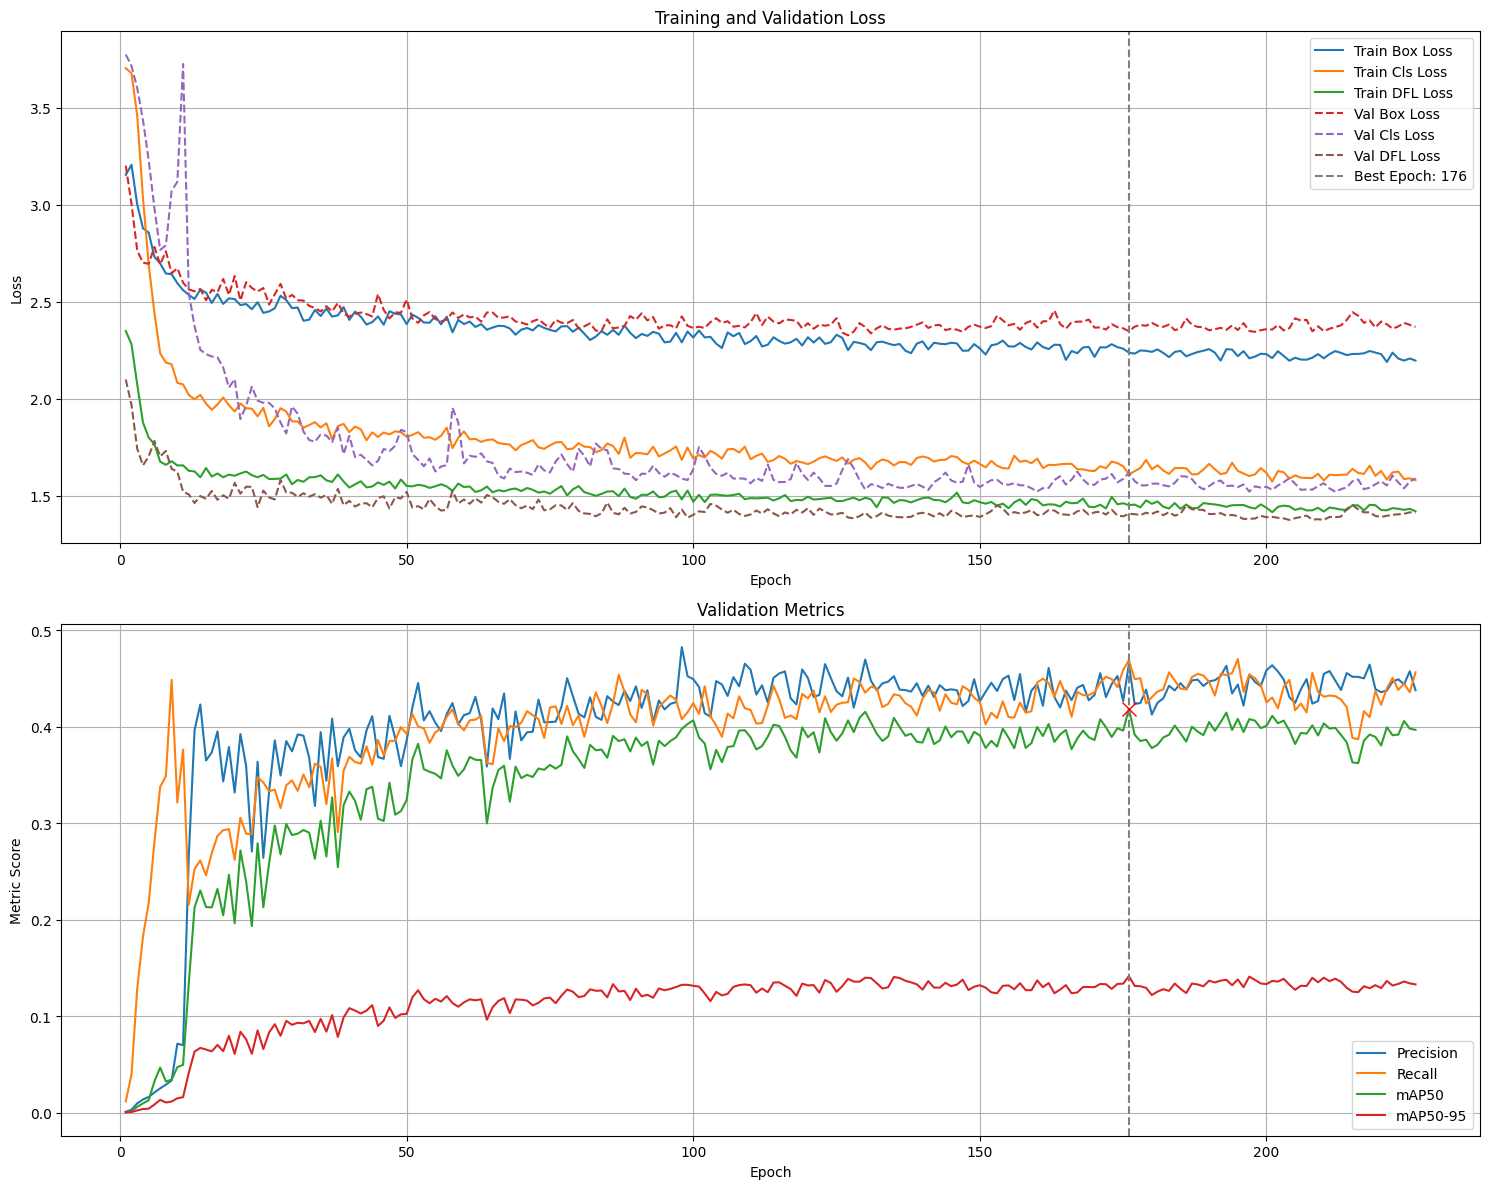

In [51]:
graph_training_metrics(df3, epoch, graph="full")

In [52]:
graph_LrLoss_3D(df3)

Validation set


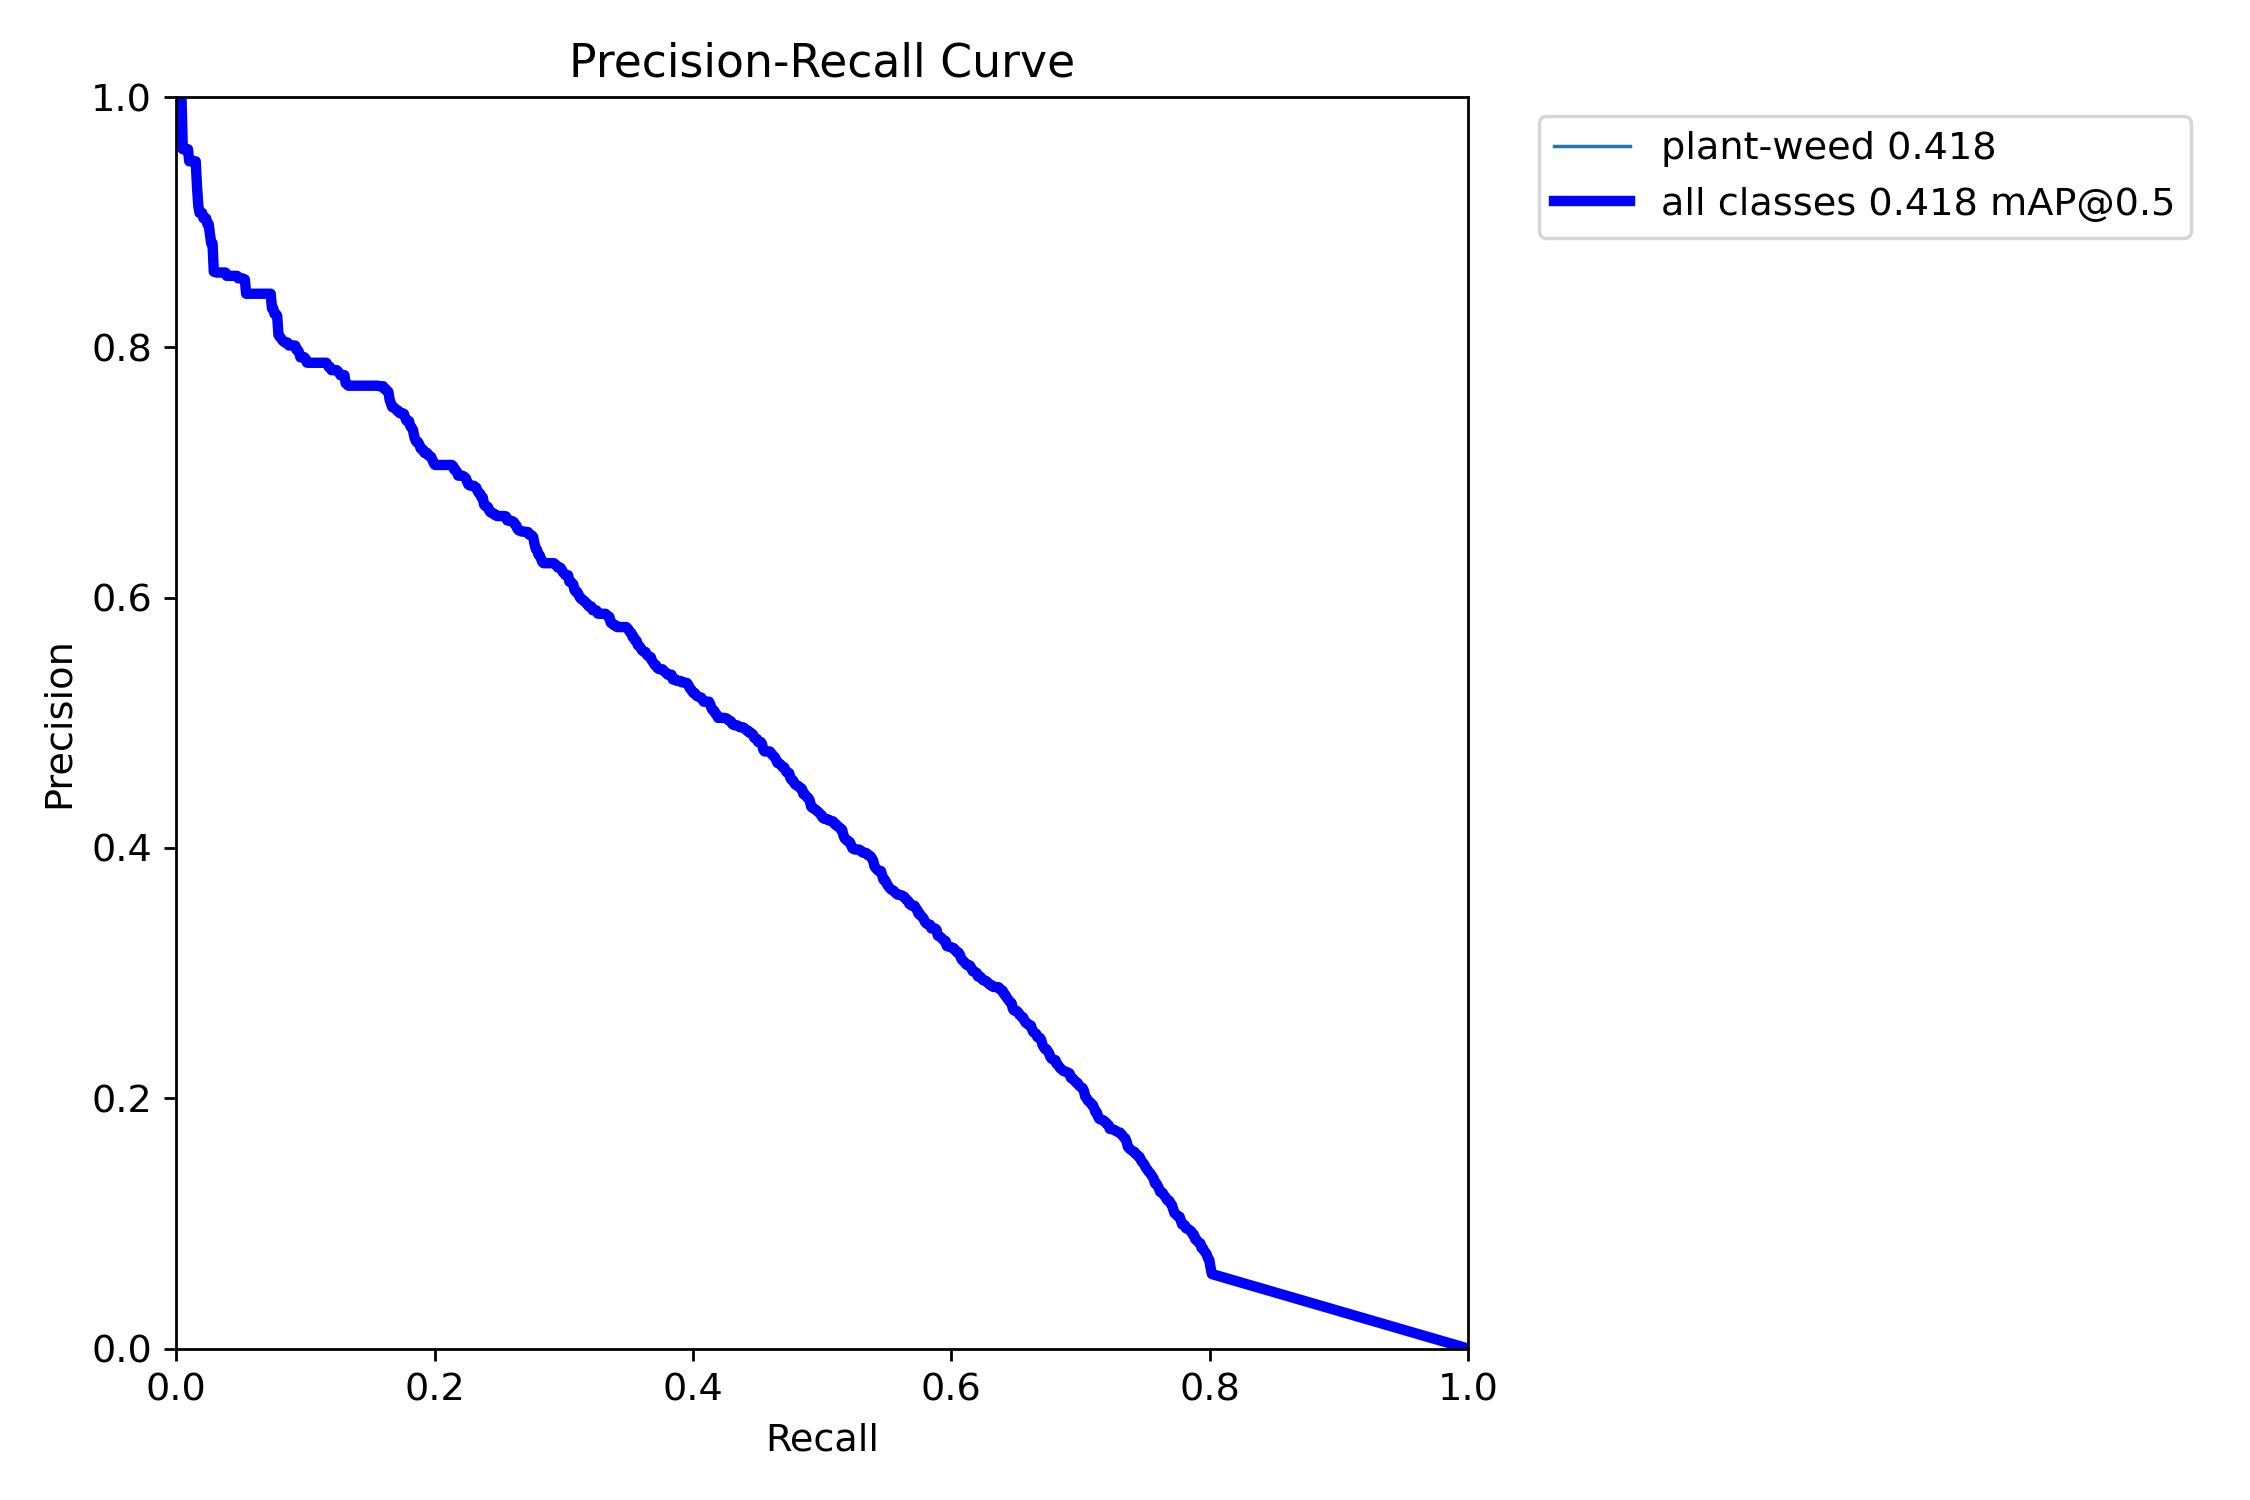

In [53]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

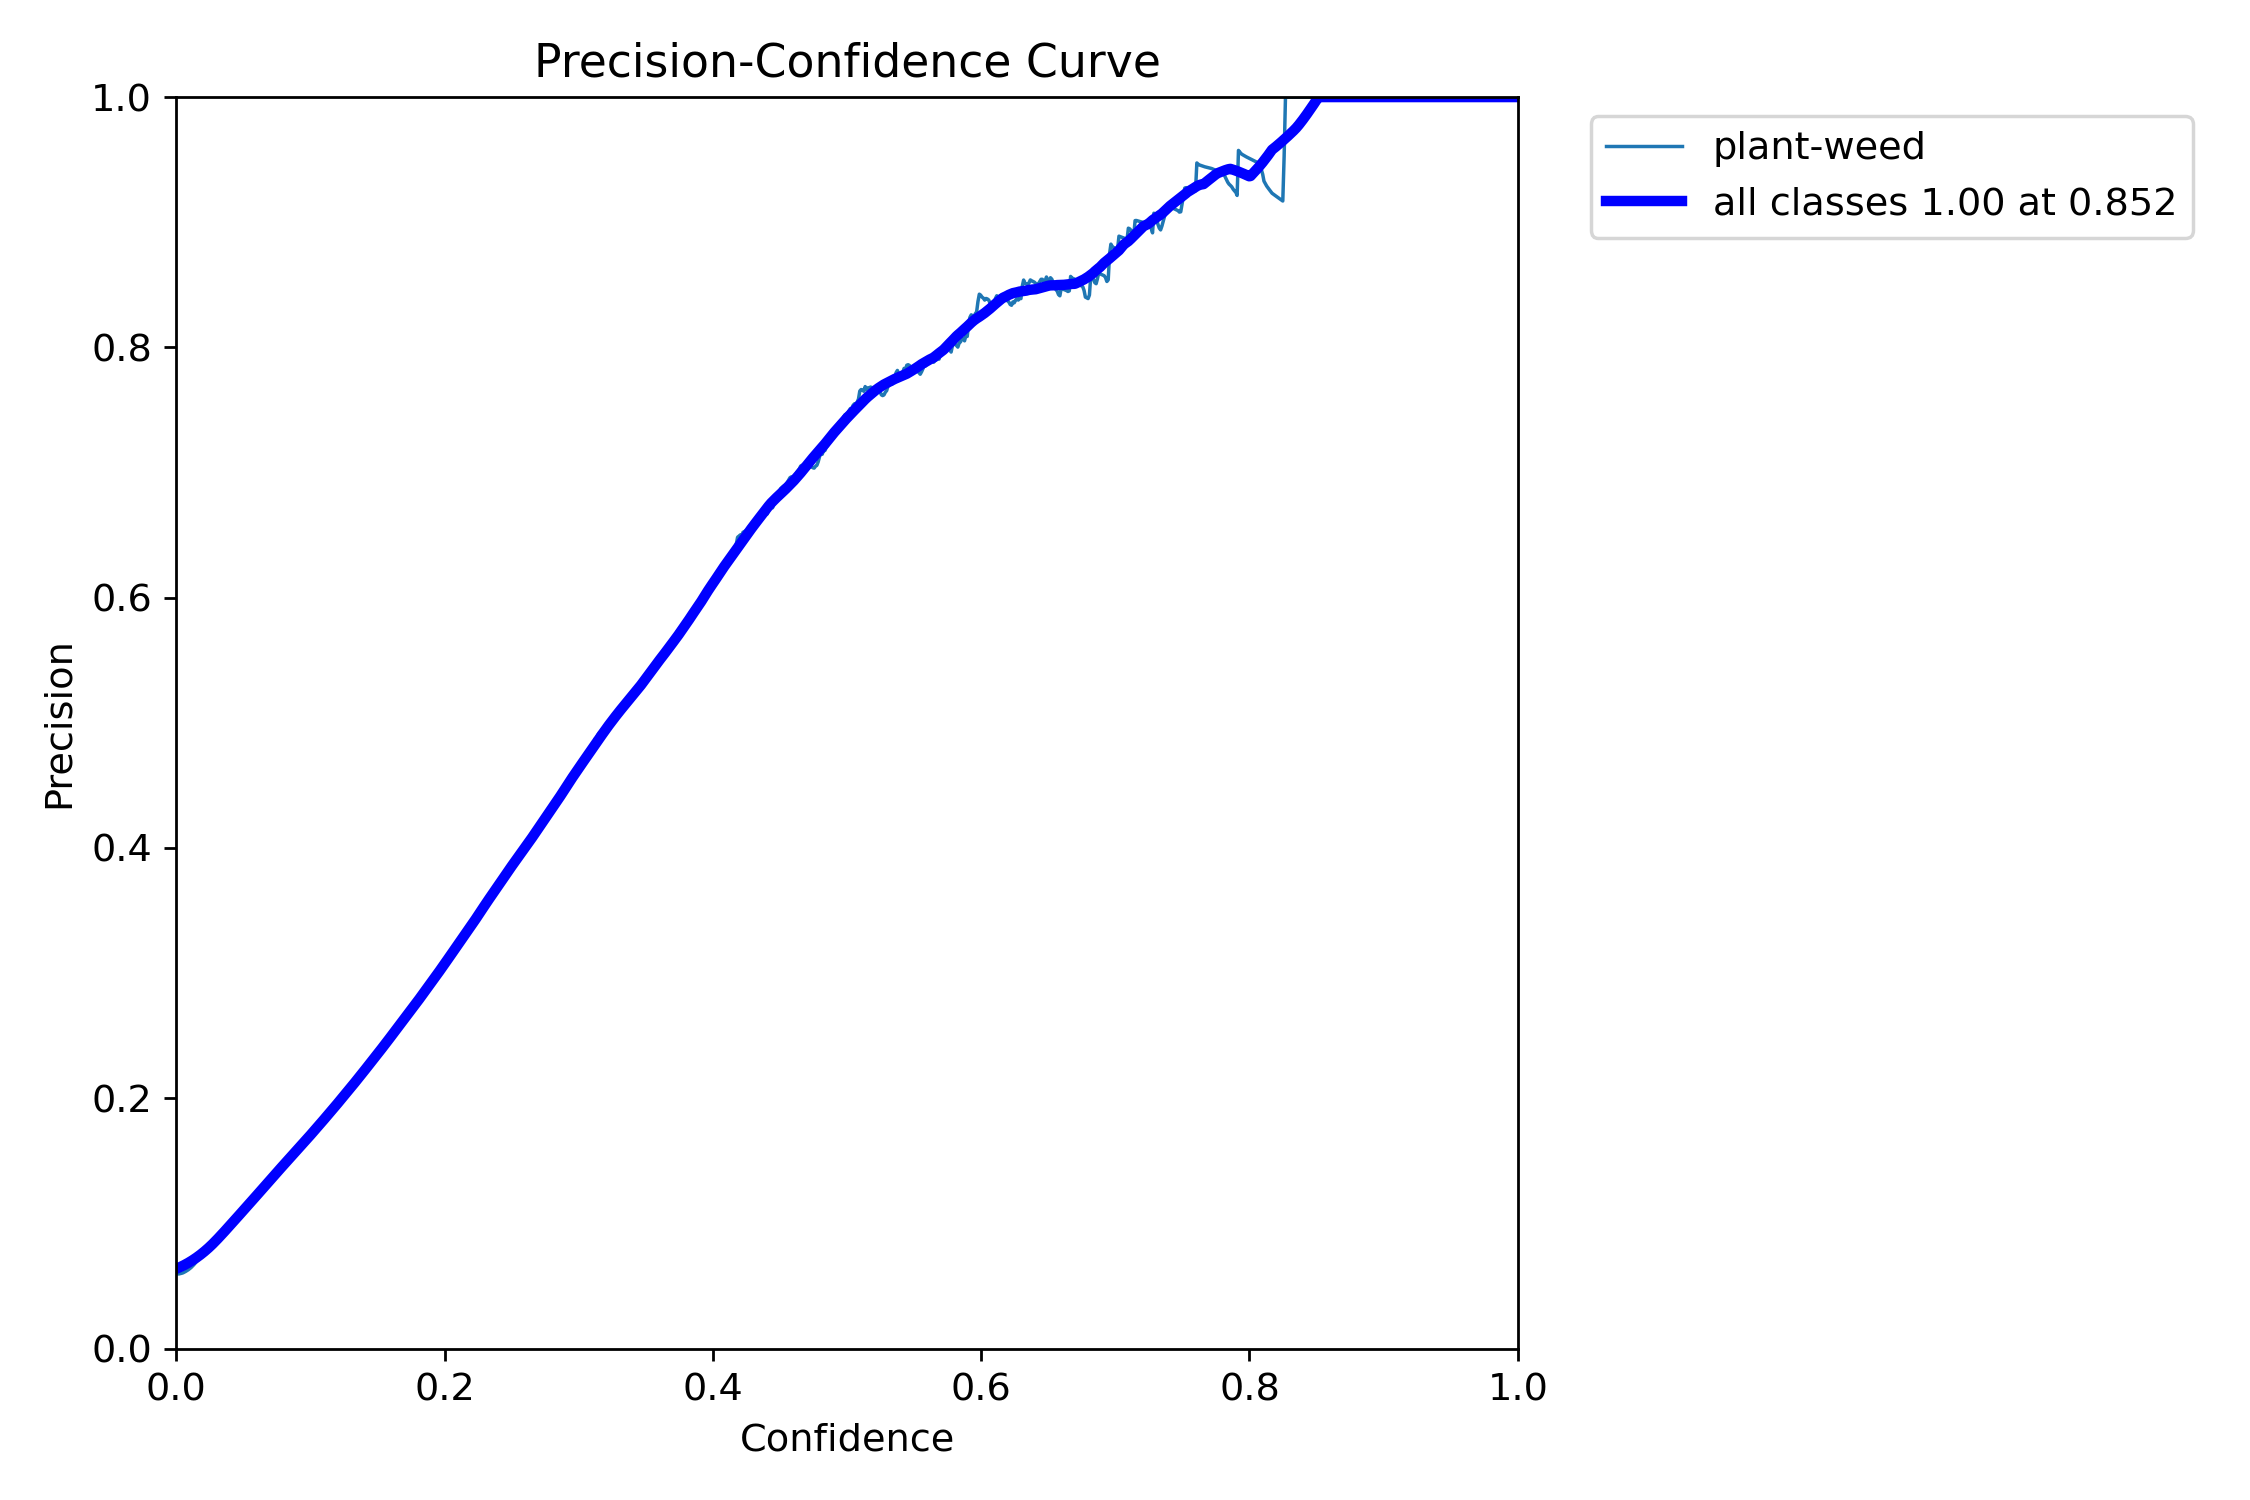

In [54]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

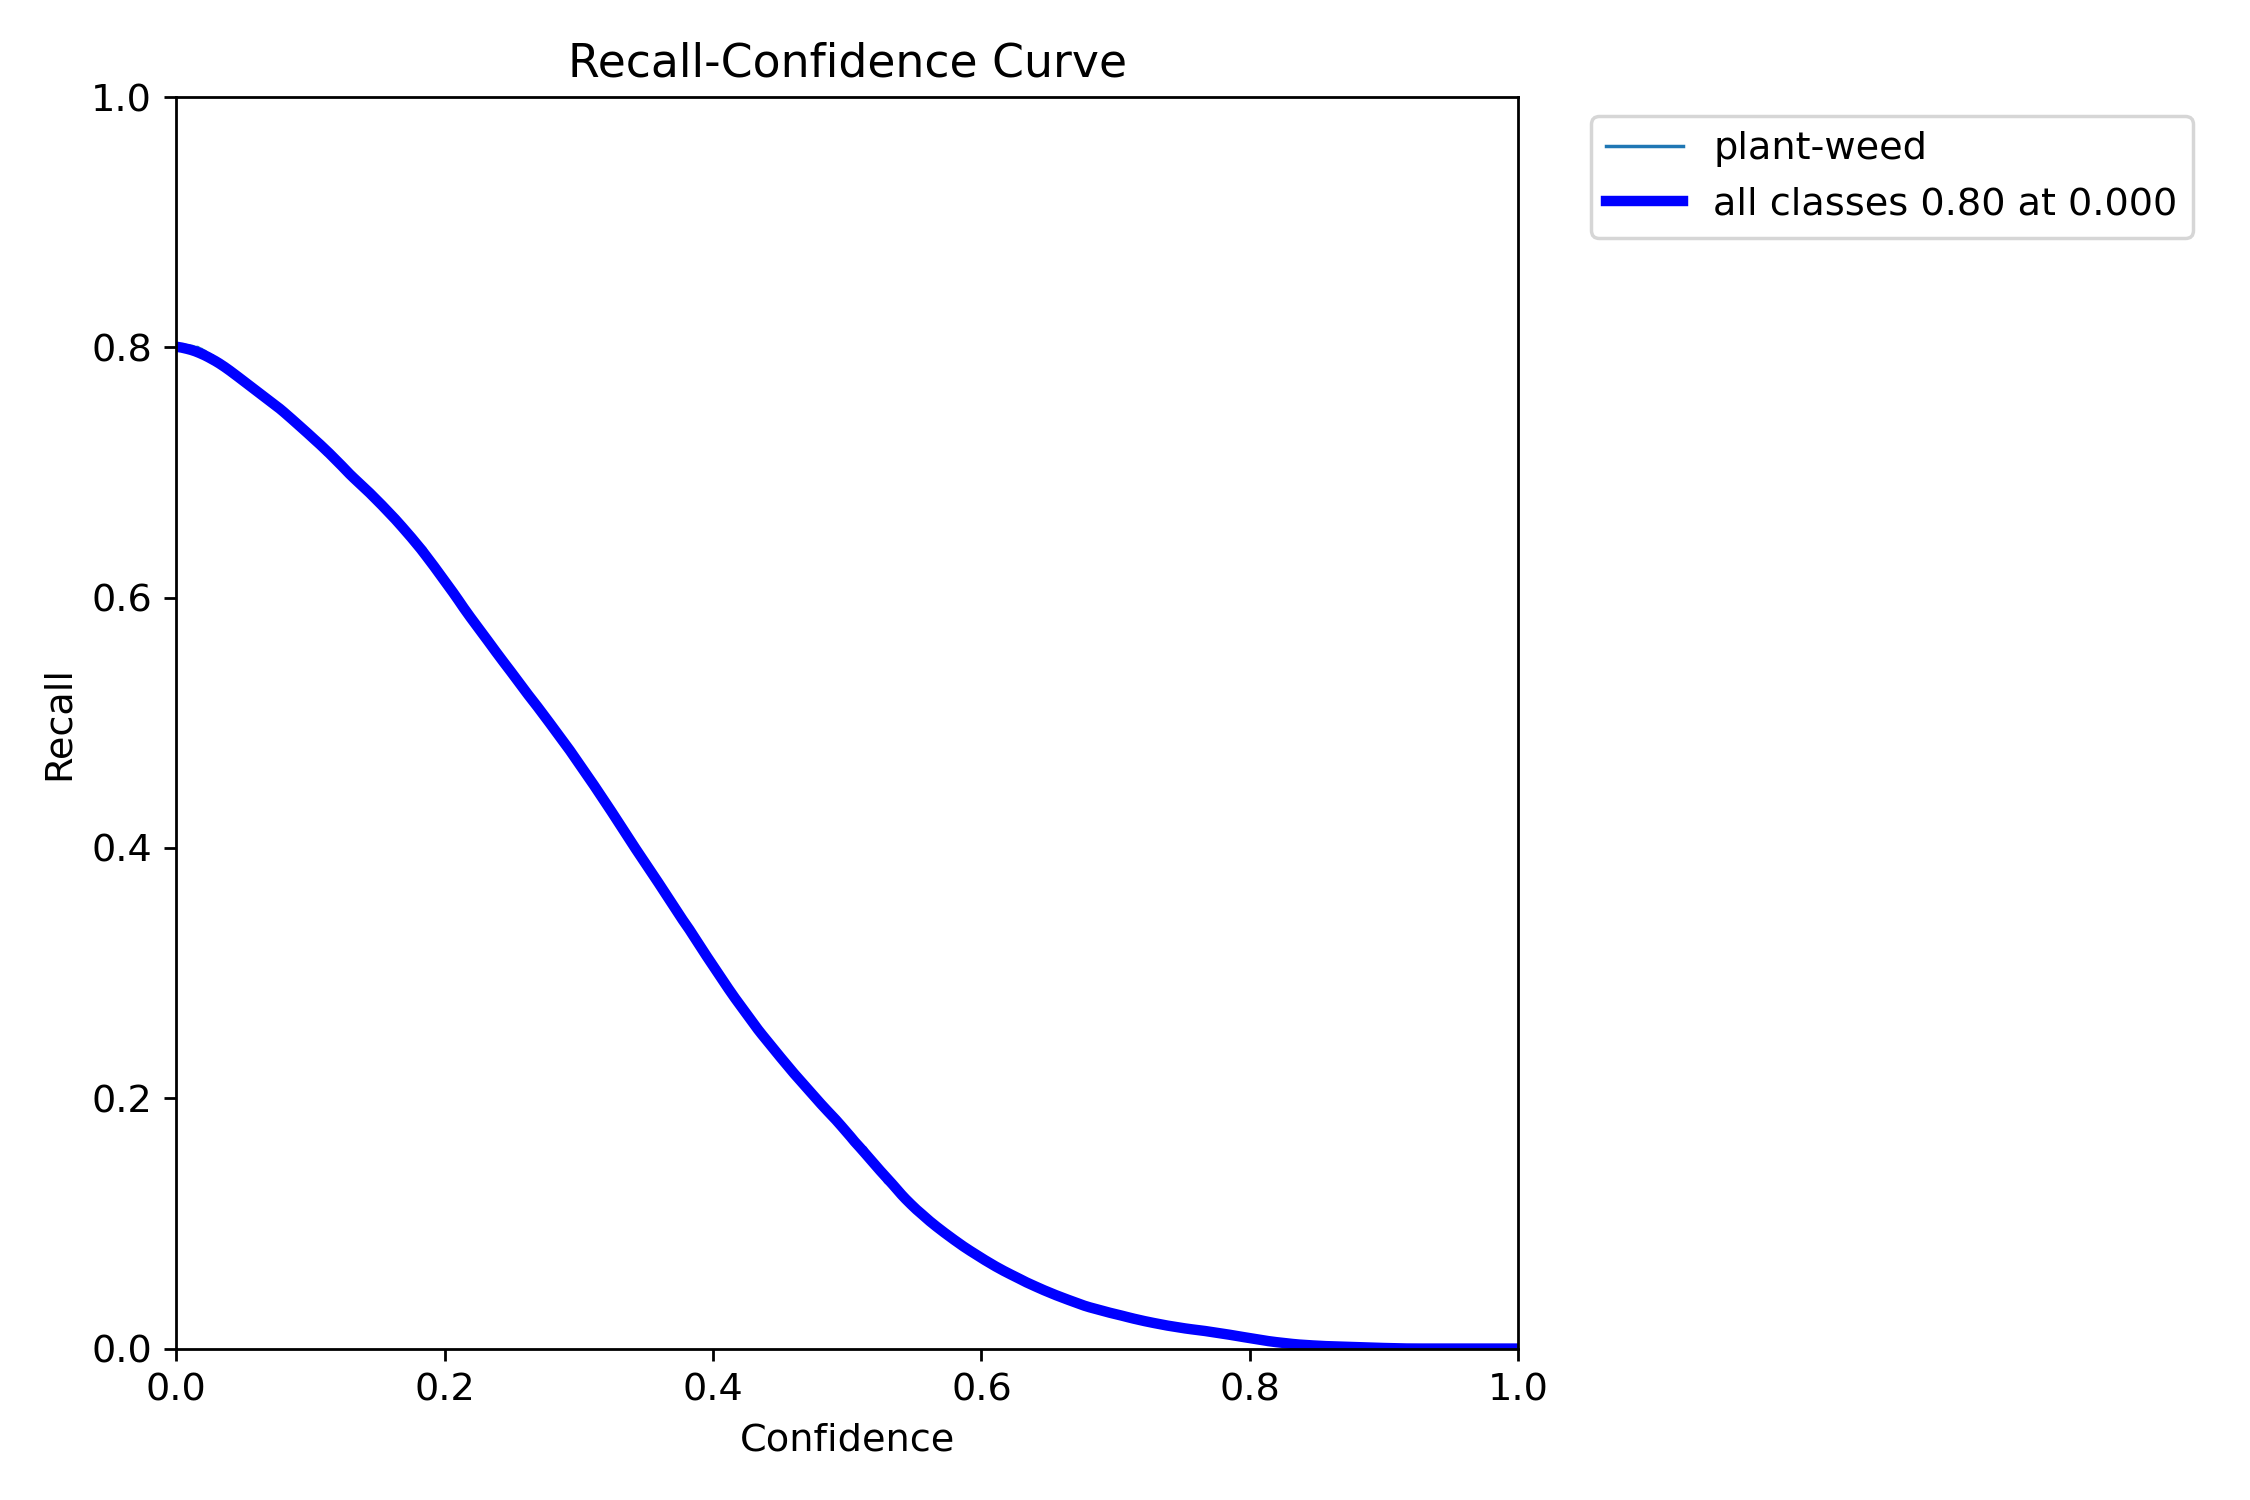

In [55]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

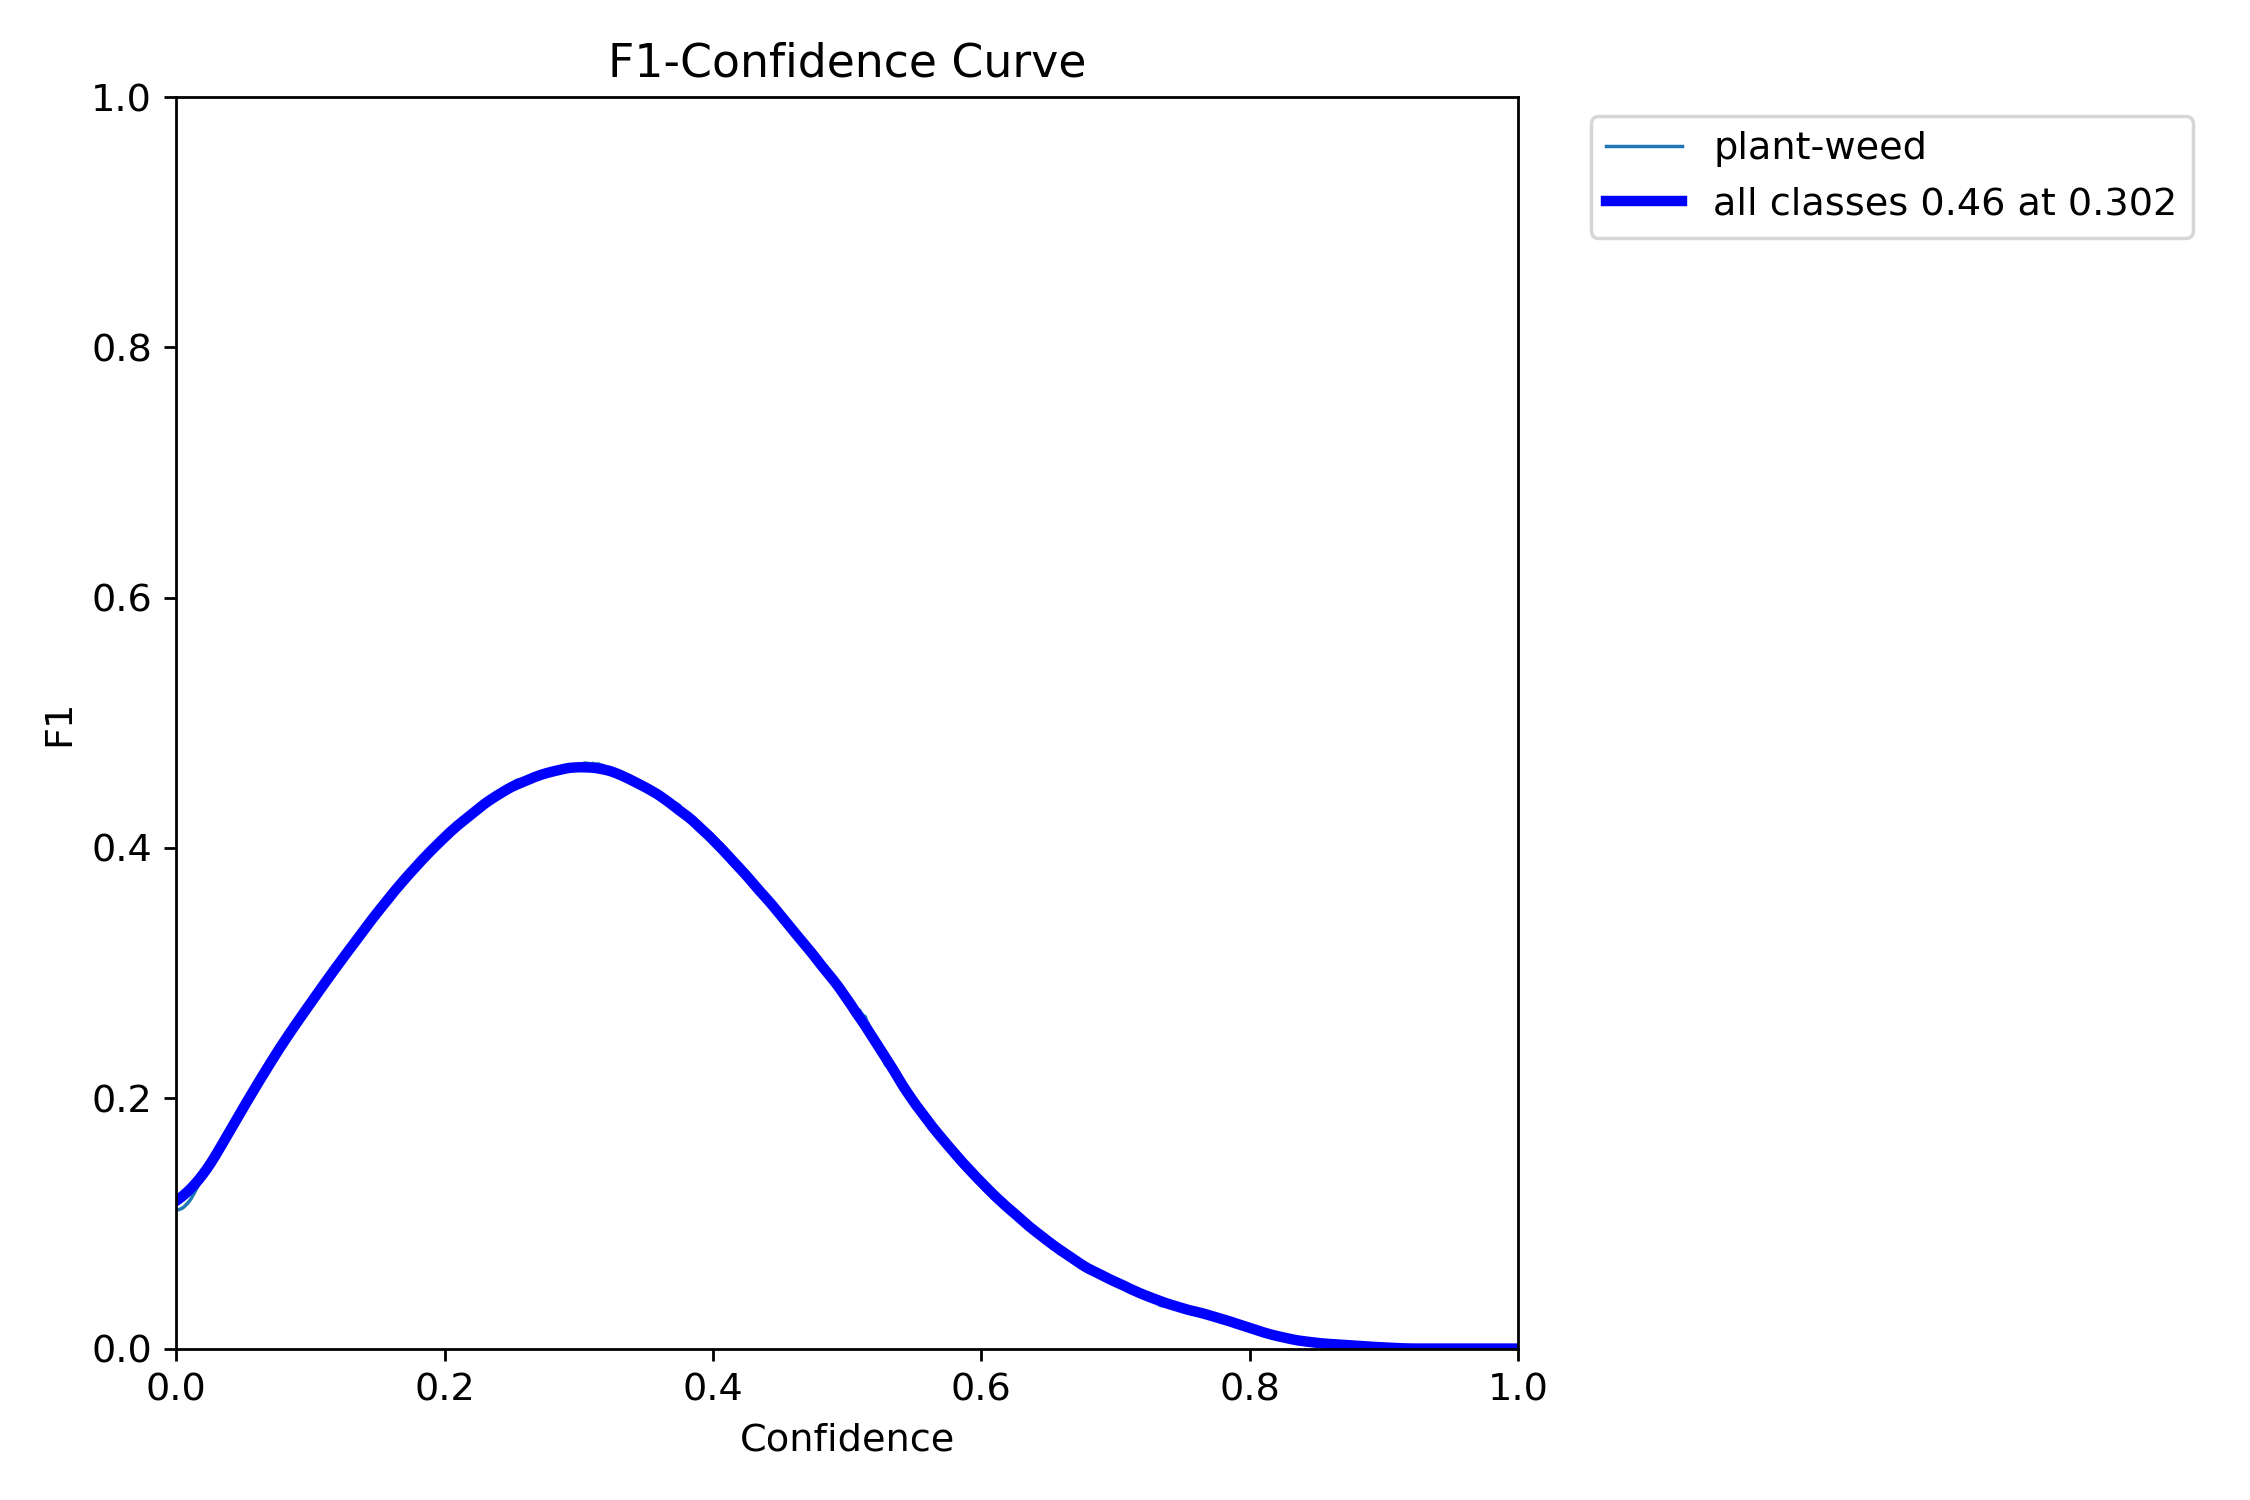

In [56]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

From the F1 curve, the confidence value that optimizes precision and recall is 0.231. In many cases a higher confidence value is desirable.

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- La pérdida de caja (box_loss), clasificación (cls_loss) y dfl (distribution focal loss) disminuyen a lo largo de las épocas tanto en entrenamiento como validación.
- Esto indica que el modelo está aprendiendo a ajustar mejor las predicciones, pero es importante verificar si hay sobreajuste (train_loss << val_loss).

2. **Métricas de validación (Precisión, Recall, mAP)**

- Precisión (precision), Recall y mAP aumentan progresivamente, lo que indica que el modelo mejora en la detección.
- El mAP50-95 es bastante bajo, lo que sugiere que el modelo tiene dificultades en predicciones a diferentes IoUs.

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- El learning rate comienza en 0.00006, aumenta progresivamente y sigue creciendo a lo largo del entrenamiento.
- Es clave verificar si en las últimas épocas empieza a descender o si se estabiliza en un valor óptimo.

----

## Experiment 19
### *Medium | ~1000 epochs*

In [57]:
target_folder = f"docs/Experimentos/5 Model version/1 set/"
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/5 Model version/1 set


In [58]:
folder = "v8/detect/train/"

In [59]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df4 = pd.read_csv(file_path)
df = df4.copy()
df4.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
385,386,2985.60,1.16564,0.64824,1.00079,0.51783,0.44915,0.42026,0.13158,2.71083,1.35703,1.74103,0.001238,0.001238,0.001238
386,387,2993.32,1.16003,0.64194,1.00164,0.49944,0.45828,0.41433,0.13166,2.68775,1.35982,1.71300,0.001236,0.001236,0.001236
387,388,3001.15,1.20936,0.66569,1.00235,0.51585,0.48194,0.43181,0.13696,2.64976,1.37377,1.70644,0.001234,0.001234,0.001234
388,389,3008.95,1.19211,0.66791,1.00913,0.51908,0.48609,0.42939,0.13653,2.62402,1.36774,1.70599,0.001232,0.001232,0.001232
389,390,3016.91,1.16665,0.65433,1.00045,0.52793,0.48187,0.43890,0.13979,2.61230,1.35686,1.70114,0.001230,0.001230,0.001230


In [60]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 50.282 min


#### Best epoch

In [61]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
360,361,2792.5,1.20257,0.66073,1.00807,0.54572,0.48236,0.45092,0.14408,2.61832,1.37244,1.71799,0.001287,0.001287,0.001287,50.281833


In [62]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print("Proceso de entrenamiento:")
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Proceso de entrenamiento:
Mejor época de entrenamiento 361 con mAP50 de 0.451


In [63]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [64]:
TP = 1774
FP = 3374
FN = 635
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 5783


In [65]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.3067611966107557, 0.5834342037005015, 0.10980459968874287)

### Graphs

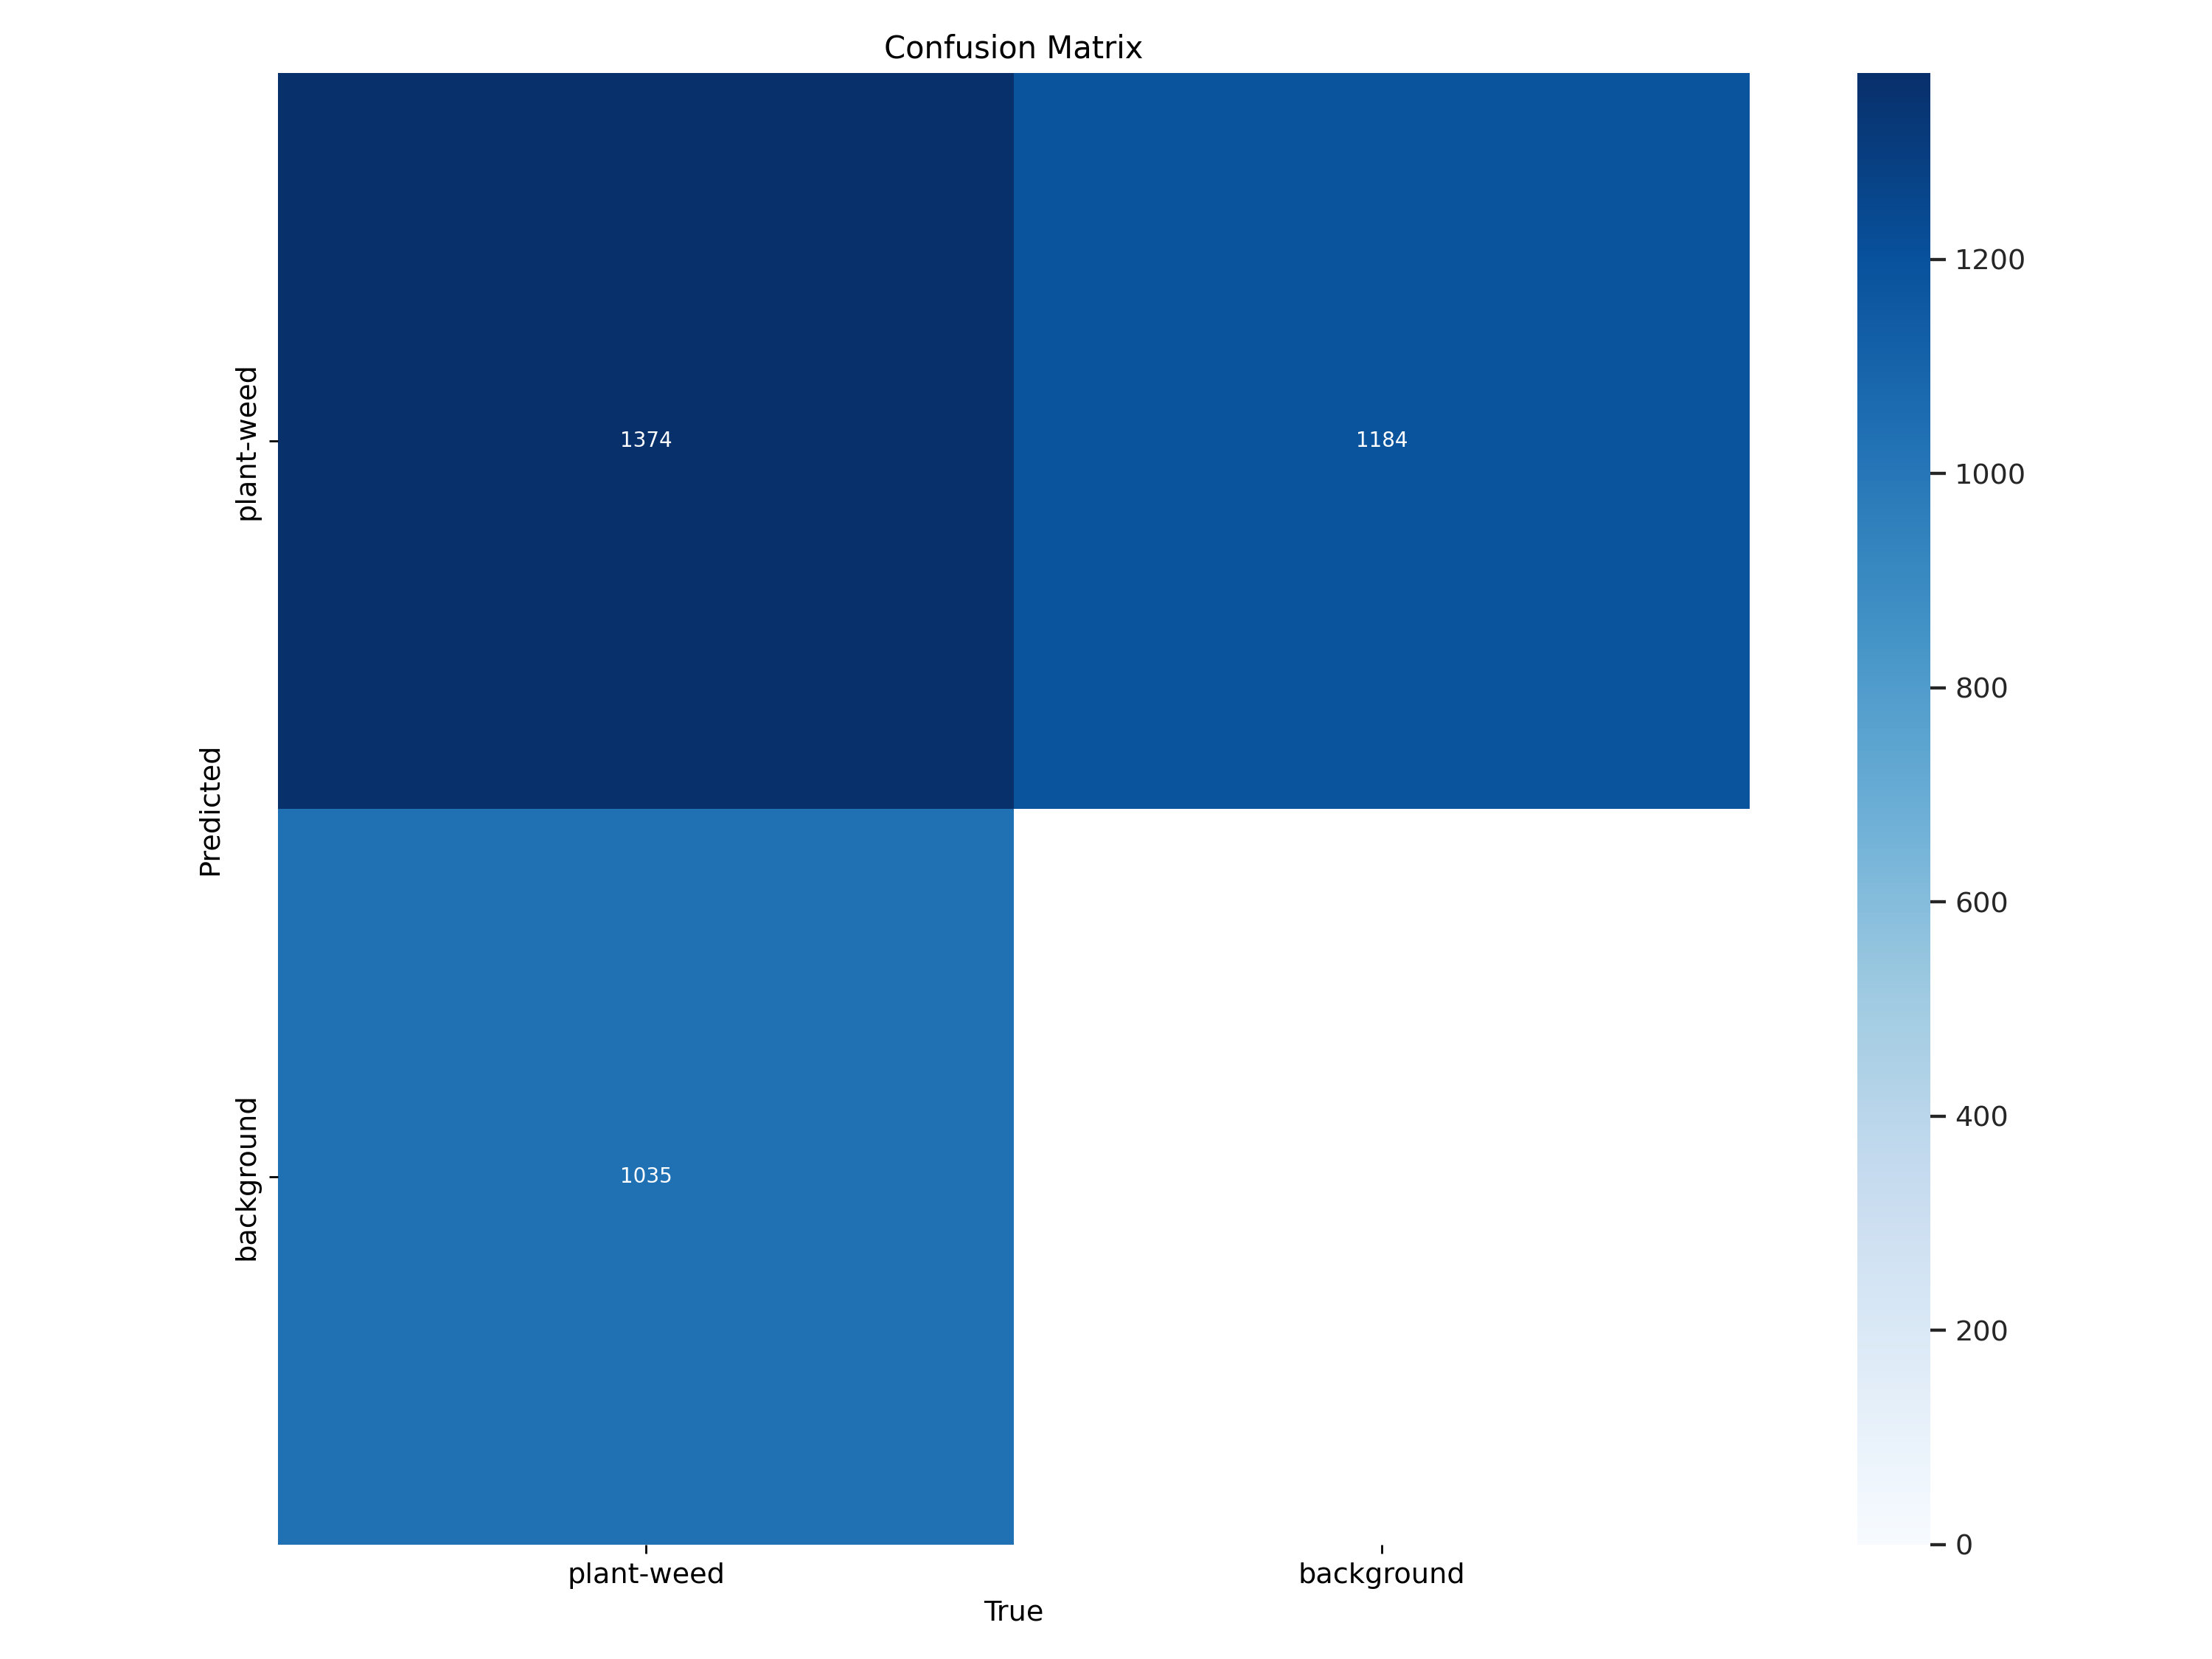

In [66]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

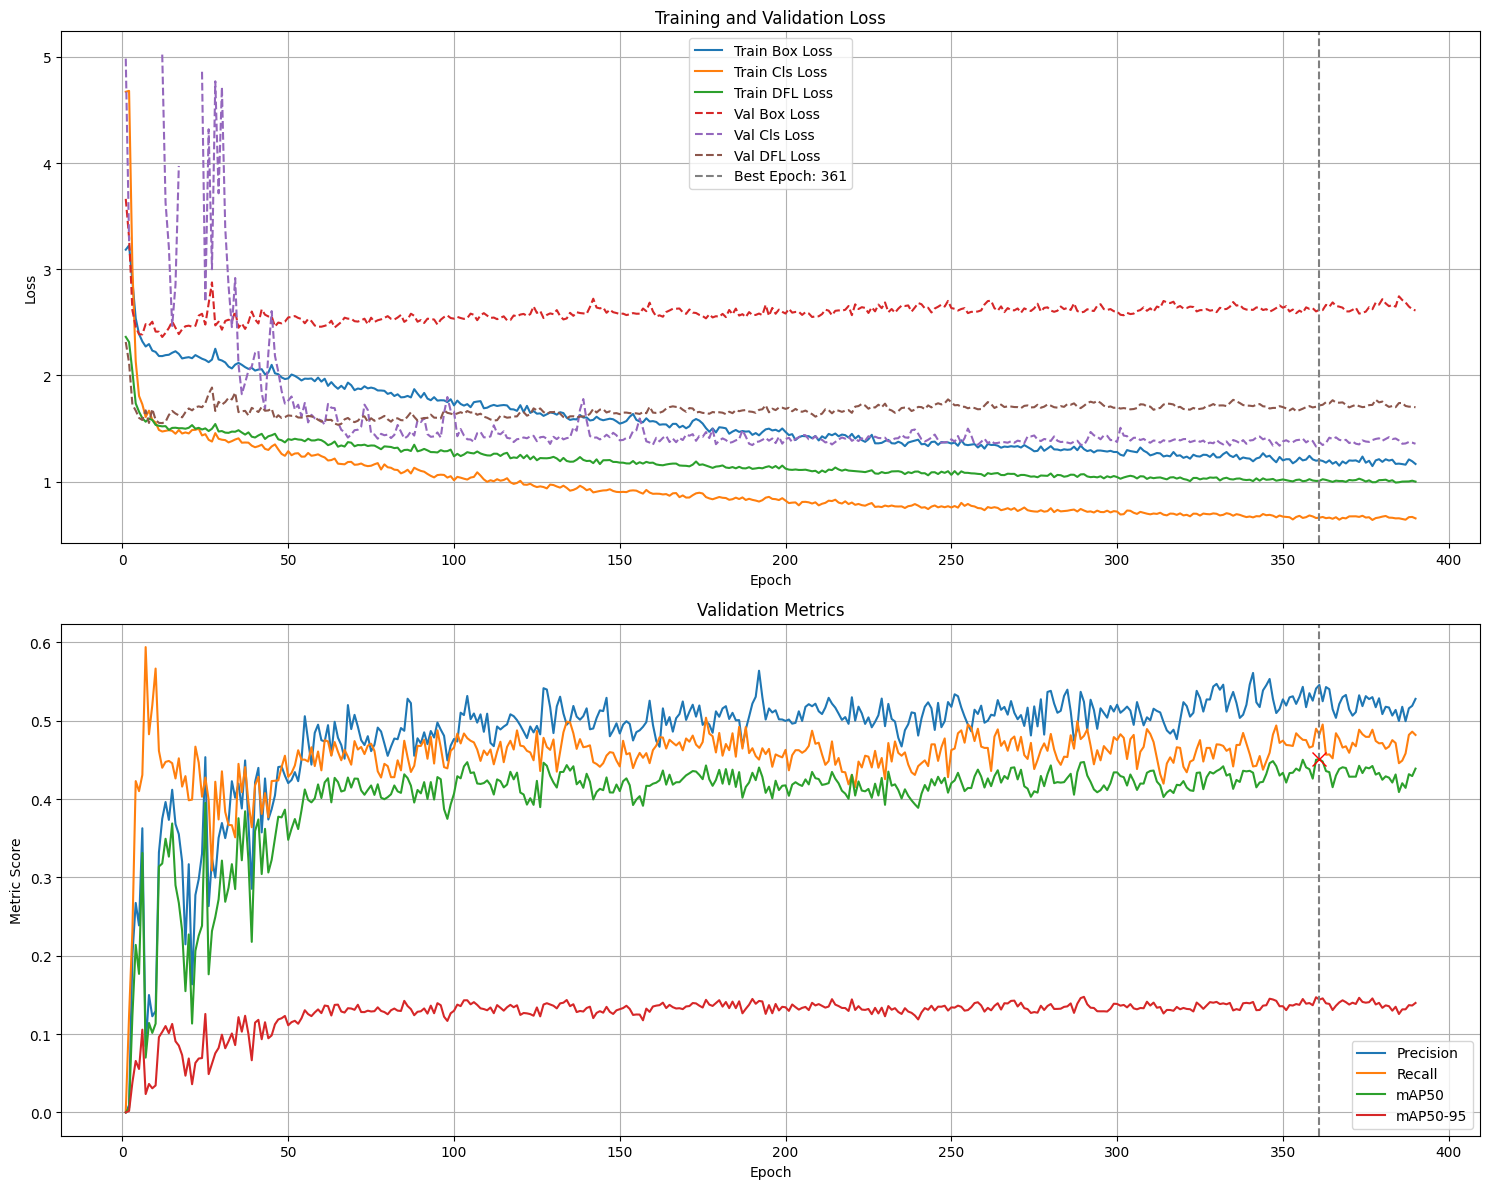

In [67]:
graph_training_metrics(df4, epoch, graph="full")


_**NOTA:** `patience`=100 para EarlyStop_

In [68]:
graph_LrLoss_3D(df4)

Validation set


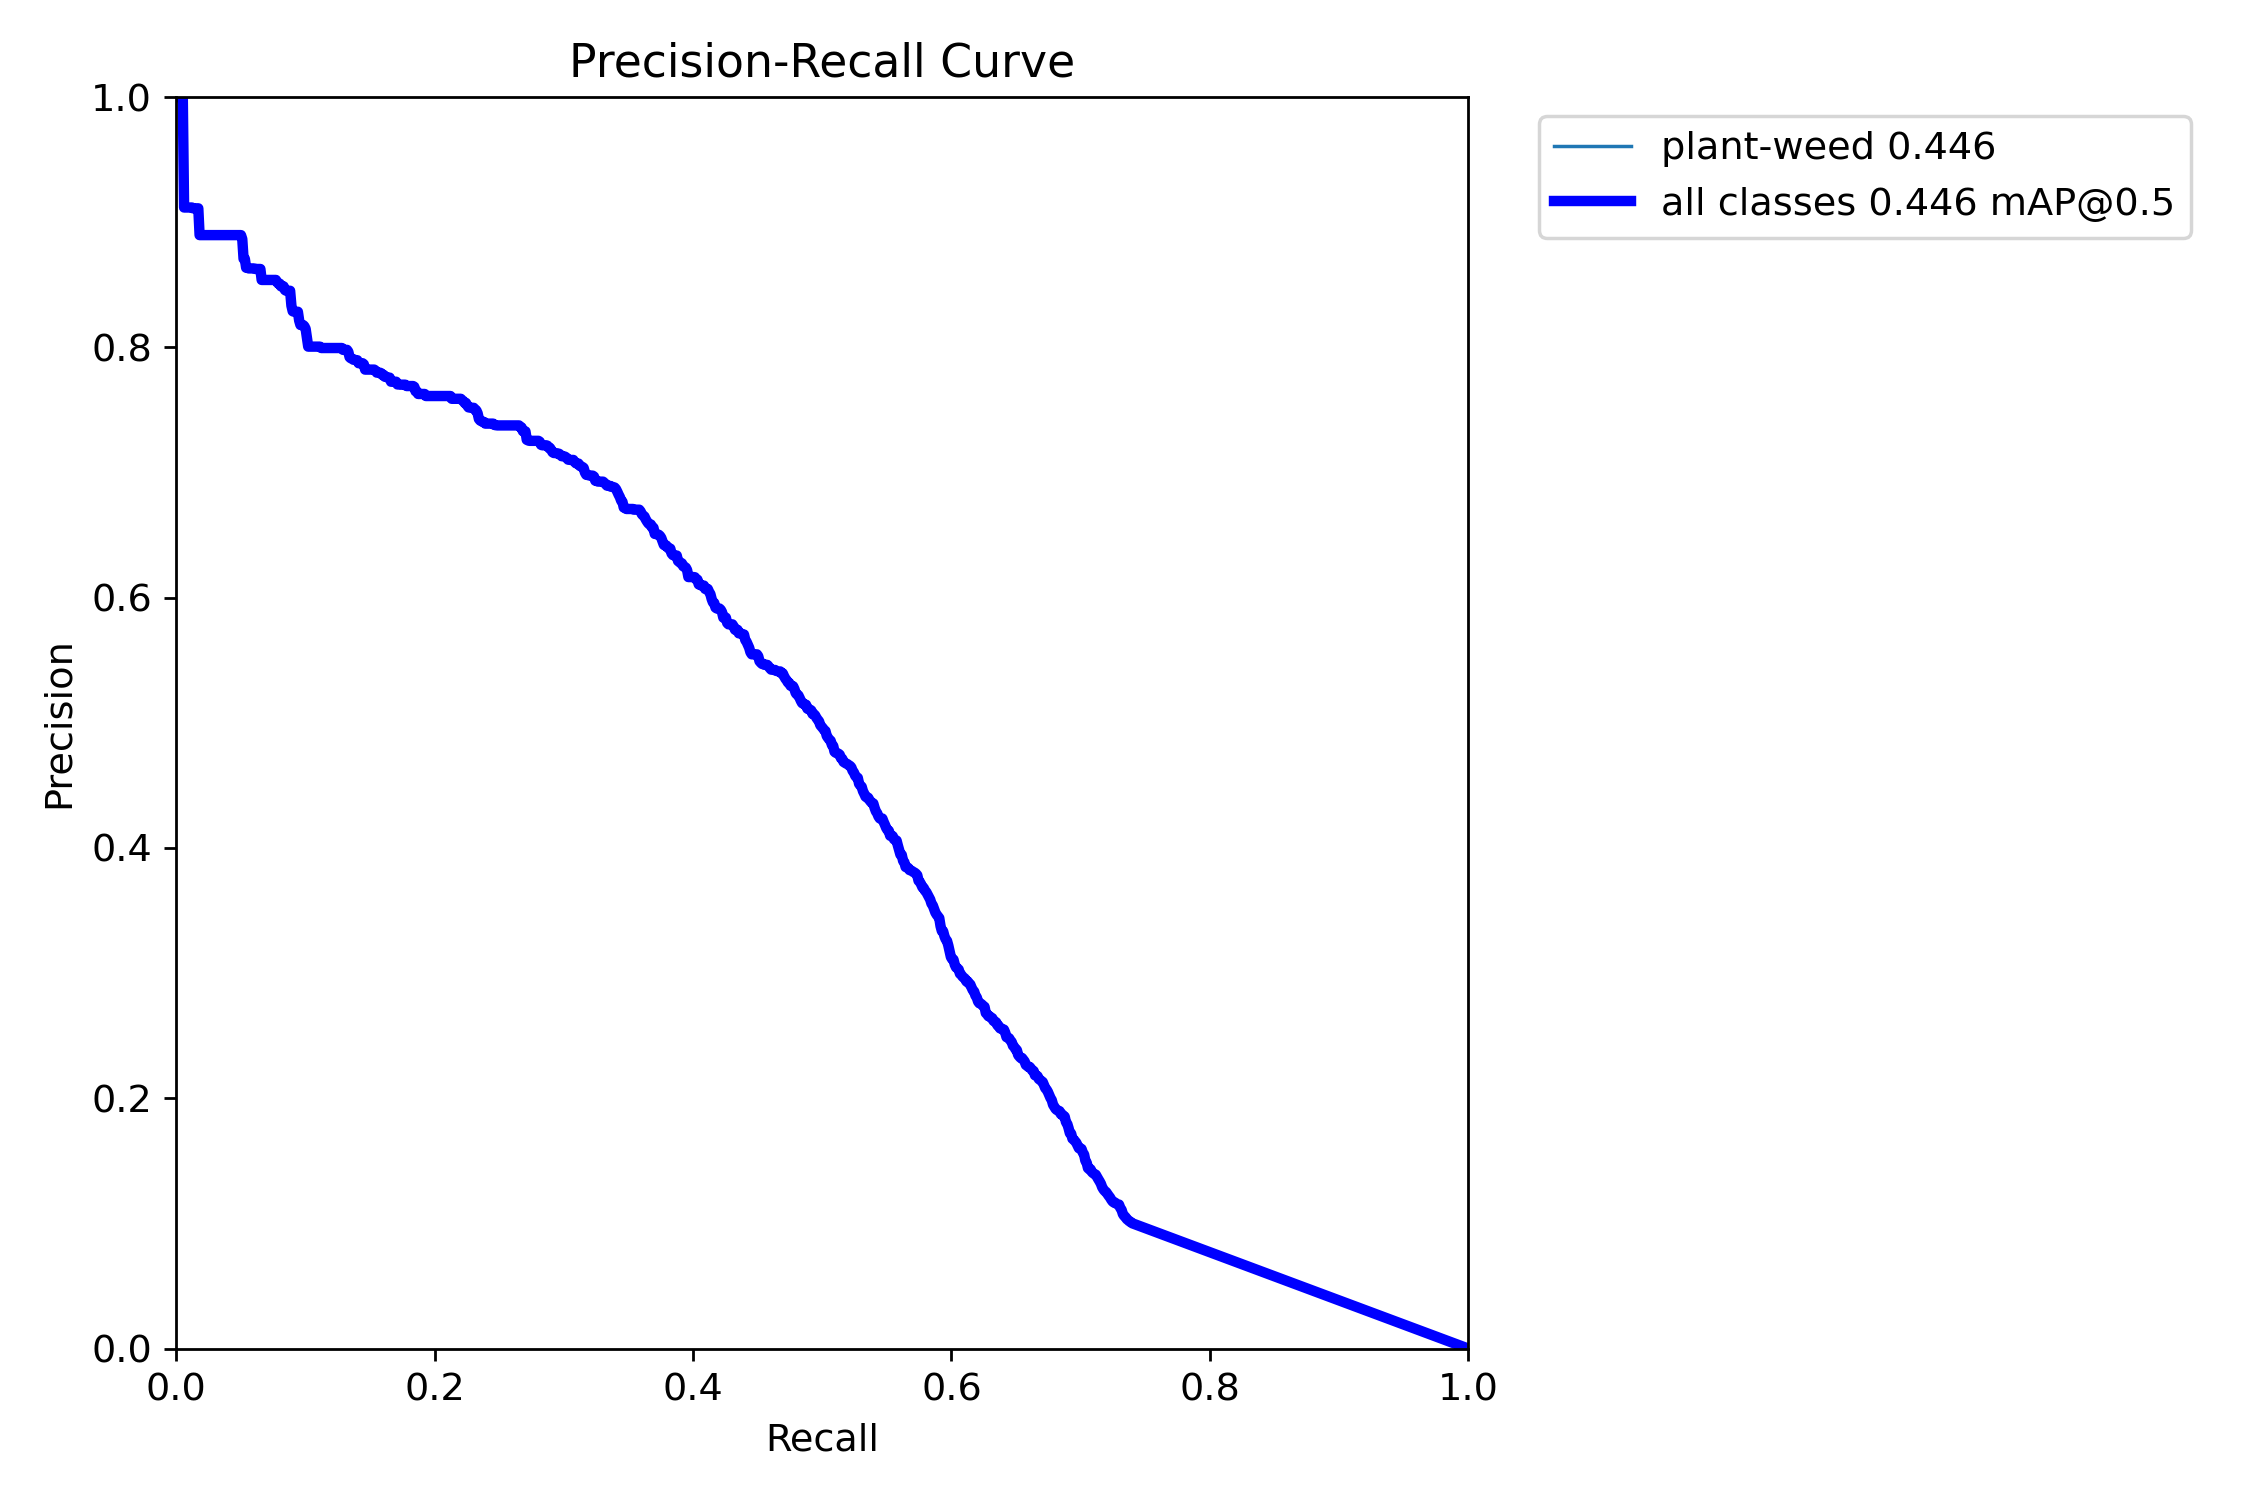

In [69]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

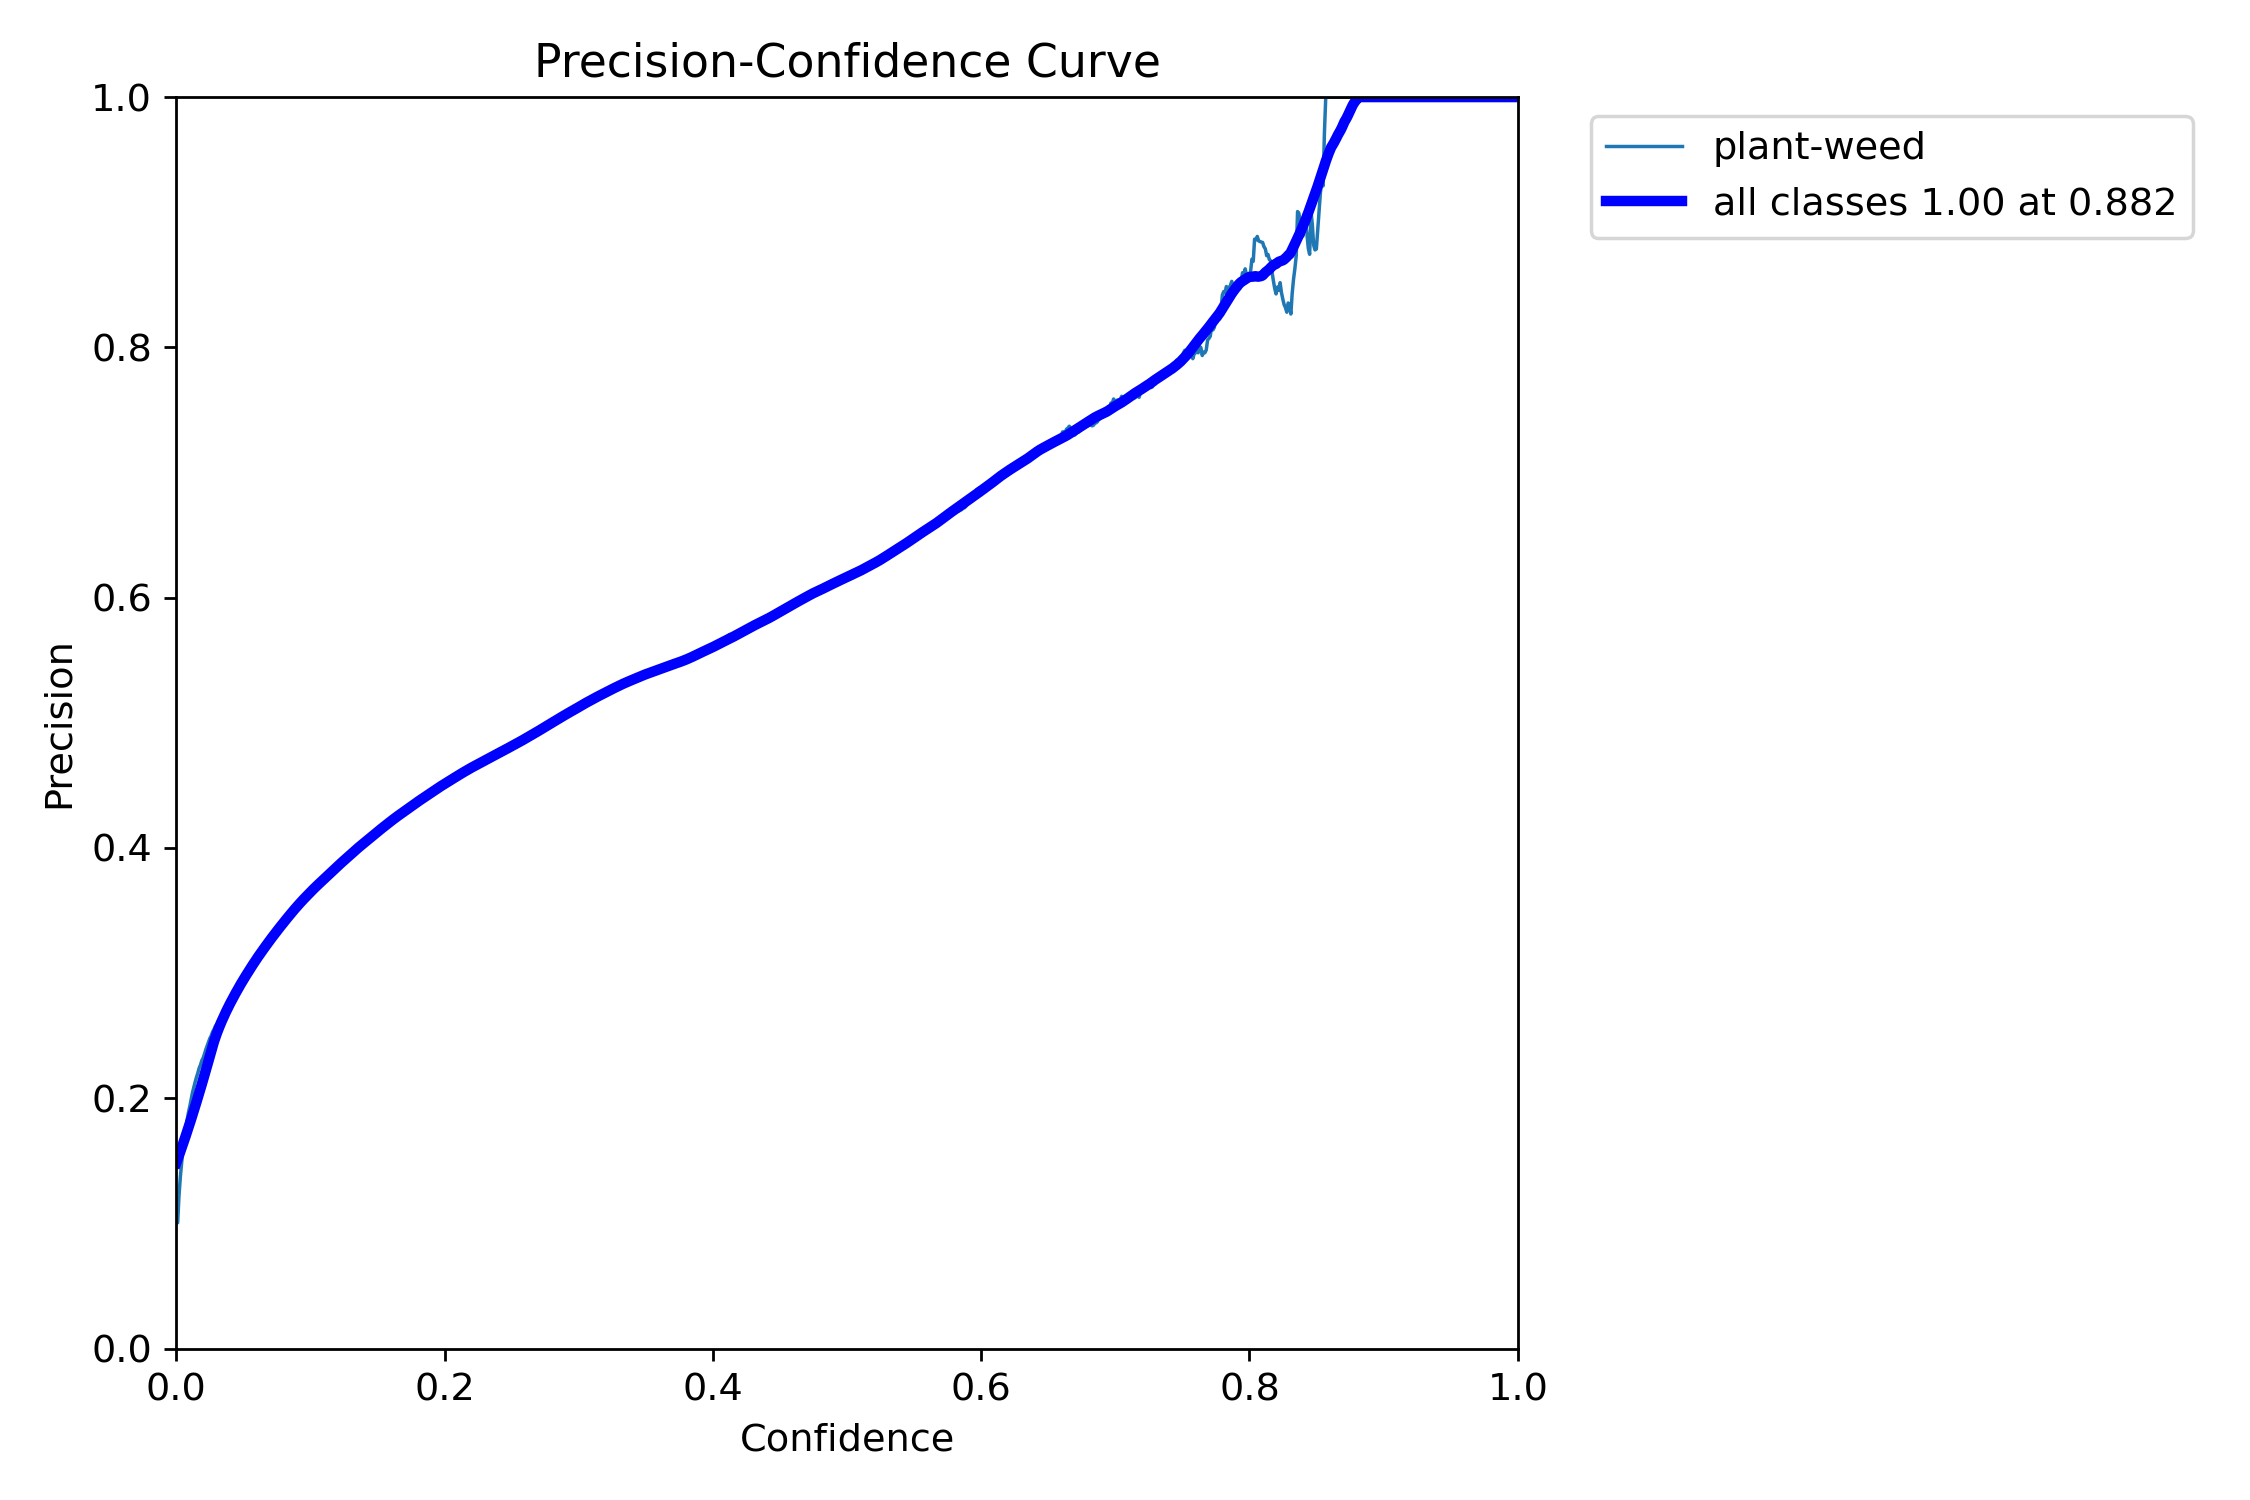

In [70]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

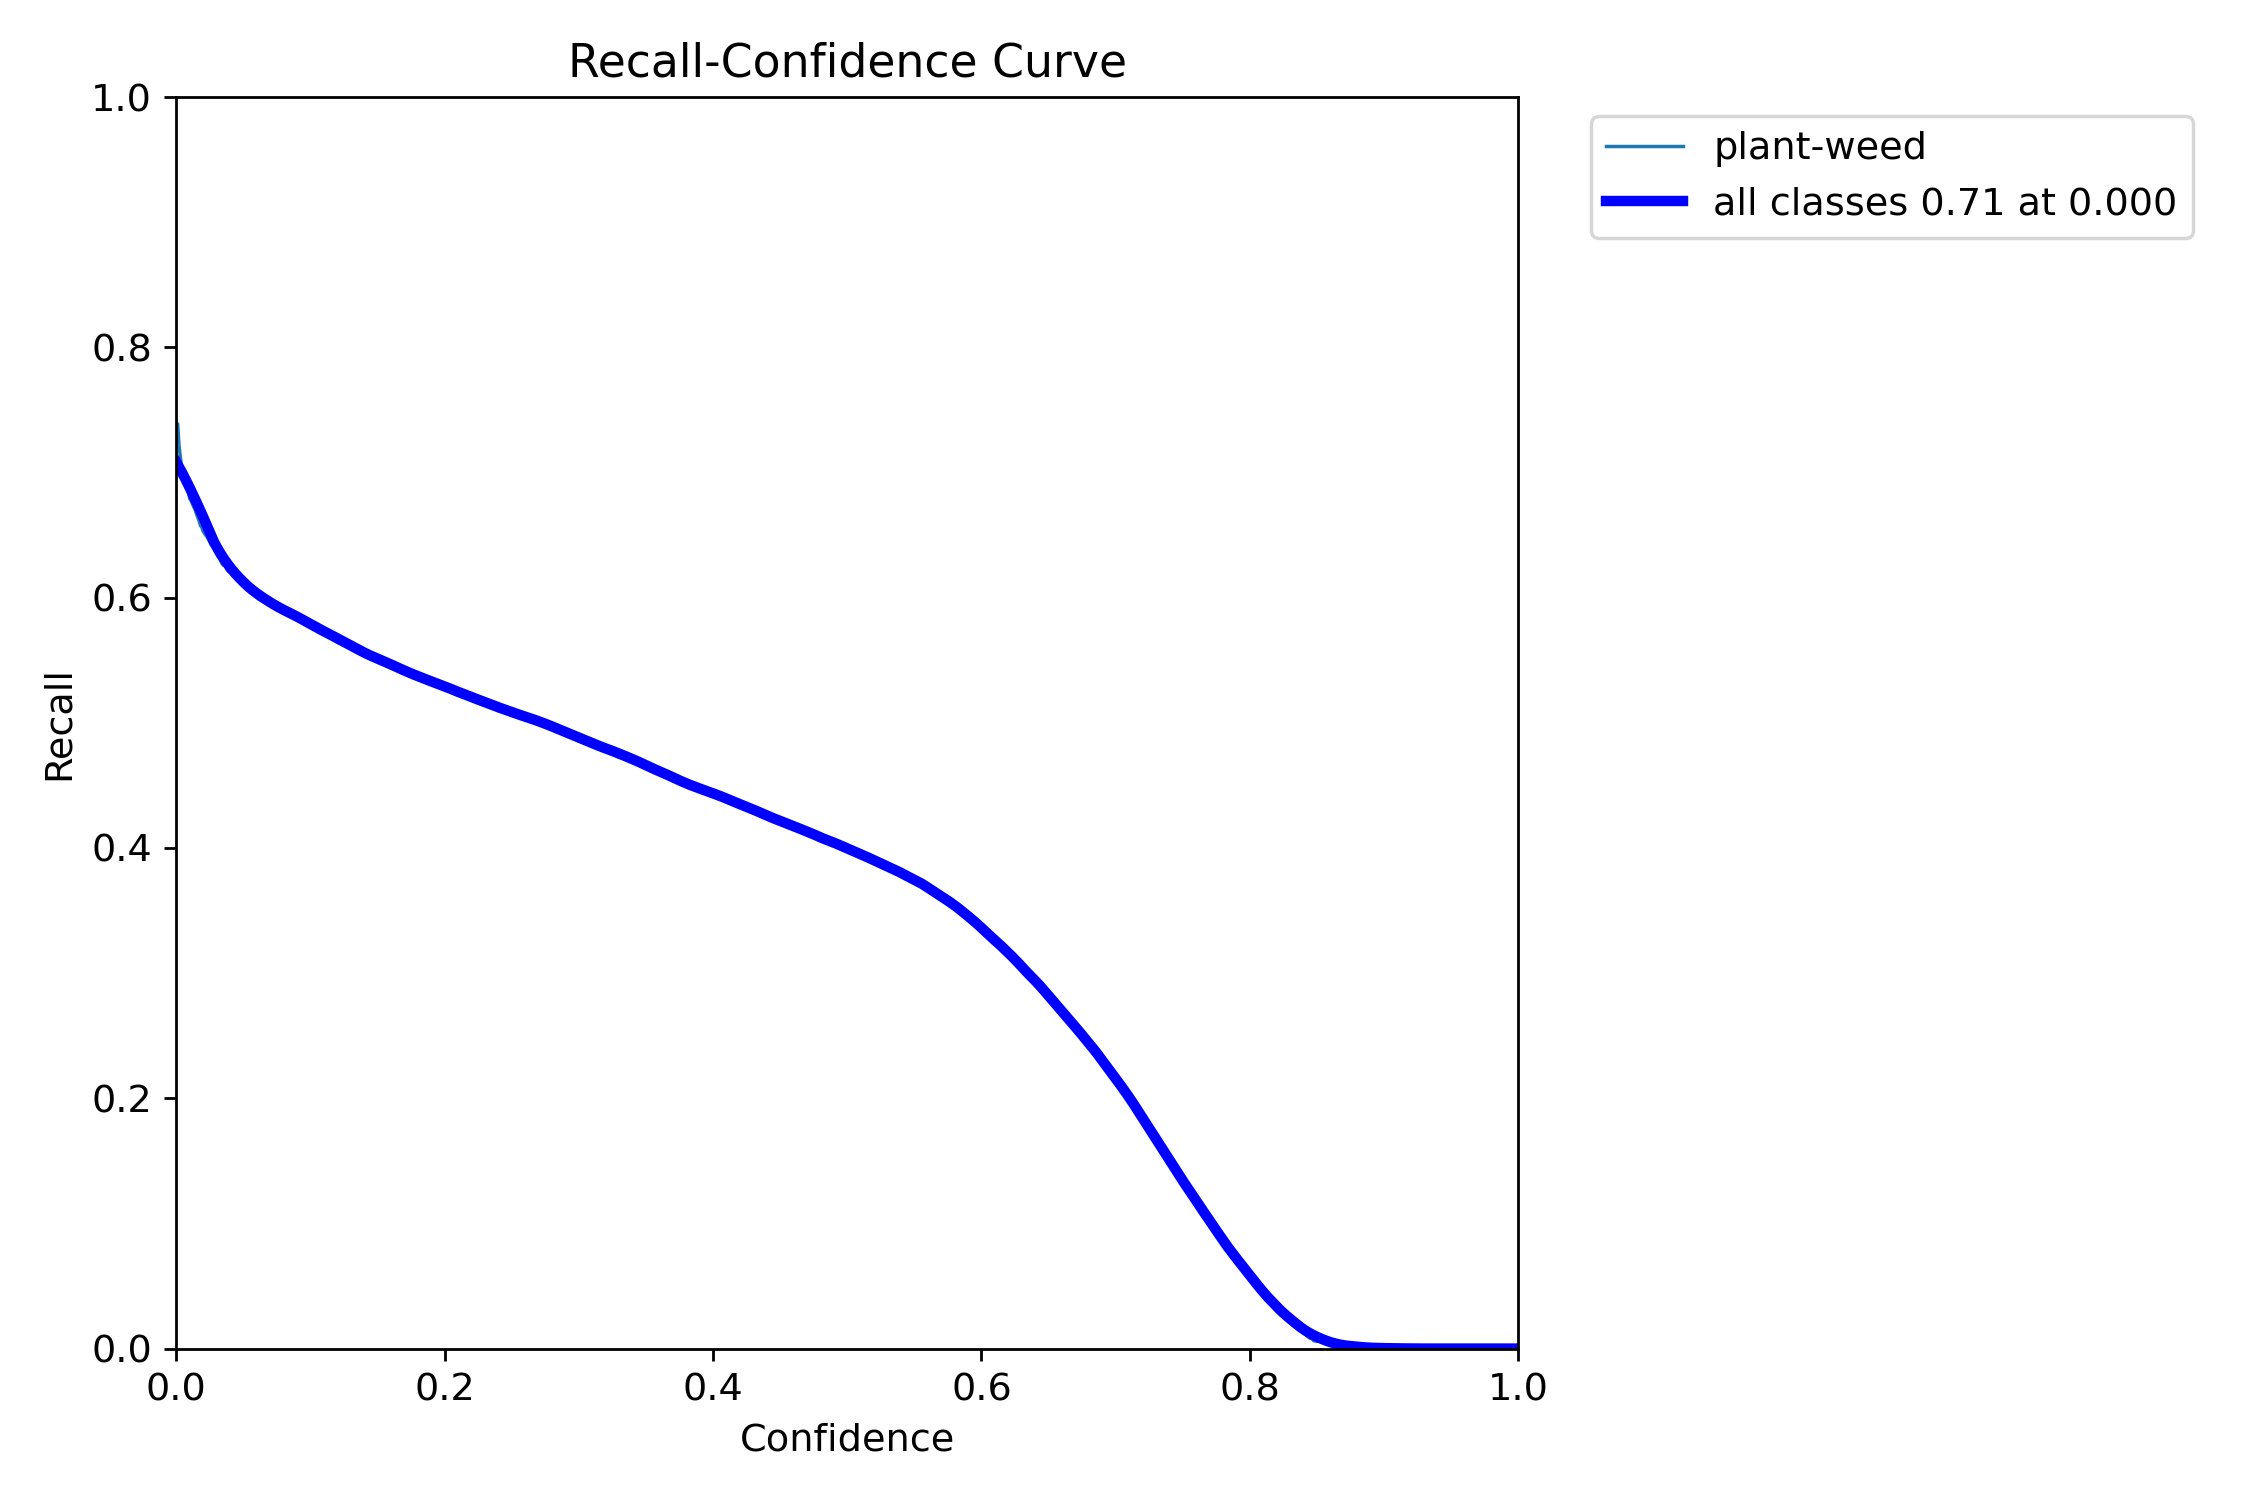

In [71]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

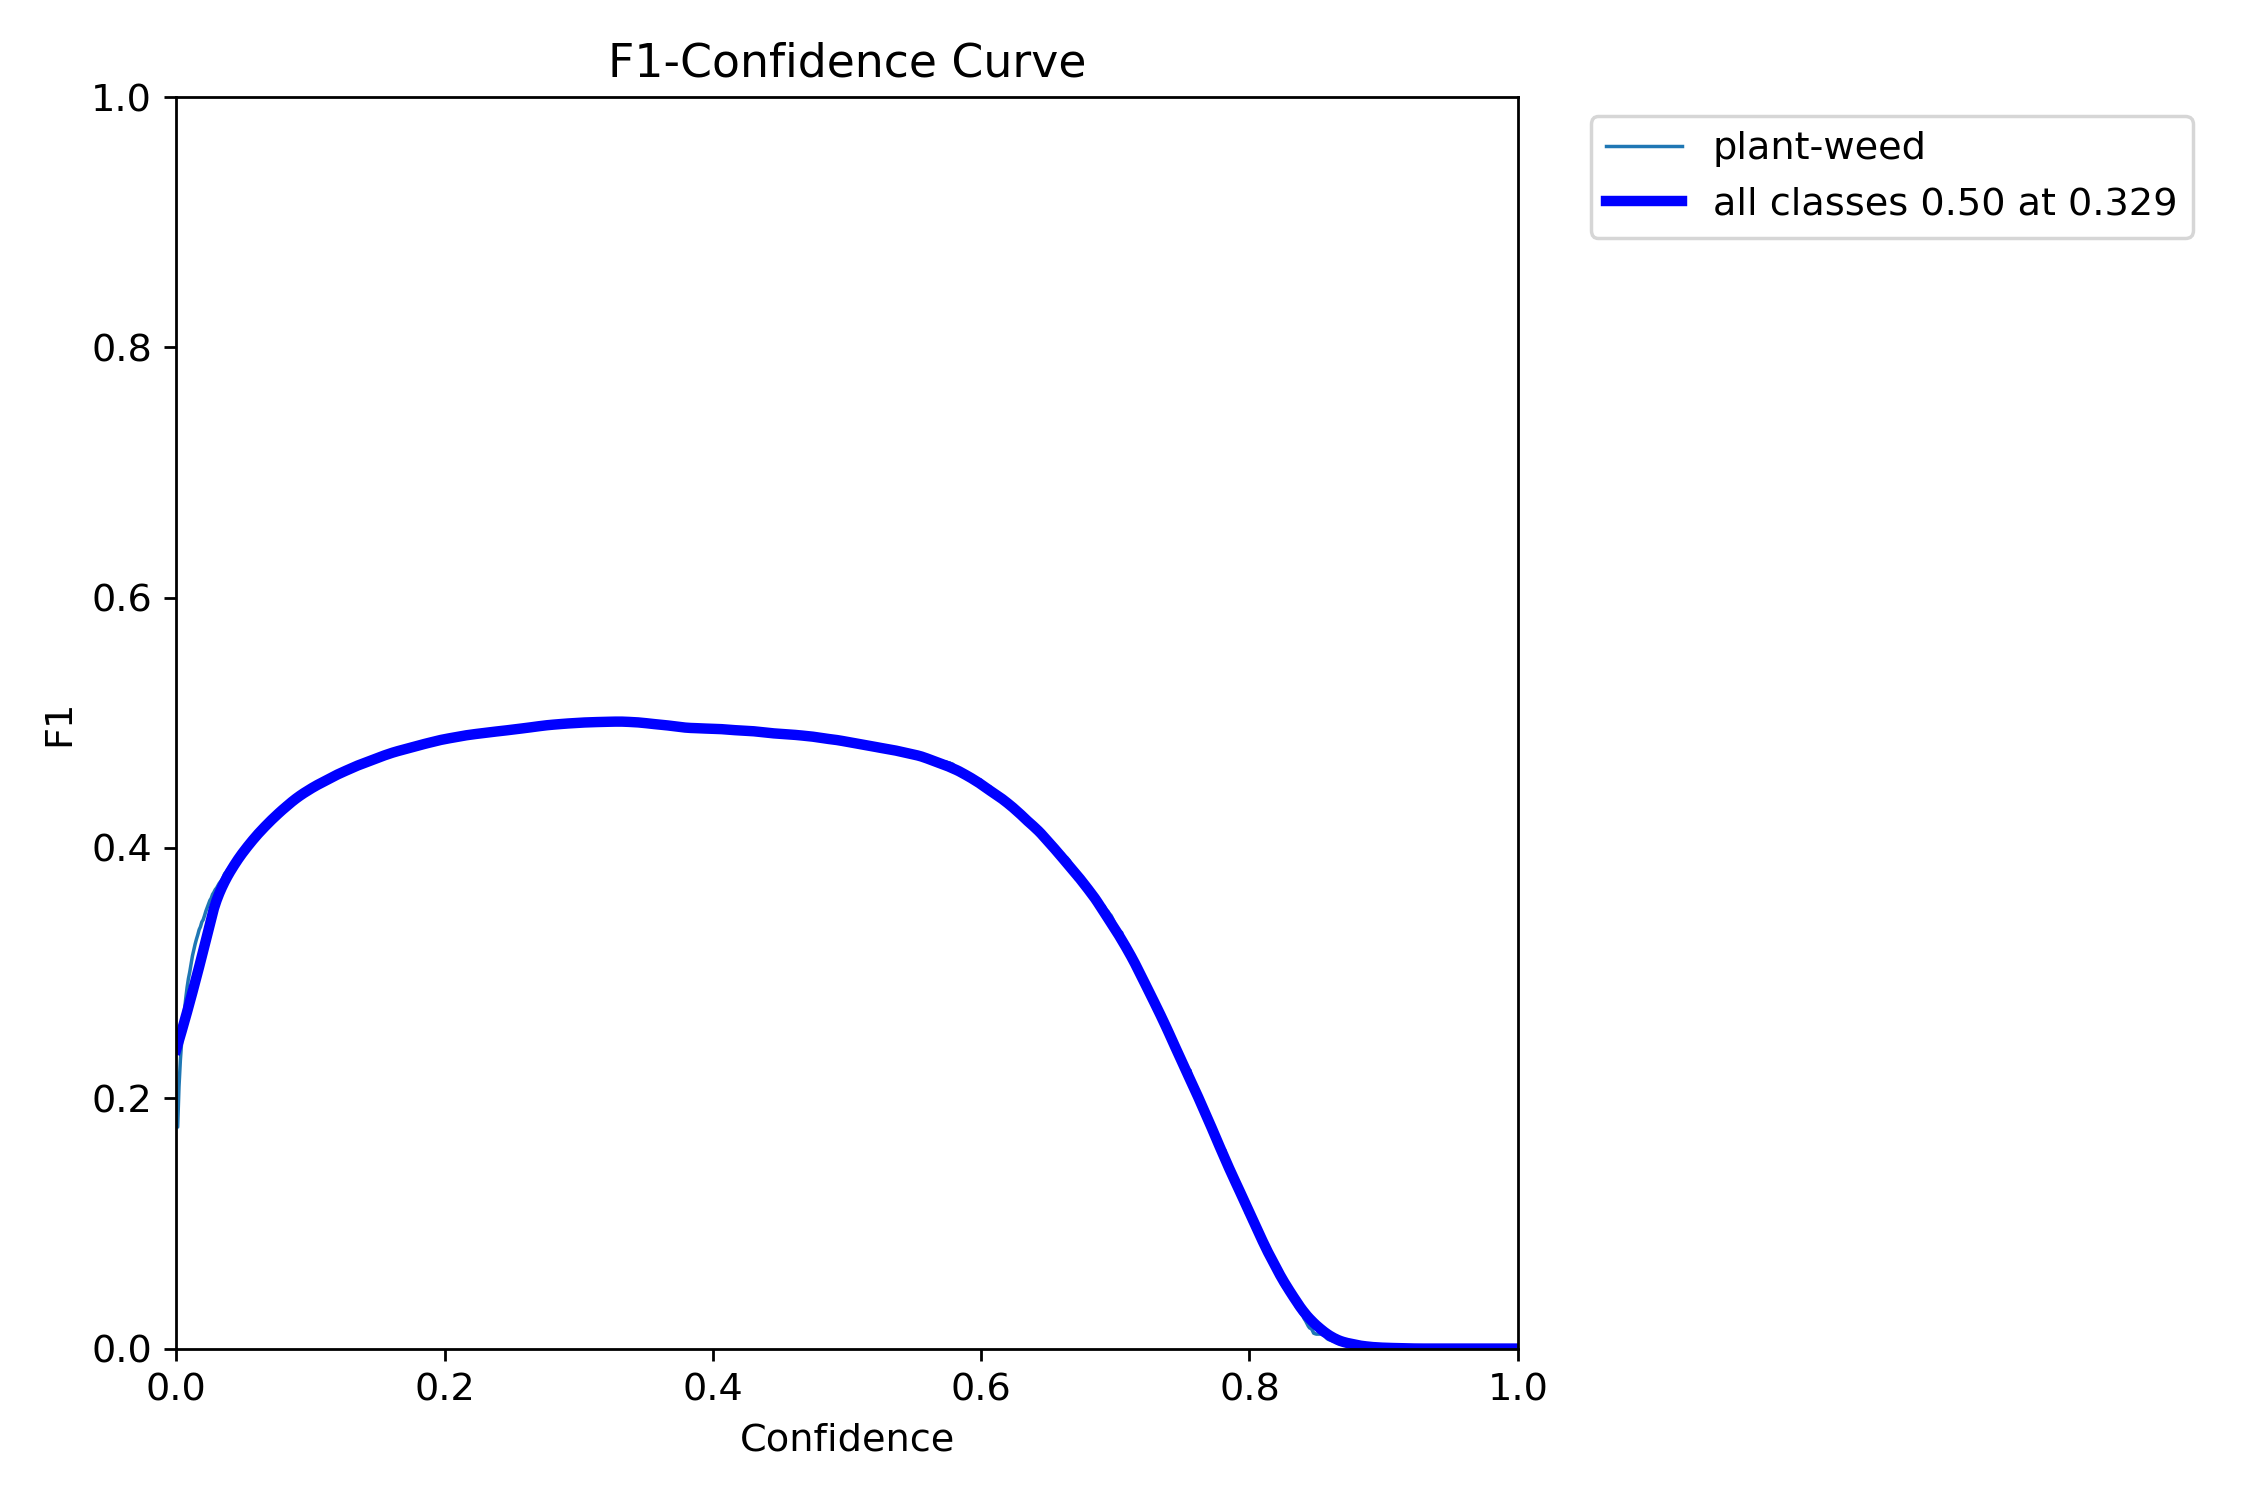

In [72]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

----

# Métricas generales

In [74]:
best_models.index = ['1º TRAIN','2º TRAIN','3º TRAIN','4º TRAIN']

In [75]:
best_models.sort_values(by='metrics/mAP50(B)', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
3º TRAIN,176,899.089,2.23710,1.60874,1.45009,0.46467,0.46866,0.41842,0.14136,2.34734,1.61653,1.40512,0.001654,0.001654,0.001654,19.076167
1º TRAIN,1000,5400.110,0.69050,0.38383,0.90664,0.50082,0.48360,0.44666,0.14497,2.70099,1.43873,2.05573,0.000022,0.000022,0.000022,90.001833
4º TRAIN,361,2792.500,1.20257,0.66073,1.00807,0.54572,0.48236,0.45092,0.14408,2.61832,1.37244,1.71799,0.001287,0.001287,0.001287,50.281833
2º TRAIN,599,13681.600,0.62002,0.35108,0.88294,0.57655,0.45621,0.46619,0.15884,2.65442,1.45569,2.08224,0.000023,0.000023,0.000023,228.026667


## Graphs

In [80]:
def plot_metric(metric, ylabel, title, max_epoch=None):
    """
    Plots a metric from multiple DataFrames with an optional limit on the x-axis.

    Args:
        metric (str): The column name representing the metric to plot.
        ylabel (str): The label for the y-axis.
        title (str): The title of the plot.
        max_epoch (int, optional): The maximum epoch to display on the x-axis. Defaults to None (no limit).
    """
    plt.figure(figsize=(15, 5))
    plt.plot(df1["epoch"], df1[metric], label=best_models.index[0], linestyle="--", marker="o", markersize=4)
    plt.plot(df2["epoch"], df2[metric], label=best_models.index[1], linestyle="--", marker="s", markersize=4)
    plt.plot(df3["epoch"], df3[metric], label=best_models.index[2], linestyle="--", marker="d", markersize=4)
    plt.plot(df4["epoch"], df4[metric], label=best_models.index[3], linestyle="--", marker="*", markersize=4)
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    if max_epoch is not None:
        plt.xlim(0, max_epoch)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training and Validation Losses

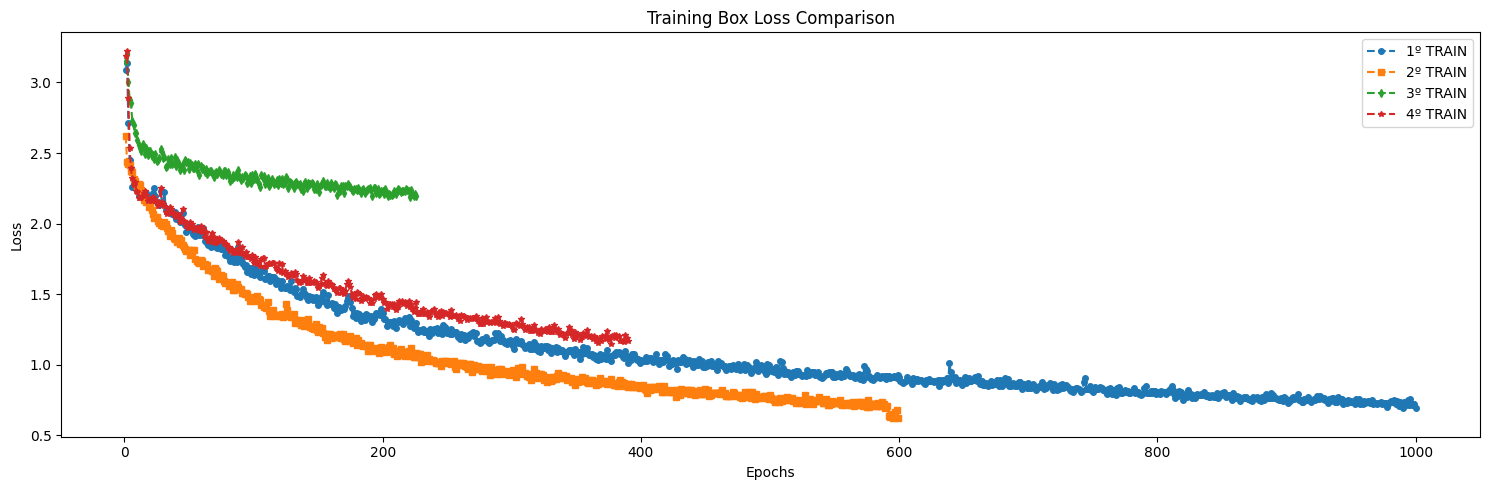

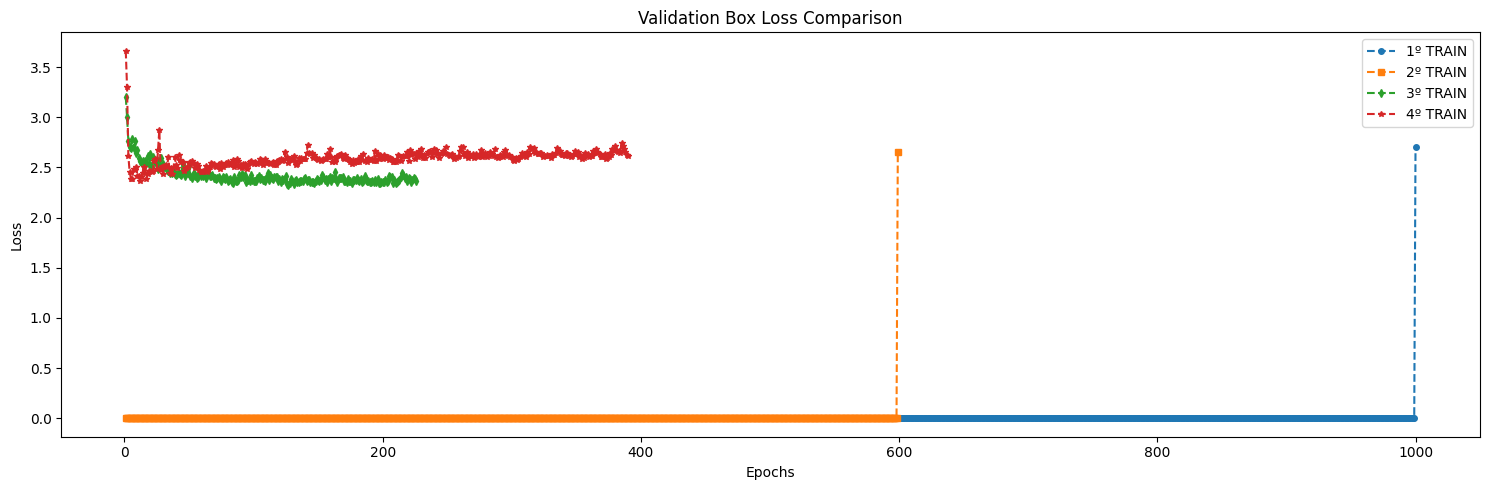

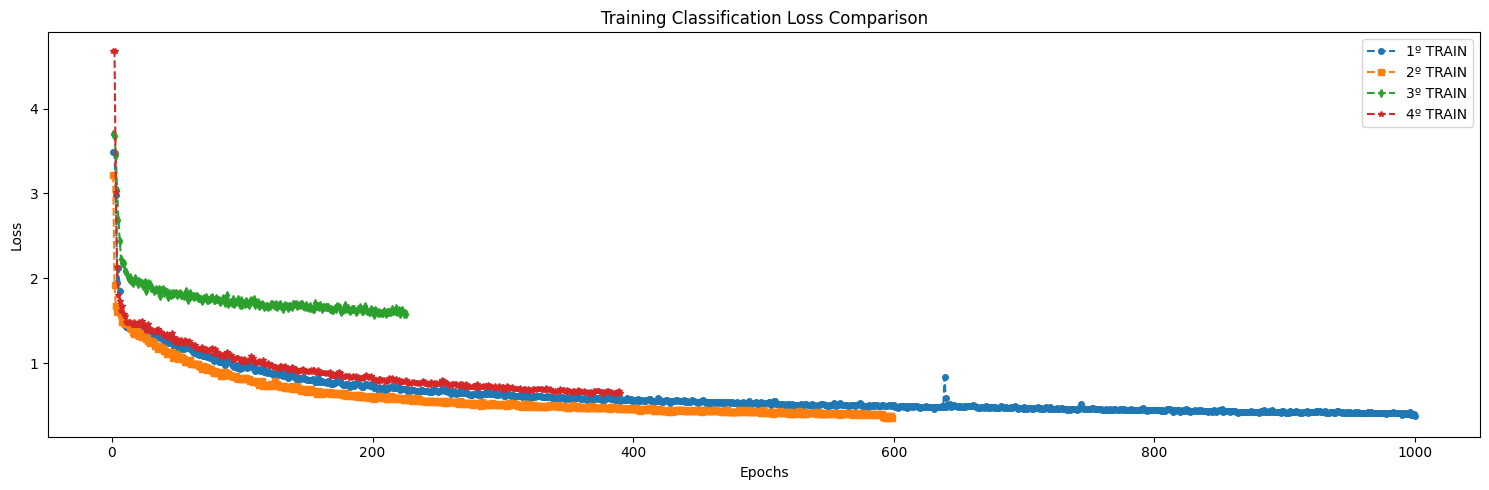

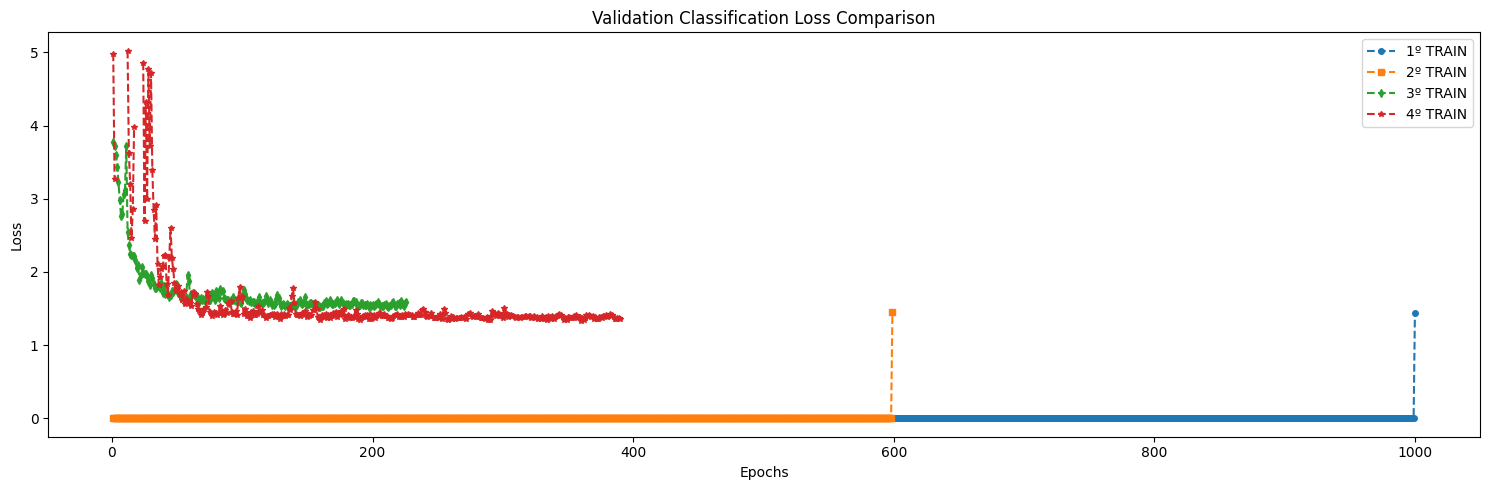

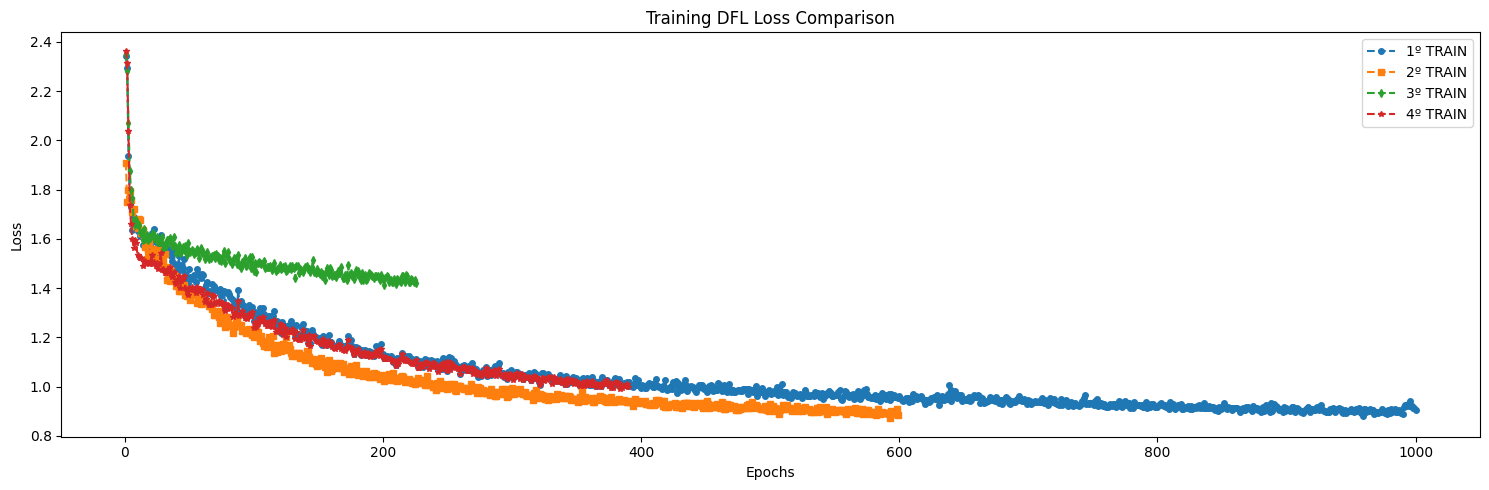

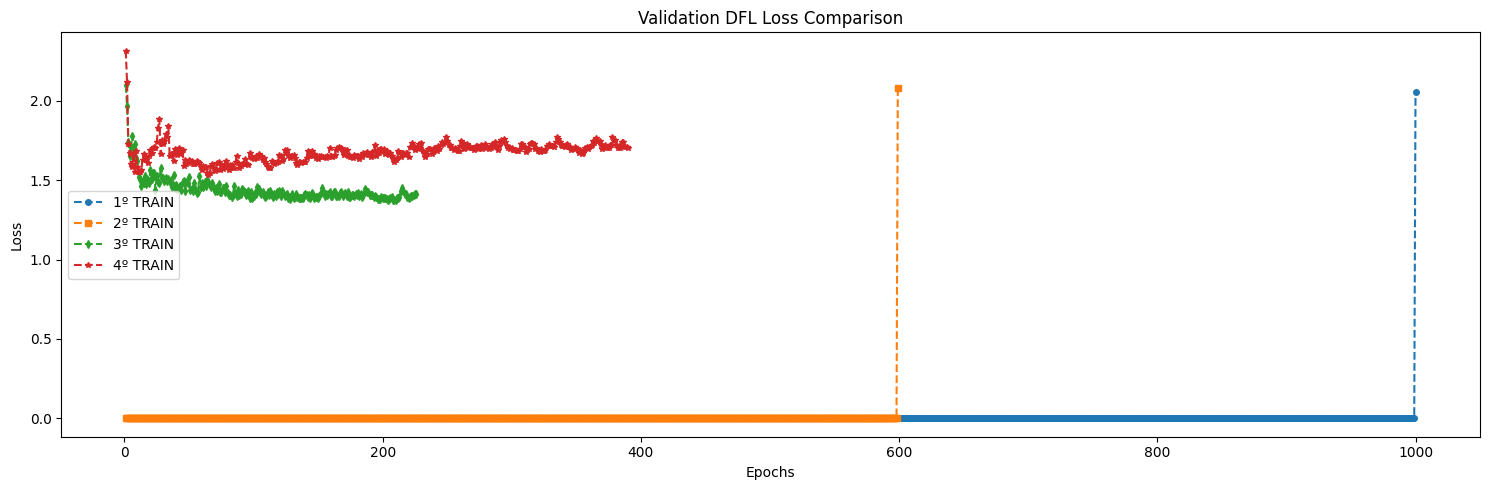

In [81]:
# Plot Training and Validation Losses
plot_metric("train/box_loss", "Loss", "Training Box Loss Comparison")
plot_metric("val/box_loss", "Loss", "Validation Box Loss Comparison")

plot_metric("train/cls_loss", "Loss", "Training Classification Loss Comparison")
plot_metric("val/cls_loss", "Loss", "Validation Classification Loss Comparison")

plot_metric("train/dfl_loss", "Loss", "Training DFL Loss Comparison")
plot_metric("val/dfl_loss", "Loss", "Validation DFL Loss Comparison")

### Performance Metrics

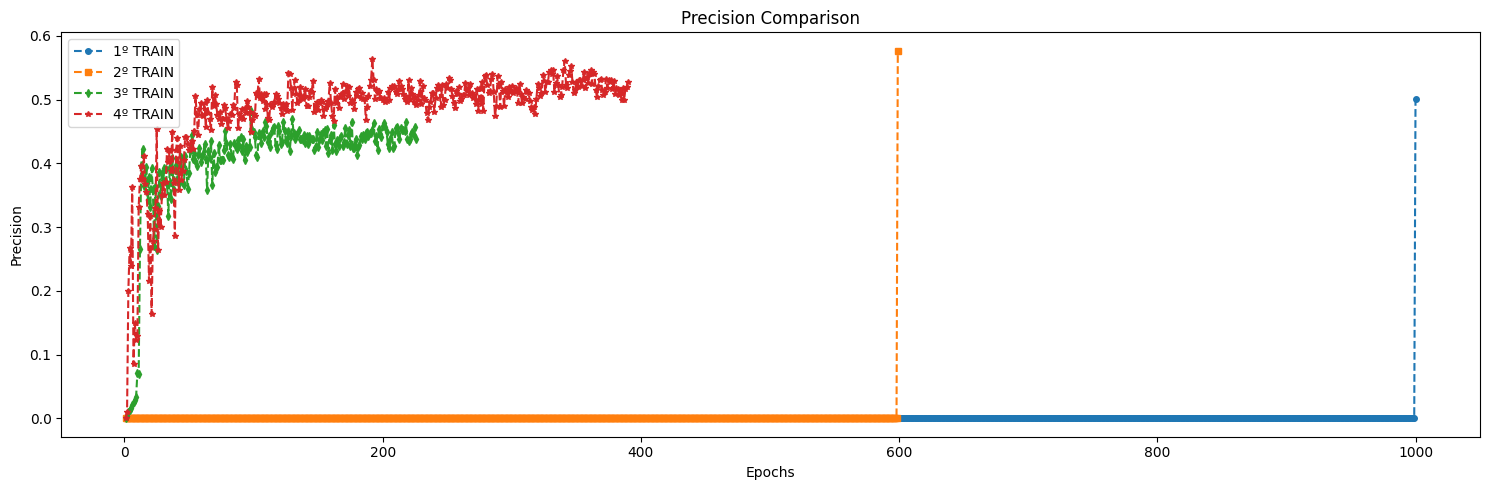

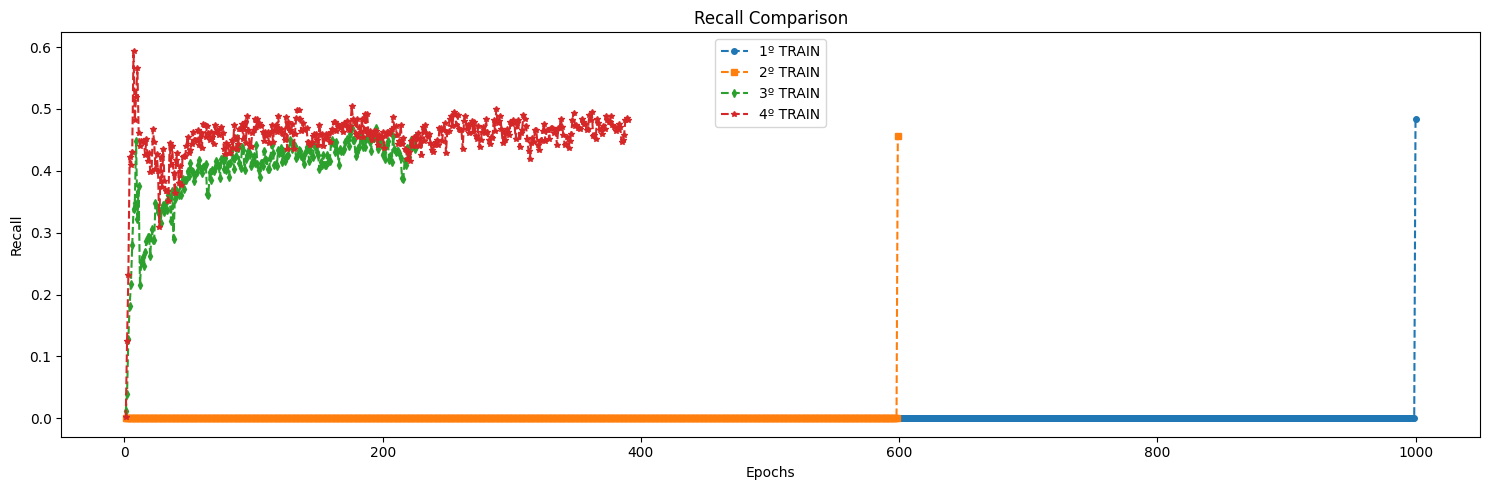

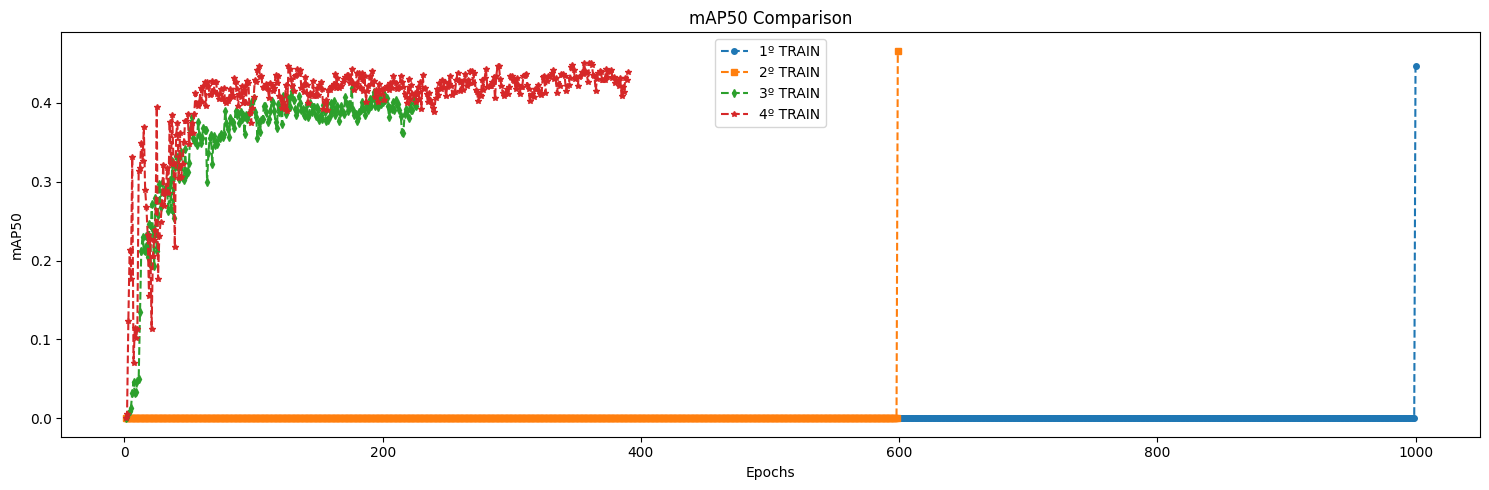

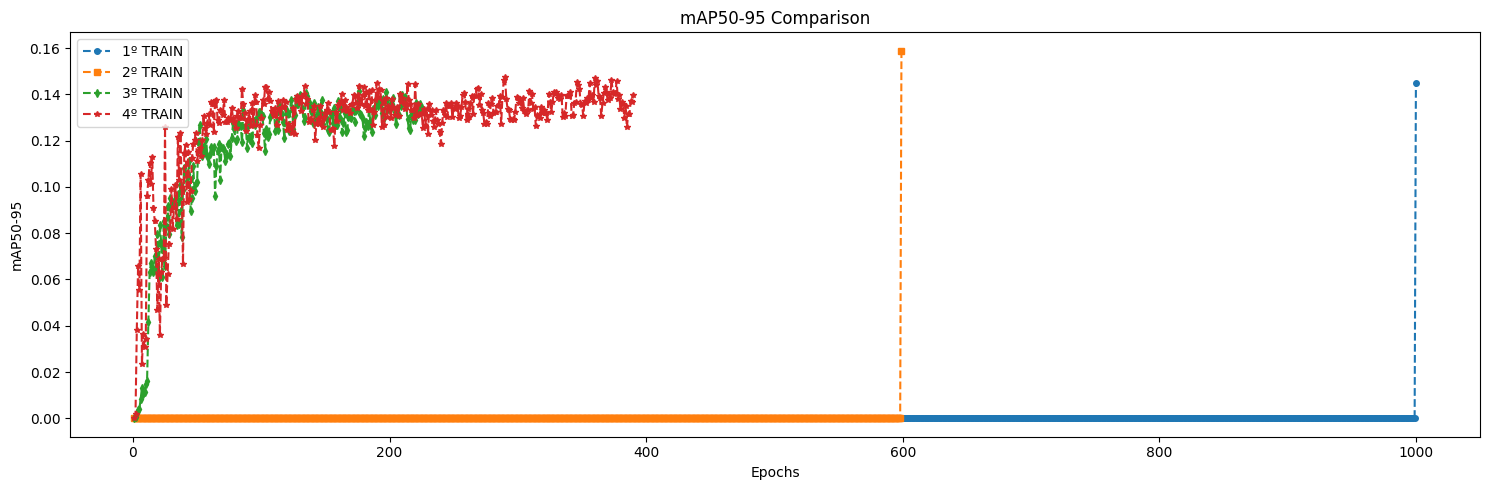

In [94]:
# Plot Performance Metrics
plot_metric("metrics/precision(B)", "Precision", "Precision Comparison")
plot_metric("metrics/recall(B)", "Recall", "Recall Comparison")
plot_metric("metrics/mAP50(B)", "mAP50", "mAP50 Comparison")
plot_metric("metrics/mAP50-95(B)", "mAP50-95", "mAP50-95 Comparison")

### Learning Rate

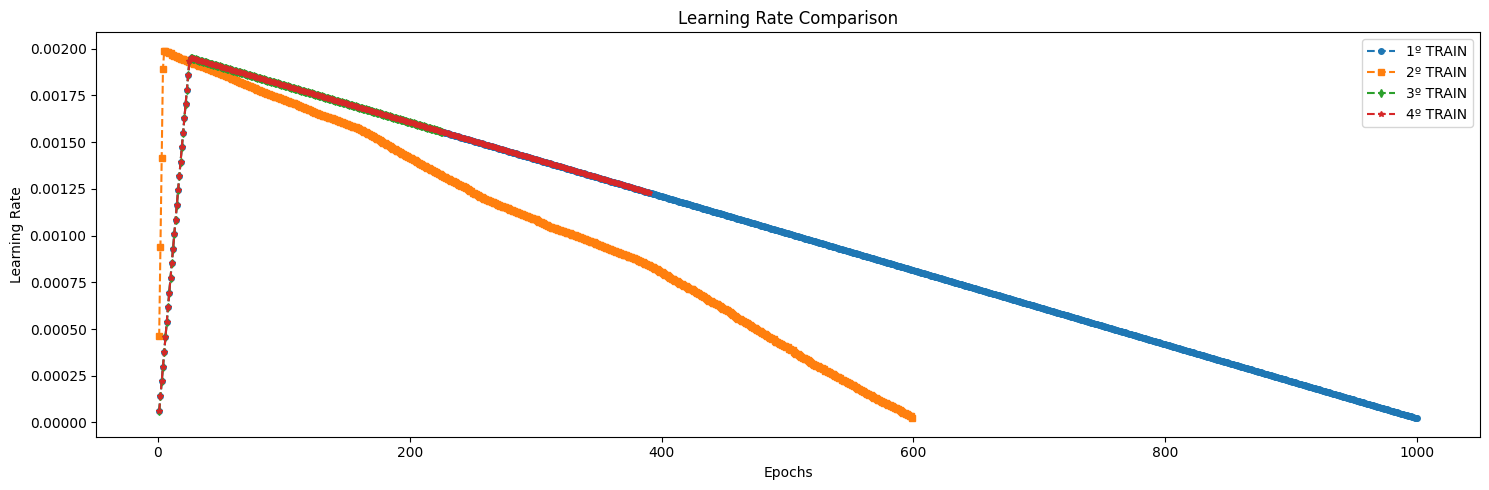

In [83]:
# Plot Learning Rate
plot_metric("lr/pg0", "Learning Rate", "Learning Rate Comparison")

## Resumen de los Experimentos

| **Experiment** | Dataset (Size) | Images | Tiles | Tags | Train/Valid (%) | *Train Time (min)* | Inf Time (ms) | Total detections | True Positives | False Positives | False Negatives | ***mAP@0.5*** |
|------------|------|------|--------------|---------|------|------|----------------|---------------|---------------|---------------|---------------|--------|
| **1º TRAIN** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | *190* | **0** | 3371 | **37,35%** | 28,54% | 34,12% | ***0.447*** |
| **2º TRAIN** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | *228* | **0** | 3188 | **39,84%** | 24,44% | 35,73% | ***0.466*** |
| **3º TRAIN** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | *19* | ***8,12*** | 4334 | 33,36% | **44,42%** | 22,22% | ***0.418*** |
| **4º TRAIN** | Small & Mid | 6 | 324 | 7669 | 67% / 33% | *50* | **25,7** | 3593 | **38,24%** | 32,95% | 28,81% | **0.451** |

1. *Large | 1000 epochs + Early stopping*
2. *Extra Large | 1000 epochs + Early stopping*
3. *Nano | 1000 epochs + Early stopping*
4. *Medium | 1000 epochs + Early stopping*

## Comparación de los Entrenamientos

### Análisis del Dataset
- **Cantidad de imágenes y etiquetas**:  
  -  

- **Distribución de Train/Valid**:  
  -  

- **Tamaño de imágenes (small vs mid)**:  
  -  

### Análisis de los Hiperparámetros
- **Modelo (yolov8n)**: Se mantuvo constante en todos los entrenamientos, lo que permite una comparación justa.  
- **Epochs (100)**: En los tres experimentos, el modelo parece alcanzar su rendimiento máximo antes de completar todas las épocas, lo que podría indicar que no se necesita entrenar tantas iteraciones.  
- **Batch Size (64)**: Se mantiene igual en todos los experimentos.  
- **Freeze (10)**: Congelar los primeros 10 capas del modelo en los tres entrenamientos podría estar limitando la capacidad de ajuste en las primeras etapas.  

### Análisis de Resultados
#### Métricas Generales
- **Precisión (Precision) y Recall**:  
  -  

- **mAP50**:  
  - 
  
- **Confusión entre clases (False Positives y False Negatives)**:  
  - 
  
### Conclusiones Generales
1. 

# Conclusión Final


## Estrategias para Próximos Entrenamientos
1. **Dataset**
- 

2. **Hiperparámetros**
-  

3. **Optimización del Modelo**
- 

4. **Evaluación y Métricas**
-  